<!--<badge>--><a href="https://colab.research.google.com/github/JoeChen322/Fintech/blob/main/BC3/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->

# Portfolio Replica Strategy

Seven-Part deliverable:

- `main.ipynb` — all analysis, plots, and end-to-end runs across Parts I–VII.
- `harness.py` — rolling-backtest engine, transaction-cost models, risk metrics, audit helpers, shared metric-row and percentage-formatting helpers.
- `predict_then_optimize.py` — convex predict-then-optimize layer (Ledoit-Wolf covariance + CVXPY).
- `kalman.py` — linear Kalman filter, pykalman EM noise tuning, hmmlearn regime classifier (HMM frozen on warm-up window).
- `dl_pipeline.py` — neural-network weight generator (MLP).
- `portfolio_constraints.py` — rebalancing cadence and gross-exposure / VaR projection layer used by Part III.

**Reading guide.**

- **Part I — Setup, Data Loading & EDA.** Build the clean `(X, y)` weekly panel; surface data-quality and feature-relevance diagnostics.
- **Part II — Backtest Methodology.** Define the rolling harness, transaction-cost / VaR / GE / IR / TE conventions, and the assumption register.
- **Part III — Ridge Control + Rebalancing & Constraints Sweep.** Canonical Ridge baseline; then sweep cadence x leverage scenarios under the constraint layer.
- **Part IV — Linear Benchmark Family (Predict-then-Optimize).** OLS / Ridge / Lasso / ElasticNet / Huber leaderboard via the convex layer.
- **Part V — Kalman Filter / State-Space.** Static sigma_w grid, EM tuning, and regime-switching with the HMM frozen on the warm-up window.
- **Part VI — Deep Learning Weight Generator.** MLP weight generator.
- **Part VII — Final Consolidated Comparison & Findings.** Master table, spotlight plot, acceptance checklist.
**Data flow.**

```
prices -> (X, y) panel -> harness.run_rolling_backtest + evaluate_weights
      -> {Ridge baseline, Linear PO, Kalman, NN}
      -> results/*.pkl -> consolidated comparison
```

# Part I — Setup, Data Loading & EDA


In [41]:
import hashlib
import json
import pickle
import sys
import time
import warnings
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Any, Callable, Dict, Iterable, List, Literal, Optional, Protocol, Tuple, Union

# Scientific stack
import numpy as np
import pandas as pd
from numpy.linalg import LinAlgError
from scipy.stats import norm

from sklearn.linear_model import ElasticNet, HuberRegressor, Lasso, LinearRegression, Ridge
from sklearn.preprocessing import MinMaxScaler

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import torch
import torch.nn as nn

# Project modules
from harness import *
from predict_then_optimize import (
    POConfig,
    alpha_from_linear_fit,
    shrunk_covariance,
    solve_po,
    top_k_active,
    run_predict_then_optimize_backtest,
)
from dl_pipeline import (
    FeatureConfig,
    build_features,
    WeightMLP,
    make_supervised_windows,
    te_mse_loss,
    turnover_penalty,
    annualized_te_from_weights,
    project_var_cap,
    TrainConfig,
    train_weight_mlp,
    compute_metrics,
    run_nn_rolling_backtest,
)
from kalman import (
    KalmanConfig,
    kalman_run_full,
    run_kalman_replica,
    fit_em_noise,
    fit_hmm_regime,
    kf_metrics_row,
)

from portfolio_constraints import (
    apply_gross_exposure_cap,
    apply_var_cap,
    build_scenario_grid,
    calculate_historical_var,
    calculate_var_gaussian,
    compute_metrics as compute_pc_metrics,
    compute_turnover,
    evaluate_crisis_window,
    fit_elastic_net,
    run_backtest as run_pc_backtest,
    run_scenario_search,
    select_best_scenarios,
    test_normality,
)

%config InlineBackend.figure_format = 'retina'


## Setup

This section defines the reusable evaluation harness used by the rest of the notebook. It is organised in small, labelled blocks so errors are easier to locate and the workflow is easier to audit.

The setup contains:
1. imports, constants and configuration;
2. data loading, cleaning and EDA helper functions;
3. transaction-cost, risk and metric utilities;
4. the rolling backtest and external-weight evaluation functions;
5. reporting, validation, sensitivity-check and export helpers;
6. notebook runtime settings such as plot style and output folder.

### Imports

All imports — standard library, scientific stack, and project modules (`harness`, `predict_then_optimize`, `kalman`) — are consolidated in the top code cell.


In [42]:
BASE = Path.cwd().resolve()
np.random.seed(42)

plt.rcParams.update({
    "figure.figsize": (12, 4.5),
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "legend.frameon": False,
})

OUT = BASE / "results"
OUT.mkdir(exist_ok=True)

PROJECT_STRESS_WINDOWS = {
    "Post-GFC recovery": ("2009-10-01", "2010-06-30"),
    "Eurozone crisis": ("2011-07-01", "2012-12-31"),
    "China/commodity shock": ("2015-06-01", "2016-02-29"),
    "2018 Q4 selloff": ("2018-10-01", "2018-12-31"),
    "Covid crash": ("2020-02-01", "2020-06-30"),
}

def shade_stress_windows(ax):
    for label, (start, end) in PROJECT_STRESS_WINDOWS.items():
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08)
    return ax

## Data loading

**Goal.** Read the Bloomberg-style weekly Excel export and clean it into a price panel.

**Method.** `load_bloomberg_weekly` finds the `Ticker` header row automatically because the export has variable metadata above the data. `clean_price_panel` then sorts dates, removes duplicate dates, converts values to floats, drops fully empty rows/columns and rejects non-positive required prices.

**Important consistency point.** Prices are **not forward-filled** before return calculation. Forward-filling would manufacture artificial zero returns and understate volatility, tracking error and VaR. Missing required returns are removed only after the return panel is built.

In [43]:
DATA_PATH = BASE / "Dataset3_PortfolioReplicaStrategy.xlsx"
prices_raw = load_bloomberg_weekly(DATA_PATH)
prices = clean_price_panel(prices_raw)

print(f"Raw rows         : {prices_raw.shape[0]}")
print(f"After cleaning   : {prices.shape[0]}")
print(f"Date span        : {prices.index.min().date()} → {prices.index.max().date()}")
print(f"Instruments      : {list(prices.columns)}")

Raw rows         : 705
After cleaning   : 705
Date span        : 2007-10-23 → 2021-04-20
Instruments      : ['MXWO', 'MXWD', 'LEGATRUU', 'HFRXGL', 'RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1', 'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']


## Build `(X, y)` per the shared contract

**Evaluation interface.**

* `X` = 11 futures weekly returns in the defined column order.
* `y` = Monster Index weekly return built from the index components: `0.50 * HFRXGL + 0.25 * MXWD + 0.25 * LEGATRUU`.
* Any externally supplied weights schedule evaluated through this pipeline must use this exact interface so results are comparable.

In [44]:
X, y = build_replication_panel(prices)
INPUT_HASH = hash_inputs(X, y)

print(f"X     : {X.shape}  (futures weekly returns)")
print(f"y     : {len(y)}    (Monster Index weekly returns)")
print(f"span  : {X.index.min().date()} → {X.index.max().date()}")
print(f"hash  : {INPUT_HASH}")

X     : (704, 11)  (futures weekly returns)
y     : 704    (Monster Index weekly returns)
span  : 2007-10-30 → 2021-04-20
hash  : 1b717ef92c122411


## EDA & data quality

**Goal.** Confirm that the panel is clean enough for backtesting and surface anything that needs flagging before any model is fit.

In [45]:
quality = data_quality_report(prices, X, y)
display(quality["missing_prices"].T)

,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2,HFRXGL,MXWD,LEGATRUU
missing_count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
missing_pct,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
non_positive_count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [46]:
# Annualised return statistics for X and y
def annualised_stats(s):
    return {
        "ann_ret": s.mean() * ANNUAL_FACTOR,
        "ann_vol": s.std()  * np.sqrt(ANNUAL_FACTOR),
        "skew":    s.skew(),
        "kurt":    s.kurt(),
        "max_dd":  max_drawdown(s),
    }
panel = X.join(y.rename("Monster_Index"))
ann = pd.DataFrame({c: annualised_stats(panel[c]) for c in panel.columns}).T
ann.style.format({"ann_ret": "{:+.2%}", "ann_vol": "{:.2%}",
                   "skew": "{:+.2f}", "kurt": "{:+.2f}", "max_dd": "{:.2%}"}) \
   .set_caption("Annualised return statistics — all 11 futures + Monster Index target")

,ann_ret,ann_vol,skew,kurt,max_dd
RX1,+3.20%,6.14%,-0.52,+1.61,10.39%
TY1,+1.50%,5.63%,-0.41,+3.09,12.90%
GC1,+7.85%,17.72%,+0.05,+3.47,43.18%
CO1,+6.51%,40.68%,+1.07,+16.38,86.26%
ES1,+8.83%,17.01%,-1.04,+5.17,55.11%
VG1,+1.49%,21.70%,-0.09,+3.60,58.15%
NQ1,+15.46%,19.43%,-0.94,+3.92,52.00%
LLL1,+0.53%,18.10%,-0.57,+25.94,64.87%
TP1,+4.10%,22.57%,-0.68,+5.15,56.29%
DU1,+0.60%,1.13%,-0.24,+5.20,2.77%


# Part II — Backtest Methodology


## Why a rolling backtest is necessary

Three reasons:

1. **No look-ahead inside the rolling fit.** At each rebalance, the fitted Ridge weights use only observations before week `t`. A single in-sample regression would silently use future observations to explain the past. The fixed futures screen is an EDA design choice reported before evaluation, while the rolling coefficient fit remains strictly walk-forward.
2. **Time-varying relationships.** As the rolling-correlation chart shows, factor exposures change. Fitting on the most recent ~2 years tracks these changes; an expanding fit averages over older relationships that may no longer apply.
3. **Realistic frequency.** Monthly rebalancing matches a realistic portfolio review cadence. Weekly rebalancing would over-trade and inflate transaction costs.

## Harness logic in plain words

At each week `t` after the warm-up period:

1. **Decide.** Check whether the date is a rebalance week (`t % rebalance_every == 0`).
2. **Fit if needed.** On a rebalance week, fit the model on `X[t-104 : t]` and `y[t-104 : t]`. This produces the new weight vector `w_new`.
3. **Apply risk caps.** If projected 1-month VaR(99%) is above 20%, scale `w_new` down. If gross exposure `Σ|w|` is above 200%, scale it down again.
4. **Compute trade and cost.** `dw = w_new − w_old`; `turnover = Σ|dw|`; `cost = turnover · bps / 10 000`.
5. **Realise PnL.** `gross_return = X[t] · w_new`; `net_return = gross_return − cost`.
6. **Carry forward otherwise.** On non-rebalance weeks, carry `w_old` forward; no trade is made, no cost is charged, and PnL is `X[t] · w_old`.

The harness records every quantity at every step so the metrics in §10–11 can be reconstructed exactly.

**Anti-leakage guarantee for the rolling fit.** By construction, the coefficient fit at time `t` cannot see `X[t]` or `y[t]`, because each model is fitted only on earlier rolling-window observations.

## Transaction-cost formula

Costs are charged on the **L1 turnover** of weights at each rebalance:

$$\text{turnover}_t = \sum_{i=1}^{N} \left| w^{\text{new}}_{i,t} - w^{\text{old}}_{i,t} \right|$$

$$\text{cost}_t = \text{turnover}_t \cdot \frac{\text{bps}}{10\,000}$$

$$\text{net\_return}_t = \text{gross\_return}_t - \text{cost}_t$$

Three cost models ship with the harness:

| Model | Formula | Use when |
|---|---|---|
| `FlatBpsTC(bps)` | $\text{bps} \cdot \sum_i \lvert \Delta w_i \rvert \;/\; 10{,}000$ | coarse baseline; simplest assumption |
| `HalfSpreadPlusImpactTC` | $\tfrac{1}{2}\text{spread} + k \cdot \lvert \Delta w \rvert^{1.5}$ | execution-style impact |
| `TieredADVTC` | step function of $\lvert \Delta w \rvert / \text{ADV}$ | sizing the strategy at large AUM |

**Wording note.** A flat 5 bps round-trip is a *conservative working assumption* drawn from the project briefing; real desks see lower costs in calm markets and higher costs in crises.

# Part III — Ridge Control + Rebalancing & Constraints Sweep


## Baseline run — Ridge as a control model

Ridge is used as a transparent control model because its weights are interpretable, stable and fast to audit. It is not treated as the final best replicating strategy; it proves that the shared contract, no-look-ahead estimation, risk controls and transaction-cost accounting work end to end.

**Why `alpha=1.0`.** A moderate, fixed regularisation strength is chosen so the control run is reproducible and interpretable. The notebook does not tune the regularisation parameter. Because the rolling fit uses `standardization_mode="scale_only"`, `alpha=1.0` is fixed in volatility-scaled training units rather than raw return units; coefficients are then converted back to raw-return units before PnL, transaction costs, exposure and VaR are calculated.

**Effect of the warm-up window on the backtest period.** The harness needs `rolling_window=104` weeks before the first fit, so even though `(X, y)` begins on **2007-10-30**, the first rebalance week is **2009-10-27** and every metric reported in later sections is computed over that window. The notebook states this boundary explicitly so the reported results are not over-interpreted as if the whole raw date range were evaluated.

### Scaling used inside the rolling fit

The return panel is **not permanently standardized or normalized**. The shared contract remains in original weekly return units, because portfolio PnL must be computed from real futures returns.

Inside each rolling training window, the harness uses `standardization_mode="scale_only"`: each futures return series and the target return are divided by their rolling standard deviation before fitting. This improves numerical conditioning without de-meaning the data. After fitting, coefficients are transformed back into original return units before portfolio weights are used. Therefore realised portfolio returns are always computed as `X @ w` using the original weekly return matrix, not standardized returns. This avoids a hidden intercept or artificial cash leg and keeps the exported weights economically interpretable.

In [47]:
BASELINE_CFG = HarnessConfig(
    rolling_window=104,
    rebalance_every=4,
    standardization_mode="scale_only",
    var_cap=0.20,
    ge_cap=2.0,
    seed=42,
    name="Ridge_control",
)
ridge_factory = lambda: Ridge(alpha=1.0, fit_intercept=False)

# Frictionless
res_frictionless = run_rolling_backtest(X, y, ridge_factory,
                                            config=BASELINE_CFG, tc_model=None)
# Cost-aware (5 bps)
res_costed = run_rolling_backtest(X, y, ridge_factory,
                                     config=BASELINE_CFG, tc_model=FlatBpsTC(5.0))

# Confirm contract metric keys
contract_keys = {"IR", "TE", "rho", "GE", "VaR", "turnover", "net_IR", "net_TE"}
assert contract_keys.issubset(res_costed.metrics.keys())
print("contract keys present:", sorted(contract_keys))

contract keys present: ['GE', 'IR', 'TE', 'VaR', 'net_IR', 'net_TE', 'rho', 'turnover']


## Frictionless vs cost-aware comparison

The gap between these two runs is the first economic audit of the pipeline. Gross IR and TE are unchanged because the fitted weights are the same. Net IR is lower because transaction costs are a real implementation drag. Net TE usually changes less than net IR because flat transaction costs mostly add drift rather than random tracking noise.

In [48]:
headline = pd.DataFrame([
    {"scenario": "Frictionless", **res_frictionless.metrics},
    {"scenario": "Net of 5 bps", **res_costed.metrics},
]).set_index("scenario")[["IR", "TE", "net_IR", "net_TE", "rho", "GE",
                            "VaR", "turnover", "tc_total_bps", "max_drawdown_net"]]
headline.style.format({
    "IR": "{:+.2f}", "TE": "{:.2%}", "net_IR": "{:+.2f}", "net_TE": "{:.2%}",
    "rho": "{:.3f}", "GE": "{:.2f}", "VaR": "{:.2%}", "turnover": "{:.3f}",
    "tc_total_bps": "{:.0f}", "max_drawdown_net": "{:.2%}",
}).set_caption("Headline — same Ridge weights, frictionless vs net of 5 bps")

,IR,TE,net_IR,net_TE,rho,GE,VaR,turnover,tc_total_bps,max_drawdown_net
scenario,,,,,,,,,,
Frictionless,-0.21,3.10%,-0.21,3.10%,0.837,1.64,2.86%,0.067,0,9.03%
Net of 5 bps,-0.21,3.10%,-0.26,3.11%,0.836,1.64,2.86%,0.067,200,9.04%


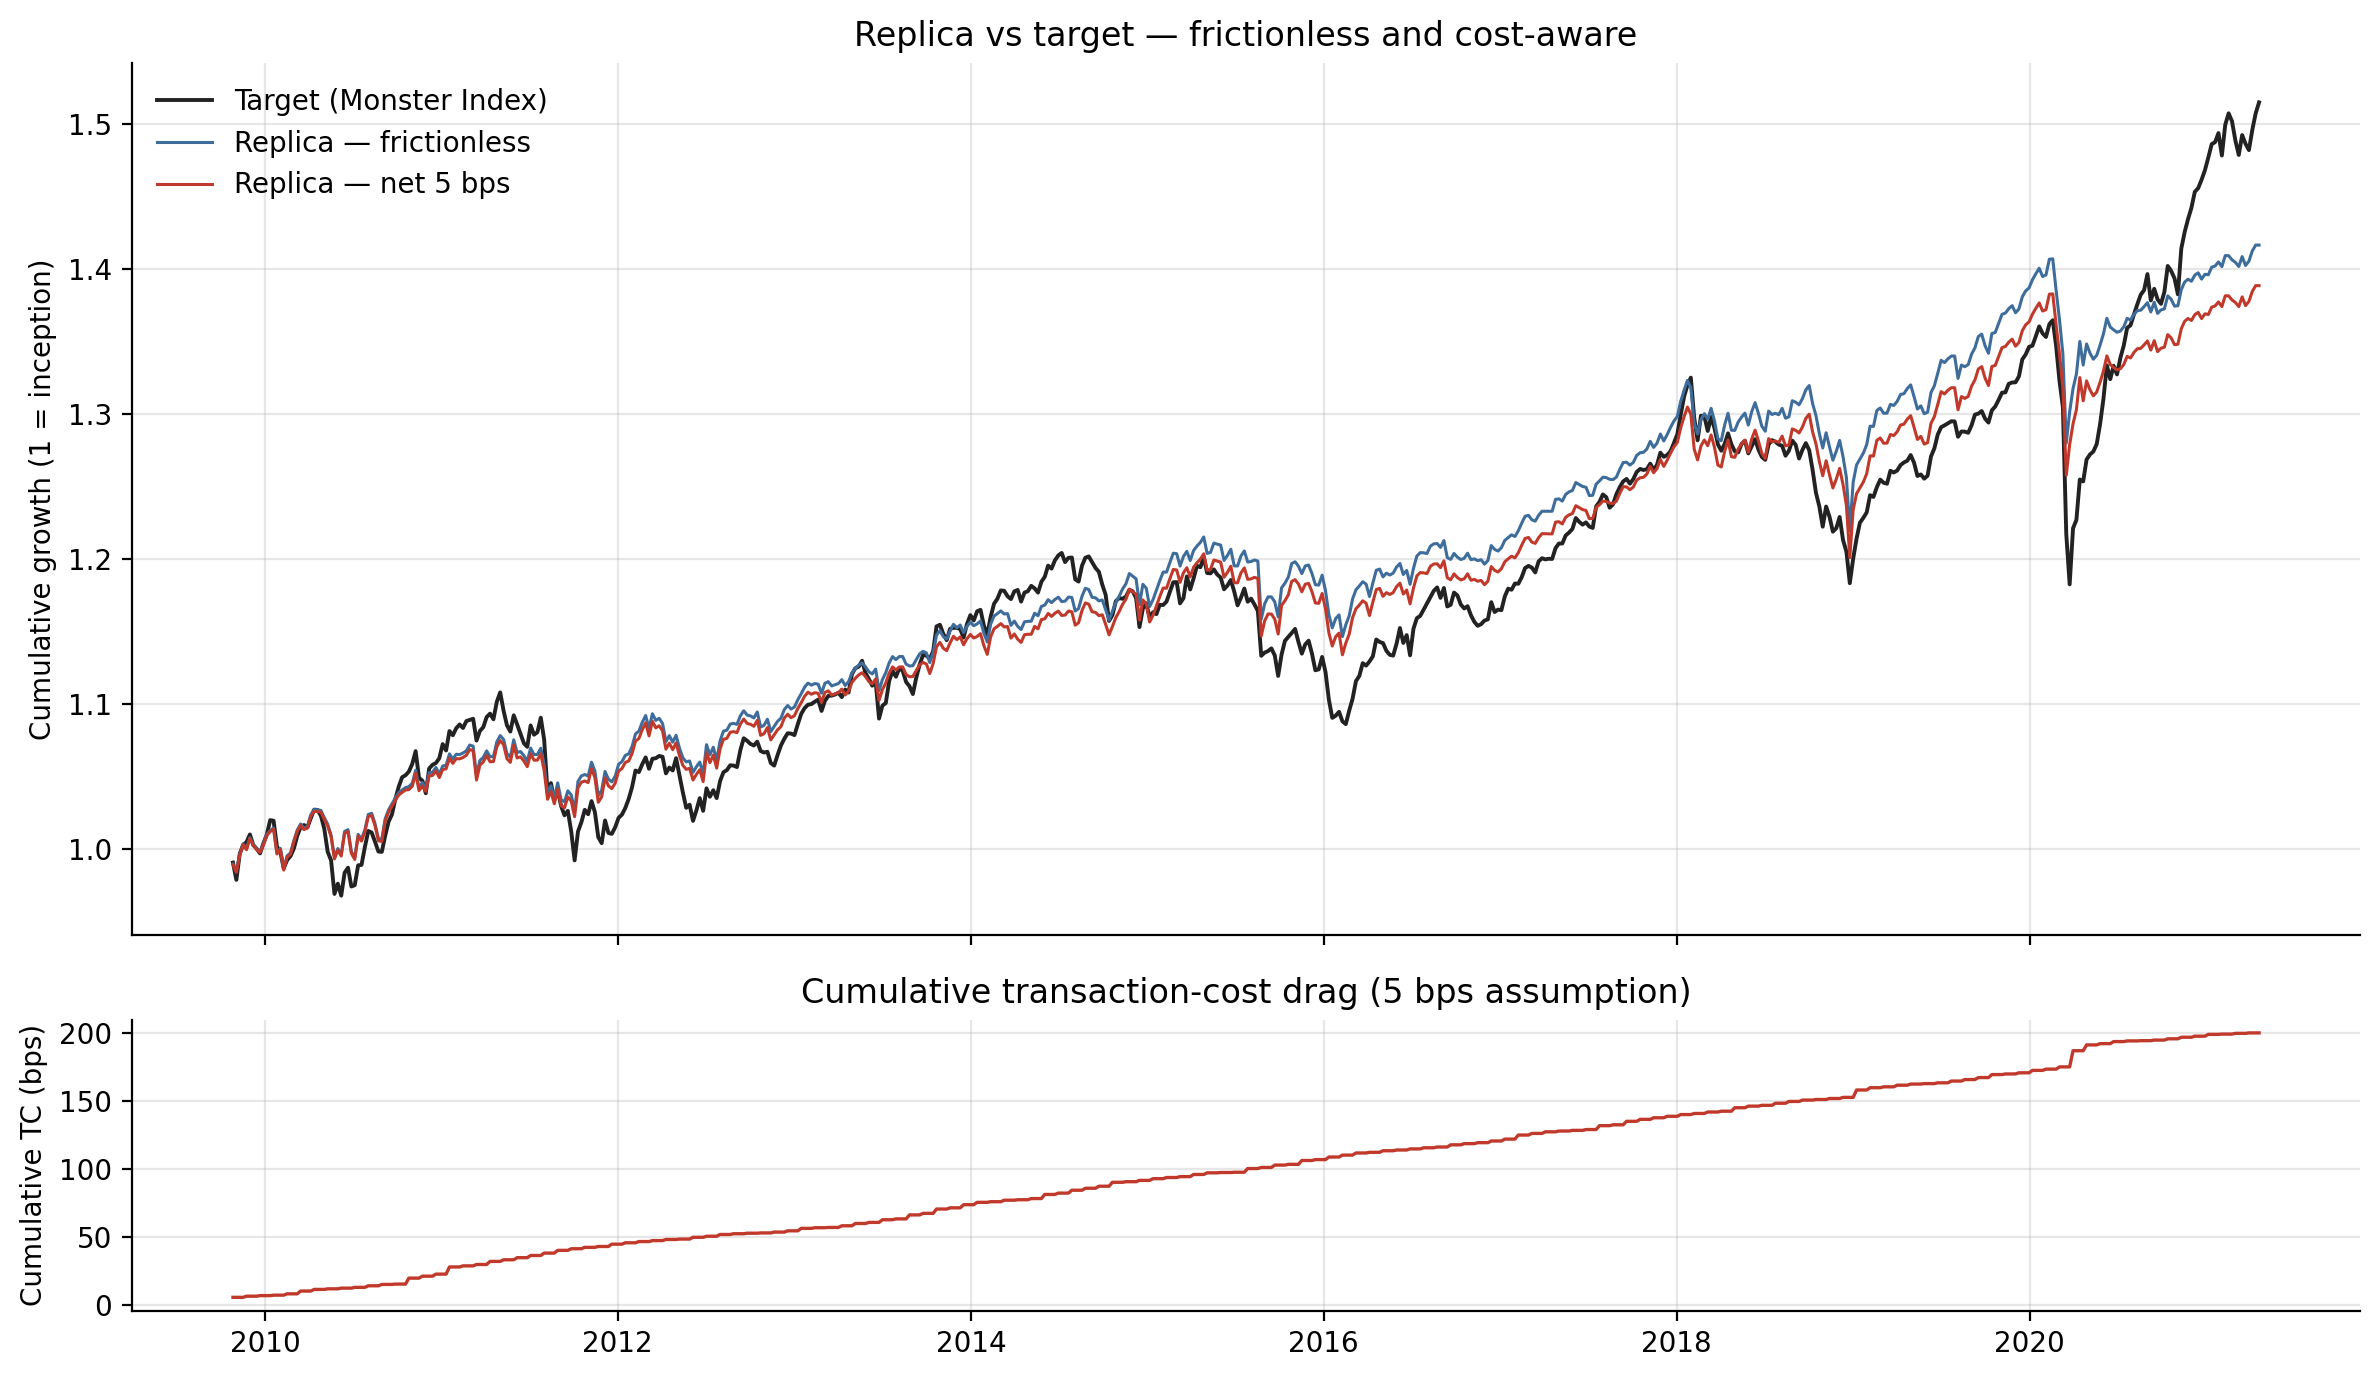

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})
ax0, ax1 = axes

for s, lbl, c in [(res_frictionless.target,        "Target (Monster Index)",  "#222"),
                   (res_frictionless.replica_net,    "Replica — frictionless", "#3E6D9C"),
                   (res_costed.replica_net,          "Replica — net 5 bps",     "#C0392B")]:
    ax0.plot((1+s).cumprod(), label=lbl, color=c, lw=1.4 if "Target" in lbl else 1.1)
ax0.set_ylabel("Cumulative growth (1 = inception)")
ax0.set_title("Replica vs target — frictionless and cost-aware")
ax0.legend(loc="upper left")

ax1.plot(res_costed.tc_cumulative * 1e4, color="#C0392B", lw=1.2)
ax1.set_ylabel("Cumulative TC (bps)")
ax1.set_title("Cumulative transaction-cost drag (5 bps assumption)")
fig.tight_layout()
plt.show()

**Graph explanation.** The upper panel compares cumulative growth of the target, the frictionless replica and the net-of-cost replica. The lower panel shows cumulative transaction-cost drag in basis points. The key message is that a model can look statistically useful before costs, but its tradable version must be judged after implementation costs.

**Honest reading.** The Ridge control model has a **negative net information ratio** under realistic costs. This is not hidden. It means the control model captures direction reasonably well, but transaction costs, tracking gaps and under/over-exposure can still damage net active performance. The pipeline therefore evaluates beta, tracking error, net IR, turnover, transaction costs and risk together. That is stronger than presenting only correlation.


## Cost-sensitivity diagnostic

**Goal.** Quantify how the contract metrics degrade as the assumed flat transaction cost changes from 0 to 20 bps.

**Method.** Re-run the same Ridge configuration through flat-bps transaction-cost assumptions only. The model family, rolling window, rebalance frequency and risk controls are unchanged. A bootstrap 95% CI on `net_TE` and `net_IR` (stationary block bootstrap, Politis & Romano 1994) is included for the main sweep.

In [50]:
TC_SCENARIOS = {
    "frictionless":          None,
    "2 bps":                 FlatBpsTC(2.0),
    "5 bps":                 FlatBpsTC(5.0),
    "10 bps":                FlatBpsTC(10.0),
    "20 bps":                FlatBpsTC(20.0),
    "½-spread + √-impact":   HalfSpreadPlusImpactTC(half_spread_bps=2.0, impact_coef_bps=8.0),
}

# Cost-sensitivity sweep
sens = cost_sensitivity_sweep(
    X, y, ridge_factory, TC_SCENARIOS,
    config=BASELINE_CFG,
)
sens.style.format({
    "IR": "{:+.2f}", "TE": "{:.2%}", "net_IR": "{:+.2f}", "net_TE": "{:.2%}",
    "rho": "{:.3f}", "GE": "{:.2f}", "VaR": "{:.2%}",
    "turnover": "{:.3f}", "tc_total_bps": "{:.1f}",
    "ann_ret_net": "{:+.2%}", "max_drawdown_net": "{:.2%}",
}).set_caption("Cost-sensitivity sweep — same Ridge baseline, six TC regimes")

,IR,TE,net_IR,net_TE,rho,GE,VaR,turnover,annual_turnover,tc_total_bps,tc_bps_per_year,ann_ret_net,max_drawdown_net,n_rebalances,n_obs
scenario,,,,,,,,,,,,,,,
frictionless,-0.21,3.10%,-0.21,3.10%,0.837,1.64,2.86%,0.067,3.463065,0.0,0.000000,+3.12%,9.03%,150,600
2 bps,-0.21,3.10%,-0.23,3.10%,0.836,1.64,2.86%,0.067,3.463065,79.9,6.926129,+3.05%,9.03%,150,600
5 bps,-0.21,3.10%,-0.26,3.11%,0.836,1.64,2.86%,0.067,3.463065,199.8,17.315323,+2.95%,9.04%,150,600
10 bps,-0.21,3.10%,-0.32,3.12%,0.835,1.64,2.86%,0.067,3.463065,399.6,34.630646,+2.78%,9.06%,150,600
20 bps,-0.21,3.10%,-0.42,3.14%,0.832,1.64,2.86%,0.067,3.463065,799.2,69.261291,+2.43%,9.09%,150,600
½-spread + √-impact,-0.21,3.10%,-0.26,3.11%,0.835,1.64,2.86%,0.067,3.463065,193.0,16.728773,+2.96%,9.04%,150,600


In [51]:
# Bootstrap CI on the 5 bps result
ci = stationary_block_bootstrap_ci(res_costed.replica_net, res_costed.target,
                                      n_boot=500, ci_level=0.95, seed=42)
ci_df = pd.DataFrame([ci]).T.rename(columns={0: "value"})
ci_df.style.format({"value": "{:+.4f}"}) \
    .set_caption("Bootstrap 95% CI on net TE and net IR (5 bps scenario)")

,value
te_mean,+0.0306
te_lo,+0.0242
te_hi,+0.0400
ir_mean,-0.2573
ir_lo,-0.9566
ir_hi,+0.3426


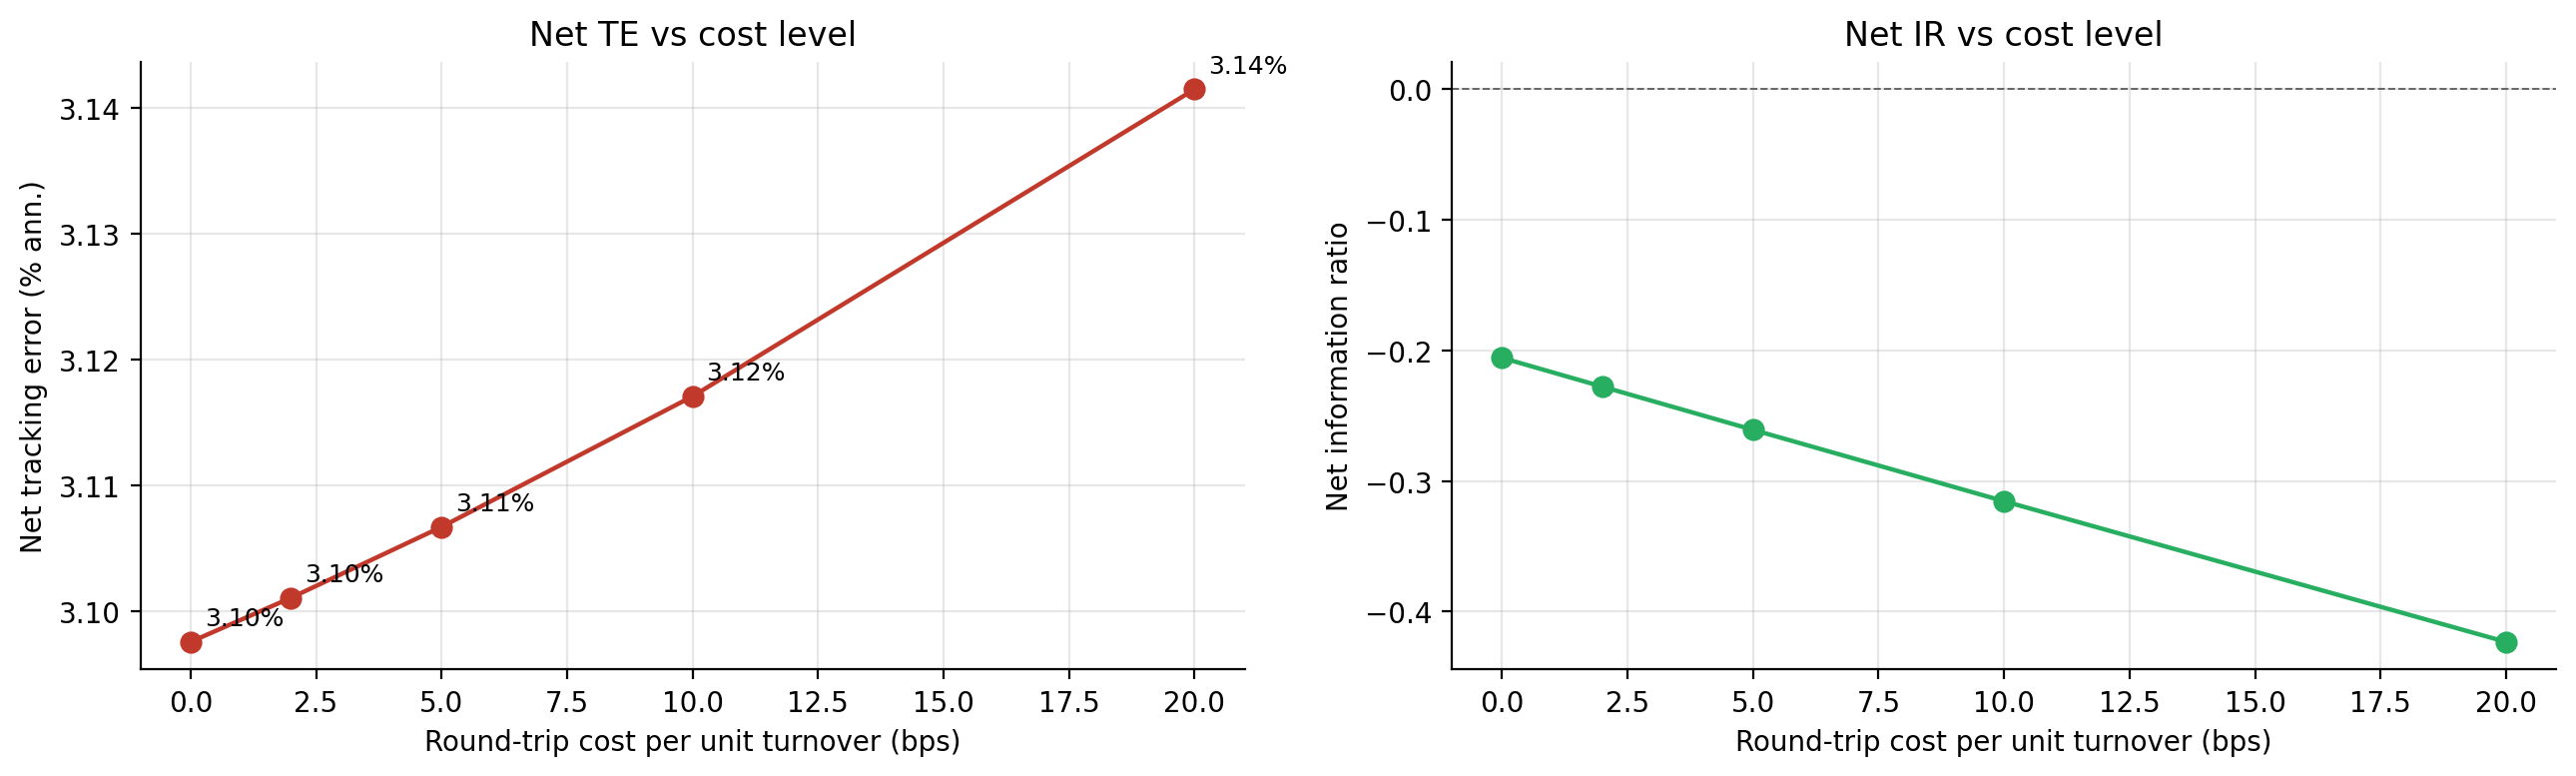

In [52]:
# Pareto-style plot: net_TE vs cost level (excluding the impact model)
flat_rows = sens.loc[["frictionless", "2 bps", "5 bps", "10 bps", "20 bps"]]
bps_levels = [0, 2, 5, 10, 20]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(bps_levels, flat_rows["net_TE"] * 100, "o-", color="#C0392B", lw=1.6, ms=7)
axes[0].set_xlabel("Round-trip cost per unit turnover (bps)")
axes[0].set_ylabel("Net tracking error (% ann.)")
axes[0].set_title("Net TE vs cost level")
for x, t in zip(bps_levels, flat_rows["net_TE"] * 100):
    axes[0].annotate(f"{t:.2f}%", (x, t), xytext=(5, 6),
                      textcoords="offset points", fontsize=9)

axes[1].plot(bps_levels, flat_rows["net_IR"], "o-", color="#27AE60", lw=1.6, ms=7)
axes[1].axhline(0, color="#666", lw=0.7, ls="--")
axes[1].set_xlabel("Round-trip cost per unit turnover (bps)")
axes[1].set_ylabel("Net information ratio")
axes[1].set_title("Net IR vs cost level")
fig.tight_layout()
plt.show()

**Graph explanation.** The left panel shows how annualised net tracking error behaves as the assumed flat transaction cost rises. The right panel shows the corresponding net information ratio. This does not change the strategy; it only shows how sensitive the already-defined baseline is to cost assumptions.

## Risk audit (single-model)

**Goal.** Read the Ridge-control result against the project's risk limits. This is not a model comparison — it is a check that the control run respects the GE and VaR caps.

In [53]:
risk = risk_audit_table(res_costed)
display(risk.style.format({
    "value": "{:.4f}", "limit": "{:.4f}",
}).set_caption("Risk-audit table — Ridge control under 5 bps"))

,value
Average GE,1.6387
Maximum GE,2.0000
GE cap,2.0000
GE breaches - all weeks,0.0000
Average VaR,0.0286
Maximum VaR,0.0660
VaR cap,0.2000
VaR breaches - all weeks,0.0000
VaR breaches - rebalance dates,0.0000
Maximum absolute single future weight,1.4071


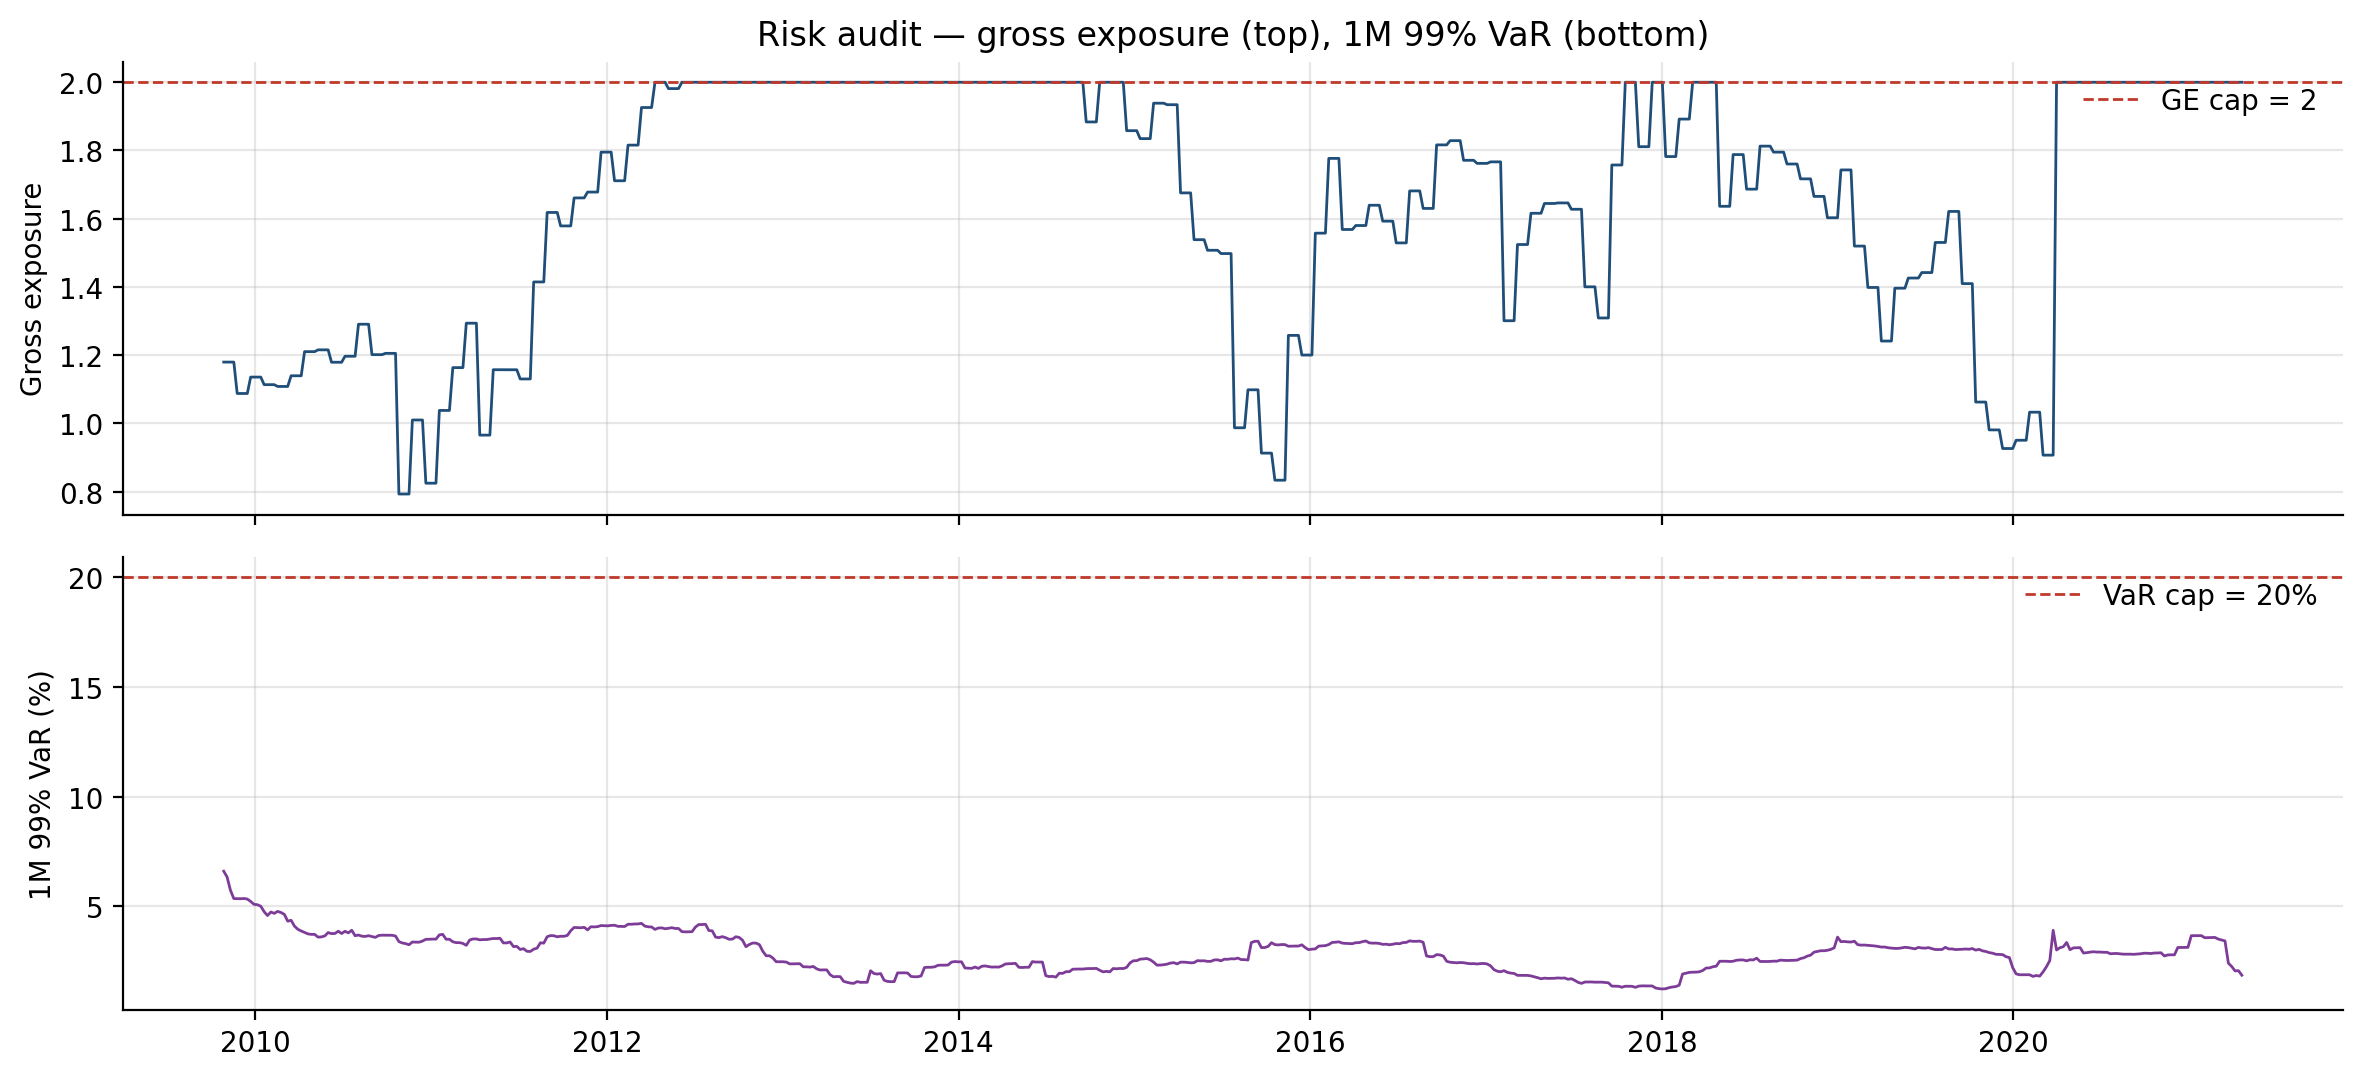

In [54]:
# Quick visual of GE and VaR through time
fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)

axes[0].plot(res_costed.gross_exposure, color="#1F4E79", lw=1.0)
axes[0].axhline(BASELINE_CFG.ge_cap, color="#C0392B", lw=1.0, ls="--",
                 label=f"GE cap = {BASELINE_CFG.ge_cap:.0f}")
axes[0].set_ylabel("Gross exposure")
axes[0].set_title("Risk audit — gross exposure (top), 1M 99% VaR (bottom)")
axes[0].legend(loc="upper right")

axes[1].plot(res_costed.var_series * 100, color="#7D3C98", lw=1.0)
axes[1].axhline(BASELINE_CFG.var_cap * 100, color="#C0392B", lw=1.0, ls="--",
                 label=f"VaR cap = {BASELINE_CFG.var_cap:.0%}")
axes[1].set_ylabel("1M 99% VaR (%)")
axes[1].legend(loc="upper right")
fig.tight_layout()
plt.show()

**Graph explanation.** The upper panel checks whether gross notional exposure stays under the mandate cap. The lower panel checks projected one-month 99% VaR against the VaR cap. The important result is not only the average level; it is whether the line breaches the limit during the evaluated backtest.

## Benchmark controls and validation-selected baseline

A serious shared evaluation layer should not rely on a single model in isolation. The table below compares simple baseline controls and rolling model controls under the same dates, the same 5 bps transaction-cost assumption and the same shared contract.

The purpose is **pipeline validation**, not to solve unrelated project sections. The Ridge run from §10 remains a transparent diagnostic control. The canonical project artifact is selected from the validation set only, then exported separately while the original Ridge control is preserved for auditability.

In [55]:
benchmark_results = {}

# Simple baseline controls.
zero_weights = pd.DataFrame(0.0, index=res_costed.rebalance_dates, columns=X.columns)
equal_weights = pd.DataFrame(1.0 / len(X.columns), index=res_costed.rebalance_dates, columns=X.columns)

benchmark_results["Zero exposure"] = evaluate_weights(
    X, y, zero_weights, schedule_type="rebalance",
    tc_model=FlatBpsTC(5.0), config=BASELINE_CFG, name="zero_exposure"
)
benchmark_results["Equal-weight futures"] = evaluate_weights(
    X, y, equal_weights, schedule_type="rebalance",
    tc_model=FlatBpsTC(5.0), config=BASELINE_CFG, name="equal_weight_futures"
)
benchmark_results["Static full-sample OLS diagnostic"] = evaluate_weights(
    X, y,
    make_static_ols_weights(X, y, res_costed.rebalance_dates, ge_cap=BASELINE_CFG.ge_cap),
    schedule_type="rebalance", tc_model=FlatBpsTC(5.0), config=BASELINE_CFG,
    name="static_full_sample_OLS_diagnostic"
)
for future in ["ES1", "NQ1", "VG1"]:
    benchmark_results[f"Beta-scaled {future} benchmark"] = evaluate_weights(
        X, y,
        make_beta_scaled_single_future_weights(X, y, future, res_costed.rebalance_dates, ge_cap=BASELINE_CFG.ge_cap),
        schedule_type="rebalance", tc_model=FlatBpsTC(5.0), config=BASELINE_CFG,
        name=f"beta_scaled_{future}"
    )

# Rolling controls. These are baseline validation checks for the evaluation layer,
# not separate project sections.
benchmark_results.update({
    "Rolling OLS": run_rolling_backtest(
        X, y, lambda: LinearRegression(fit_intercept=False), config=BASELINE_CFG, tc_model=FlatBpsTC(5.0)
    ),
    "Rolling Ridge α=0.1": run_rolling_backtest(
        X, y, lambda: Ridge(alpha=0.1, fit_intercept=False), config=BASELINE_CFG, tc_model=FlatBpsTC(5.0)
    ),
    "Rolling Ridge α=1": res_costed,
    "Rolling Ridge α=10": run_rolling_backtest(
        X, y, lambda: Ridge(alpha=10.0, fit_intercept=False), config=BASELINE_CFG, tc_model=FlatBpsTC(5.0)
    ),
    "Rolling Lasso α=1e-4": run_rolling_backtest(
        X, y, lambda: Lasso(alpha=1e-4, fit_intercept=False, max_iter=20000), config=BASELINE_CFG, tc_model=FlatBpsTC(5.0)
    ),
    "Rolling ElasticNet α=1e-4": run_rolling_backtest(
        X, y, lambda: ElasticNet(alpha=1e-4, l1_ratio=0.5, fit_intercept=False, max_iter=20000), config=BASELINE_CFG, tc_model=FlatBpsTC(5.0)
    ),
    "Rolling Huber": run_rolling_backtest(
        X, y, lambda: HuberRegressor(alpha=1e-4, fit_intercept=False, max_iter=500), config=BASELINE_CFG, tc_model=FlatBpsTC(5.0)
    ),
})

# Constrained/cost-aware benchmark controls. They remain baseline validation tools:
# they test whether directly penalising turnover improves implementability.
for label, spec in {
    "Constrained TE optimizer": dict(method="constrained_te", l2_penalty=1e-6, turnover_l1_penalty=0.0),
    "Cost-aware optimizer γ=1e-6": dict(method="cost_aware_l1_delta", l2_penalty=1e-6, turnover_l1_penalty=1e-6),
    "Cost-aware optimizer γ=5e-6": dict(method="cost_aware_l1_delta", l2_penalty=1e-6, turnover_l1_penalty=5e-6),
    "Cost-aware optimizer γ=1e-5": dict(method="cost_aware_l1_delta", l2_penalty=1e-6, turnover_l1_penalty=1e-5),
}.items():
    w = build_optimizer_weights(X, y, config=BASELINE_CFG, **spec)
    benchmark_results[label] = evaluate_weights(
        X, y, w, schedule_type="rebalance", tc_model=FlatBpsTC(5.0), config=BASELINE_CFG, name=label
    )

benchmark_table = benchmark_result_table(benchmark_results)
benchmark_display = benchmark_table.copy()
benchmark_formatters = {
    "rho": "{:.3f}", "beta_to_target": "{:.2f}", "TE": "{:.2%}", "net_TE": "{:.2%}",
    "IR": "{:+.2f}", "net_IR": "{:+.2f}", "ann_ret_net": "{:+.2%}",
    "max_drawdown_net": "{:.2%}", "GE": "{:.2f}", "max_GE": "{:.2f}",
    "VaR": "{:.2%}", "max_VaR": "{:.2%}", "annual_turnover": "{:.3f}",
    "tc_total_bps": "{:.1f}", "n_rebalances": "{:.0f}", "n_obs": "{:.0f}",
}
for col, fmt in benchmark_formatters.items():
    if col in benchmark_display.columns:
        benchmark_display[col] = benchmark_display[col].map(lambda v, f=fmt: "" if pd.isna(v) else f.format(v))

print("Benchmark controls — pipeline validation under the same shared contract")
display(benchmark_display)

# Validation discipline: choose the canonical baseline on a validation window only.
validation_windows = {
    "validation_2016_2018": ("2016-01-01", "2018-12-31"),
    "test_2019_2021": ("2019-01-01", "2021-04-20"),
}
validation_candidates = {
    k: benchmark_results[k]
    for k in [
        "Rolling Ridge α=1", "Rolling Ridge α=10", "Rolling Huber",
        "Constrained TE optimizer", "Cost-aware optimizer γ=1e-6",
        "Cost-aware optimizer γ=5e-6", "Cost-aware optimizer γ=1e-5", "Equal-weight futures",
    ]
}
validation_table = split_diagnostics(validation_candidates, validation_windows)
selection_pool = validation_table.xs("validation_2016_2018", level="window").drop(index="Equal-weight futures", errors="ignore")
best_validation_te = selection_pool["net_TE"].min()
te_tolerance = 0.0002  # 2 annualised bps of net tracking error
selection_pool_near_best = selection_pool[selection_pool["net_TE"] <= best_validation_te + te_tolerance]
selected_label = selection_pool_near_best.sort_values(["annual_turnover", "net_TE"]).index[0]
selected_result = validation_candidates[selected_label]
assert validate_project_interface(selected_result, X, y)

print(f"\nValidation-selected canonical baseline: {selected_label}")
print("Selection rule: among controls within 2 annualised bps of the best validation net TE, choose the lowest annual turnover.")
display(validation_table.round(6))


Benchmark controls — pipeline validation under the same shared contract


,rho,TE,net_TE,IR,net_IR,ann_ret_net,beta_to_target,max_drawdown_net,GE,max_GE,VaR,max_VaR,annual_turnover,tc_total_bps,n_rebalances,n_obs
benchmark,,,,,,,,,,,,,,,,
Static full-sample OLS diagnostic,0.873,2.75%,2.75%,+0.06,+0.06,+3.92%,0.76,9.96%,1.00,1.00,3.14%,6.66%,0.087,5.0,150,600
Cost-aware optimizer γ=5e-6,0.853,2.95%,2.95%,+0.07,+0.07,+3.95%,0.75,9.54%,0.66,0.98,3.17%,6.52%,0.185,10.7,150,600
Cost-aware optimizer γ=1e-5,0.852,2.96%,2.96%,-0.04,-0.05,+3.62%,0.72,9.35%,0.59,0.71,3.06%,6.37%,0.118,6.8,150,600
Cost-aware optimizer γ=1e-6,0.847,3.01%,3.01%,+0.10,+0.09,+4.03%,0.75,9.38%,0.82,1.39,3.18%,6.64%,0.475,27.4,150,600
Beta-scaled ES1 benchmark,0.845,3.03%,3.03%,+0.06,+0.06,+3.95%,0.69,9.32%,0.31,0.31,2.98%,5.91%,0.027,1.6,150,600
Rolling Huber,0.844,3.03%,3.03%,-0.02,-0.09,+3.50%,0.71,8.70%,1.59,2.00,3.04%,6.61%,3.886,224.2,150,600
Constrained TE optimizer,0.837,3.08%,3.09%,-0.21,-0.27,+2.94%,0.69,9.13%,1.65,2.00,2.87%,6.63%,3.559,205.3,150,600
Rolling Lasso α=1e-4,0.837,3.09%,3.10%,-0.22,-0.28,+2.90%,0.68,9.13%,1.66,2.00,2.86%,6.63%,3.586,206.9,150,600
Rolling ElasticNet α=1e-4,0.837,3.09%,3.10%,-0.22,-0.28,+2.90%,0.68,9.13%,1.66,2.00,2.86%,6.63%,3.587,207.0,150,600



Validation-selected canonical baseline: Cost-aware optimizer γ=5e-6
Selection rule: among controls within 2 annualised bps of the best validation net TE, choose the lowest annual turnover.


start         end  \
model                       window                                         
Rolling Ridge α=1           validation_2016_2018  2016-01-01  2018-12-31   
                            test_2019_2021        2019-01-01  2021-04-20   
Rolling Ridge α=10          validation_2016_2018  2016-01-01  2018-12-31   
                            test_2019_2021        2019-01-01  2021-04-20   
Rolling Huber               validation_2016_2018  2016-01-01  2018-12-31   
                            test_2019_2021        2019-01-01  2021-04-20   
Constrained TE optimizer    validation_2016_2018  2016-01-01  2018-12-31   
                            test_2019_2021        2019-01-01  2021-04-20   
Cost-aware optimizer γ=1e-6 validation_2016_2018  2016-01-01  2018-12-31   
                            test_2019_2021        2019-01-01  2021-04-20   
Cost-aware optimizer γ=5e-6 validation_2016_2018  2016-01-01  2018-12-31   
                            test_2019_2021        2019-01-01  2021-04-20   
Cost-aware optimizer γ=1e-5 validation_2016_2018  2016-01-01  2018-12-31   
                            test_2019_2021        2019-01-01  2021-04-20   
Equal-weight futures        validation_2016_2018  2016-01-01  2018-12-31   
                            test_2019_2021        2019-01-01  2021-04-20   

                                                  n_obs       rho  \
model                       window                                  
Rolling Ridge α=1           validation_2016_2018    156  0.852045   
                            test_2019_2021          121  0.757493   
Rolling Ridge α=10          validation_2016_2018    156  0.851216   
                            test_2019_2021          121  0.745796   
Rolling Huber               validation_2016_2018    156  0.853543   
                            test_2019_2021          121  0.782926   
Constrained TE optimizer    validation_2016_2018    156  0.851806   
                            test_2019_2021          121  0.764665   
Cost-aware optimizer γ=1e-6 validation_2016_2018    156  0.852422   
                            test_2019_2021          121  0.793975   
Cost-aware optimizer γ=5e-6 validation_2016_2018    156  0.849534   
                            test_2019_2021          121  0.810690   
Cost-aware optimizer γ=1e-5 validation_2016_2018    156  0.844425   
                            test_2019_2021          121  0.804808   
Equal-weight futures        validation_2016_2018    156  0.778208   
                            test_2019_2021          121  0.693271   

                                                  beta_to_target    net_TE  \
model                       window                                           
Rolling Ridge α=1           validation_2016_2018        0.774141  0.023645   
                            test_2019_2021              0.554460  0.046805   
Rolling Ridge α=10          validation_2016_2018        0.735418  0.023575   
                            test_2019_2021              0.522305  0.047836   
Rolling Huber               validation_2016_2018        0.796733  0.023672   
                            test_2019_2021              0.621650  0.044575   
Constrained TE optimizer    validation_2016_2018        0.779745  0.023698   
                            test_2019_2021              0.569261  0.046190   
Cost-aware optimizer γ=1e-6 validation_2016_2018        0.752216  0.023519   
                            test_2019_2021              0.703069  0.044044   
Cost-aware optimizer γ=5e-6 validation_2016_2018        0.715529  0.023693   
                            test_2019_2021              0.720719  0.042317   
Cost-aware optimizer γ=1e-5 validation_2016_2018        0.656516  0.024243   
                            test_2019_2021              0.692041  0.042704   
Equal-weight futures        validation_2016_2018        1.094887  0.039907   
                            test_2019_2021              1.018072  0.075829   

                                      

**Table explanation and interpretation.** This table prevents a common weakness in portfolio projects: showing one model without context. The zero and equal-weight controls define simple floors, the static OLS diagnostic is a non-tradeable upper-bound sanity check, and the beta-scaled single-future benchmarks show what a "just buy beta" implementation would look like. Rolling OLS, Ridge, Lasso, ElasticNet and Huber act as transparent model controls. The constrained and cost-aware optimizers test whether the same shared contract benefits from explicit turnover and implementability penalties.

**Validation discipline.** The canonical baseline is selected using the validation window only. The test window is displayed for honesty, but it is not used to tune the selected baseline. The Ridge control remains preserved as a diagnostic artifact, while `selected_result` is the validation-selected artifact used in the remaining risk, stress, persistence and dashboard sections.

**Important discipline.** The static full-sample OLS row is explicitly labelled diagnostic because it uses the whole sample and is not a no-look-ahead tradeable strategy.

## Expanded risk dashboard

The basic GE/VaR audit is necessary but not enough. The dashboard below is built on the validation-selected canonical baseline, because this is the project artifact after the benchmark and validation checks. An industry-style review asks how exposure is split between long and short books, whether net exposure is drifting, and whether tail risk is visible beyond Gaussian VaR.

In [56]:
exposure_dashboard = exposure_dashboard(selected_result)
rolling_risk = rolling_risk_dashboard(selected_result, window=52)

risk_summary = pd.DataFrame({
    "Average": [
        exposure_dashboard["long_exposure"].mean(),
        exposure_dashboard["short_exposure"].mean(),
        exposure_dashboard["net_exposure"].mean(),
        exposure_dashboard["gross_exposure"].mean(),
        exposure_dashboard["max_abs_weight"].mean(),
        rolling_risk["rolling_gaussian_VaR_1m_99"].mean(),
        rolling_risk["rolling_historical_VaR_1m_99"].mean(),
        rolling_risk["rolling_expected_shortfall_1m_99"].mean(),
    ],
    "Maximum / Worst": [
        exposure_dashboard["long_exposure"].max(),
        exposure_dashboard["short_exposure"].min(),
        exposure_dashboard["net_exposure"].abs().max(),
        exposure_dashboard["gross_exposure"].max(),
        exposure_dashboard["max_abs_weight"].max(),
        rolling_risk["rolling_gaussian_VaR_1m_99"].max(),
        rolling_risk["rolling_historical_VaR_1m_99"].max(),
        rolling_risk["rolling_expected_shortfall_1m_99"].max(),
    ],
}, index=[
    "Long exposure", "Short exposure", "Net exposure", "Gross exposure", "Max abs single weight",
    "Rolling Gaussian VaR", "Rolling historical VaR", "Rolling Expected Shortfall",
])

display(risk_summary.style.format("{:.2%}").set_caption("Expanded risk dashboard"))

,Average,Maximum / Worst
Long exposure,65.09%,85.87%
Short exposure,-1.16%,-12.59%
Net exposure,63.94%,73.85%
Gross exposure,66.25%,97.94%
Max abs single weight,24.01%,46.31%
Rolling Gaussian VaR,3.06%,5.67%
Rolling historical VaR,3.26%,6.92%
Rolling Expected Shortfall,4.26%,10.37%


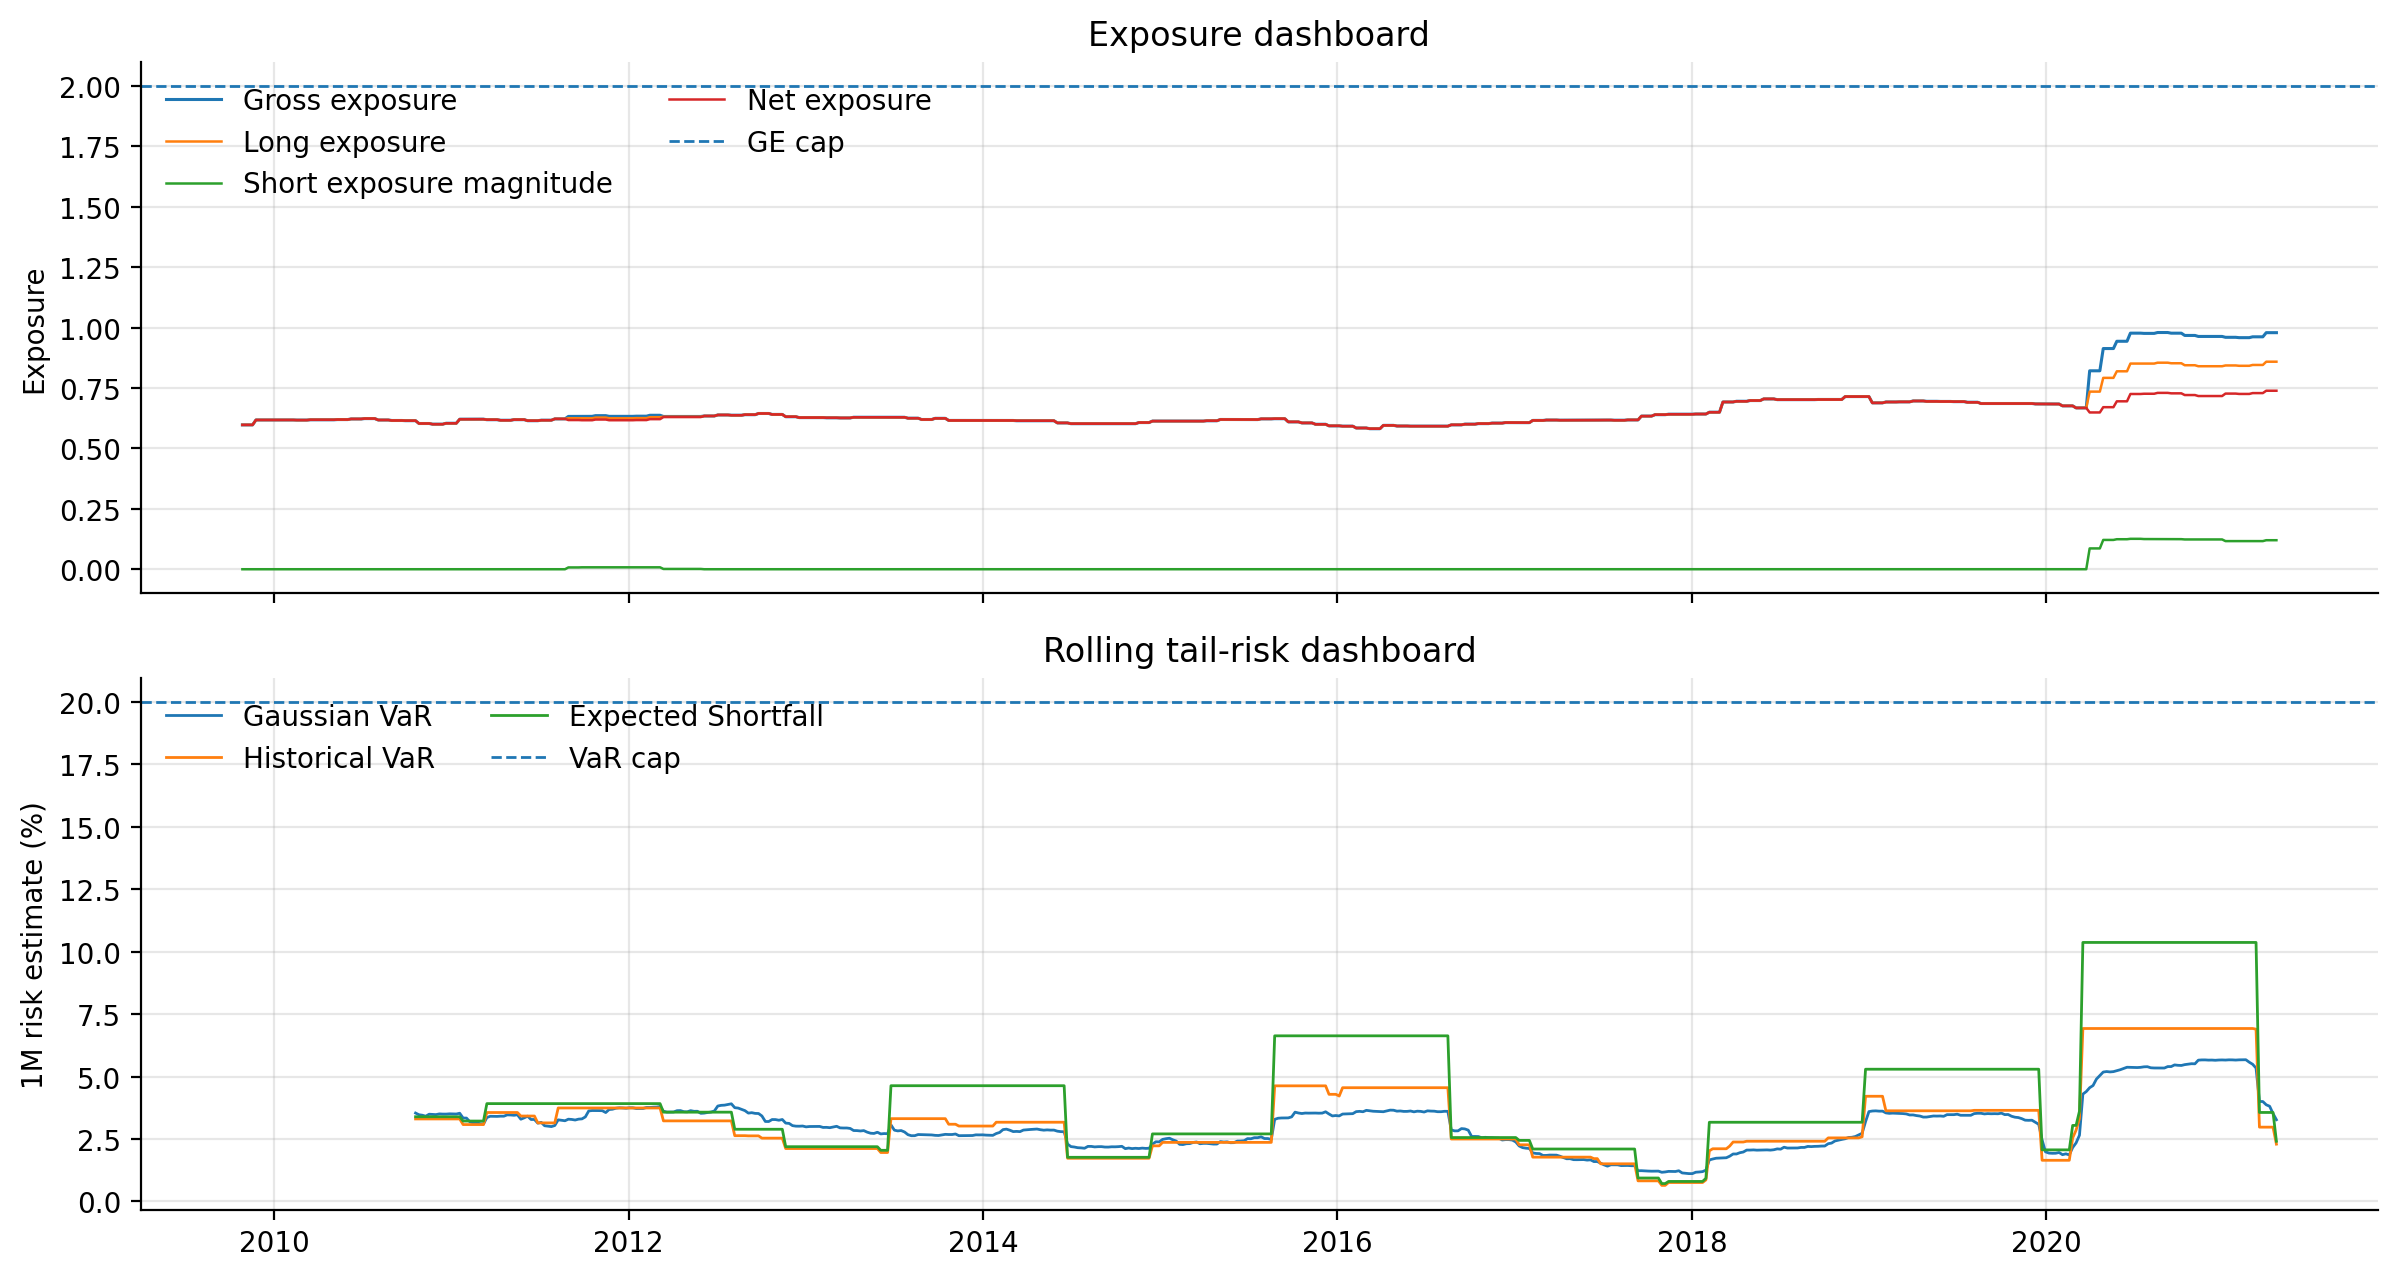

In [57]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
axes[0].plot(exposure_dashboard.index, exposure_dashboard["gross_exposure"], label="Gross exposure", lw=1.1)
axes[0].plot(exposure_dashboard.index, exposure_dashboard["long_exposure"], label="Long exposure", lw=0.9)
axes[0].plot(exposure_dashboard.index, exposure_dashboard["short_exposure"].abs(), label="Short exposure magnitude", lw=0.9)
axes[0].plot(exposure_dashboard.index, exposure_dashboard["net_exposure"], label="Net exposure", lw=0.9)
axes[0].axhline(BASELINE_CFG.ge_cap, lw=1.0, ls="--", label="GE cap")
axes[0].set_ylabel("Exposure")
axes[0].set_title("Exposure dashboard")
axes[0].legend(loc="upper left", ncol=2)

axes[1].plot(rolling_risk.index, rolling_risk["rolling_gaussian_VaR_1m_99"] * 100, label="Gaussian VaR", lw=1.0)
axes[1].plot(rolling_risk.index, rolling_risk["rolling_historical_VaR_1m_99"] * 100, label="Historical VaR", lw=1.0)
axes[1].plot(rolling_risk.index, rolling_risk["rolling_expected_shortfall_1m_99"] * 100, label="Expected Shortfall", lw=1.0)
axes[1].axhline(BASELINE_CFG.var_cap * 100, lw=1.0, ls="--", label="VaR cap")
axes[1].set_ylabel("1M risk estimate (%)")
axes[1].set_title("Rolling tail-risk dashboard")
axes[1].legend(loc="upper left", ncol=2)
fig.tight_layout()
plt.show()

**Graph explanation.** The upper panel shows whether the portfolio is simply increasing leverage or whether the long/short structure is changing. The lower panel reads the same evaluated baseline through rolling tracking error, rolling VaR and rolling transaction cost. This is a backtest-quality check, not a separate strategy comparison.

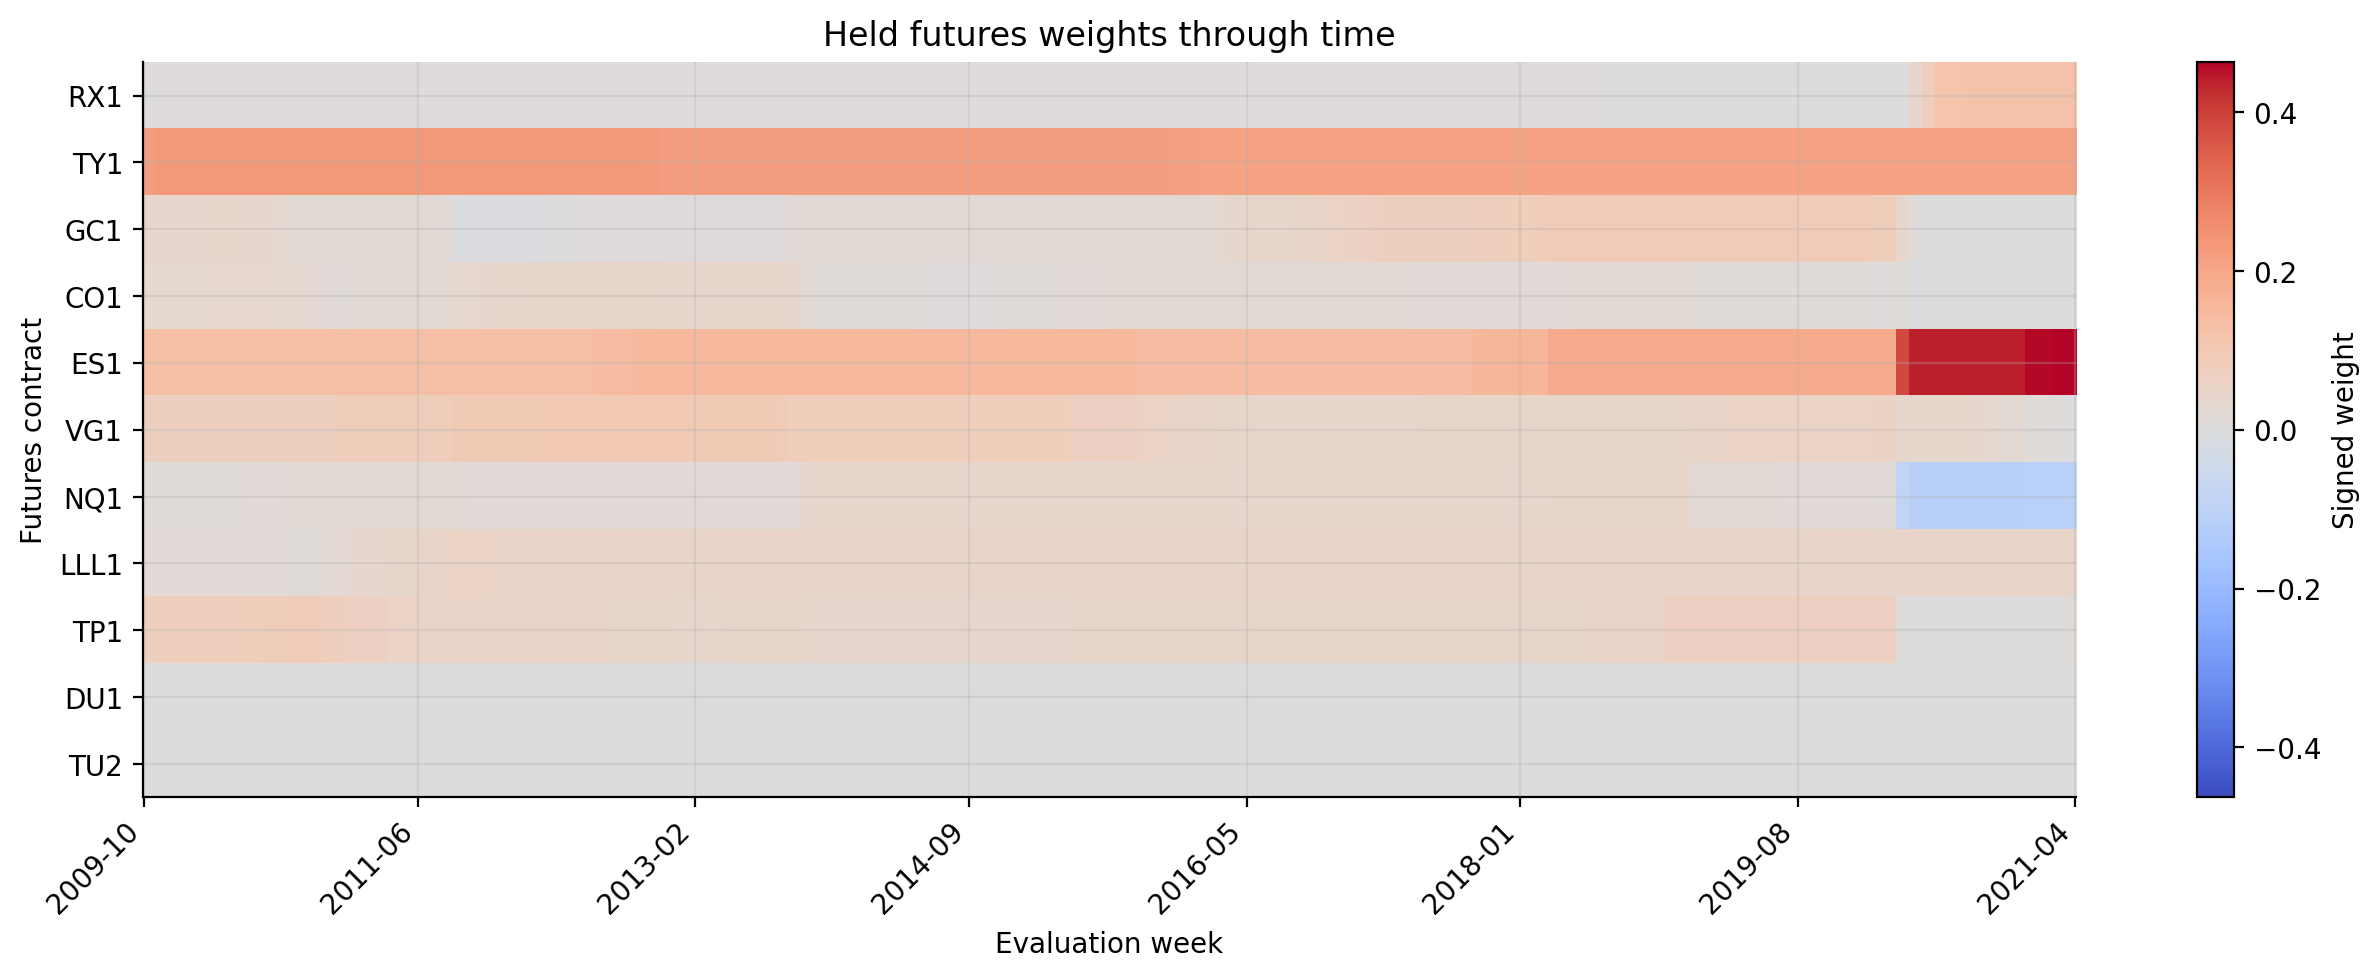

In [58]:
# Weight heatmap: visual audit of concentration and stability.
weights_for_heatmap = selected_result.held_weights_history.copy()
lim = float(np.nanmax(np.abs(weights_for_heatmap.values)))
fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(
    weights_for_heatmap.T.values,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=-lim,
    vmax=lim,
)
ax.set_yticks(np.arange(len(weights_for_heatmap.columns)))
ax.set_yticklabels(weights_for_heatmap.columns)
xticks = np.linspace(0, len(weights_for_heatmap.index) - 1, 8, dtype=int)
ax.set_xticks(xticks)
ax.set_xticklabels([weights_for_heatmap.index[i].strftime("%Y-%m") for i in xticks], rotation=45, ha="right")
ax.set_title("Held futures weights through time")
ax.set_xlabel("Evaluation week")
ax.set_ylabel("Futures contract")
fig.colorbar(im, ax=ax, label="Signed weight")
fig.tight_layout()
plt.show()

**Graph explanation.** This heatmap shows which futures carry the portfolio over time. Large continuous bands indicate persistent exposures; abrupt colour changes indicate rebalances or weight instability. It is a concentration and stability check for the evaluated baseline.

## Persistence — reusable project artifacts

The validation-selected canonical baseline is committed as the main project artifact set. The original Ridge control is also exported separately for auditability; it is not hidden or overwritten.

- `results/pipeline.pkl` — canonical `ReplicaResult` with full weights, weekly PnL and metrics for the validation-selected baseline.
- `results/pipeline_ridge_control.pkl` — preserved Ridge diagnostic control.
- `results/pipeline_validation_selected.pkl` — duplicate selected-baseline artifact kept for clarity.
- `results/pipeline_weights_rebalance.csv` — rebalance-date weight schedule for the canonical baseline.
- `results/pipeline_holdings_weekly.csv` — weekly forward-filled held weights used for PnL.
- `results/pipeline_returns.csv` — gross/net replica returns, target, costs, GE and VaR.
- `results/pipeline_metrics.json` — contract metrics, run config and input hash.

The pickle round-trip is verified with an `input_hash` check. If `(X, y)` changes, `load_result` raises a clear error rather than silently mixing results built on different data.


In [59]:
# The validation-selected baseline (= selected_result) is committed as the canonical project artifact.
paths = export_result_artifacts(selected_result, OUT, stem="pipeline")
ridge_paths = export_result_artifacts(res_costed, OUT, stem="pipeline_ridge_control")
selected_paths = export_result_artifacts(selected_result, OUT, stem="pipeline_validation_selected")

print("canonical selected-baseline artifacts:")
for kind, p in paths.items():
    print(f"{kind:25s} → {p.name}  ({p.stat().st_size / 1024:.1f} KB)")
print("\npreserved Ridge-control artifacts:")
for kind, p in ridge_paths.items():
    print(f"{kind:25s} → {p.name}  ({p.stat().st_size / 1024:.1f} KB)")

# Round-trip verification
loaded = load_result(paths["pickle"], expected_input_hash=selected_result.input_hash)
assert loaded.metrics == selected_result.metrics
assert loaded.weights_history.equals(selected_result.weights_history)
print(f"\nround-trip verified — canonical baseline: {selected_label}")
print("Ridge control preserved separately, not deleted.")


canonical selected-baseline artifacts:
pickle                    → pipeline.pkl  (274.7 KB)
weights_rebalance         → pipeline_weights_rebalance.csv  (29.6 KB)
holdings_weekly           → pipeline_holdings_weekly.csv  (118.4 KB)
returns                   → pipeline_returns.csv  (109.1 KB)
metrics                   → pipeline_metrics.json  (2.0 KB)
trade_blotter             → pipeline_trade_blotter.csv  (113.0 KB)
asset_cost_attribution    → pipeline_asset_cost_attribution.csv  (1.0 KB)
risk_audit                → pipeline_risk_audit.csv  (0.3 KB)
rolling_diagnostics       → pipeline_rolling_diagnostics.csv  (37.9 KB)
cumulative_returns        → pipeline_cumulative_returns.csv  (51.5 KB)

preserved Ridge-control artifacts:
pickle                    → pipeline_ridge_control.pkl  (278.6 KB)
weights_rebalance         → pipeline_ridge_control_weights_rebalance.csv  (32.6 KB)
holdings_weekly           → pipeline_ridge_control_holdings_weekly.csv  (130.4 KB)
returns                   → pipe

## Rebalancing & Portfolio Constraints sweep

**Goal.** Establish the canonical Ridge baseline above, then sweep rebalancing cadence and gross-exposure cap to surface the trade-off between tracking and turnover under the constraint layer (`apply_ge_cap` + iterative `apply_var_cap_iterative`).

**Method.** Run six base configurations (1/4/12 weeks x 100%/200% GE) followed by an extended 6-axis Cartesian grid; rank by a composite z-scored score over IR, net IR, rho, -TE, -turnover, -MDD.


## Adapter — reuse Part I's `(X, y)`

The standalone team-member notebook builds its own `X_values / y_values / dates / asset_names`. Part I has
already built the same panel, so we just expose them under the names `run_pc_backtest` expects.


In [60]:
X_values_pc = X.values
y_values_pc = y.values.reshape(-1)
asset_names_pc = X.columns.tolist()
dates_pc = X.index.to_numpy()

print(f"X shape  : {X.shape}")
print(f"y length : {len(y_values_pc)}")
print(f"date span: {X.index.min().date()} -> {X.index.max().date()}")

asset_info = {
    "RX1": "Bund (10Y Ger)", "TY1": "10Y US Treasury", "GC1": "Gold", "CO1": "Brent Crude Oil",
    "ES1": "S&P 500", "VG1": "Eurostoxx 50", "NQ1": "Nasdaq 100", "LLL1": "MSCI Emerging Markets",
    "TP1": "Topix (Japan)", "DU1": "2Y German Govt (Schatz)", "TU2": "2Y US Treasury",
}


X shape  : (704, 11)
y length : 704
date span: 2007-10-30 -> 2021-04-20


## Configuration grid — 3 cadences × 2 leverage caps

Six baseline configurations: rebalancing every 1 / 4 / 12 weeks with a 100% or 200% gross-exposure
cap. All other knobs (rolling window 104, ElasticNet α=1e-3 / l1_ratio=0.5, VaR cap 8%, 5 bps
costs) match the team-member's defaults so the merged results reproduce the standalone notebook.


In [61]:
BASELINE_CONFIGS = [
    {"label": "CONFIG 1", "rebal_freq": 1,  "max_gross_exposure": 1.0, "desc": "Weekly / No leverage"},
    {"label": "CONFIG 2", "rebal_freq": 1,  "max_gross_exposure": 2.0, "desc": "Weekly / 200% cap"},
    {"label": "CONFIG 3", "rebal_freq": 4,  "max_gross_exposure": 1.0, "desc": "Monthly / No leverage"},
    {"label": "CONFIG 4", "rebal_freq": 4,  "max_gross_exposure": 2.0, "desc": "Monthly / 200% cap"},
    {"label": "CONFIG 5", "rebal_freq": 12, "max_gross_exposure": 1.0, "desc": "Quarterly / No leverage"},
    {"label": "CONFIG 6", "rebal_freq": 12, "max_gross_exposure": 2.0, "desc": "Quarterly / 200% cap"},
]

PC_ROLLING_WINDOW = 104
PC_MAX_VAR = 0.08
PC_ALPHA = 0.001
PC_L1_RATIO = 0.5
PC_COST_BPS = 5
PC_VAR_CONFIDENCE = 0.01
PC_VAR_HORIZON = 4

constraint_configs_results: dict[str, dict] = {}
for config in BASELINE_CONFIGS:
    label = config["label"]
    result = run_pc_backtest(
        X_values=X_values_pc, y_values=y_values_pc,
        asset_names=asset_names_pc, dates=dates_pc,
        rolling_window=PC_ROLLING_WINDOW,
        rebal_freq=config["rebal_freq"],
        max_gross_exposure=config["max_gross_exposure"],
        max_var=PC_MAX_VAR, step=0.005,
        alpha=PC_ALPHA, l1_ratio=PC_L1_RATIO,
        cost_bps=PC_COST_BPS,
        var_confidence=PC_VAR_CONFIDENCE,
        var_horizon=PC_VAR_HORIZON,
    )
    constraint_configs_results[label] = {"config": config, **result}
    m = result["metrics"]
    print(f"  {label}: IR={m.loc['IR','Value']:+.3f}  TE={m.loc['TE','Value']:.2%}  "
          f"ρ={m.loc['p','Value']:.3f}  GE={m.loc['GE','Value']:.2f}× NAV  ({config['desc']})")


  CONFIG 1: IR=-0.461  TE=3.91%  ρ=0.765  GE=0.19× NAV  (Weekly / No leverage)
  CONFIG 2: IR=-0.461  TE=3.91%  ρ=0.765  GE=0.19× NAV  (Weekly / 200% cap)
  CONFIG 3: IR=-0.480  TE=3.91%  ρ=0.754  GE=0.19× NAV  (Monthly / No leverage)
  CONFIG 4: IR=-0.480  TE=3.91%  ρ=0.754  GE=0.19× NAV  (Monthly / 200% cap)
  CONFIG 5: IR=-0.467  TE=3.82%  ρ=0.783  GE=0.19× NAV  (Quarterly / No leverage)
  CONFIG 6: IR=-0.467  TE=3.82%  ρ=0.783  GE=0.19× NAV  (Quarterly / 200% cap)


## Comparison table — six baseline configurations

A wide leaderboard with annualised return / volatility, Sharpe, TE, IR, ρ, gross exposure,
historical VaR, turnover, net IR / TE after the 5 bps cost, and max drawdown.


In [62]:
constraint_baseline_rows = []
for label, res in constraint_configs_results.items():
    m = res["metrics"]; cfg = res["config"]
    constraint_baseline_rows.append({
        "config": label, "desc": cfg["desc"],
        "rebal_weeks": cfg["rebal_freq"],
        "max_GE_cap": cfg["max_gross_exposure"],
        "ann_ret_rep": m.loc["rep_ann", "Value"],
        "ann_vol_rep": m.loc["rep_vol", "Value"],
        "sharpe":      m.loc["sharpe", "Value"],
        "TE":          m.loc["TE", "Value"],
        "IR":          m.loc["IR", "Value"],
        "rho":         m.loc["p", "Value"],
        "GE_mean":     m.loc["GE", "Value"],
        "VaR":         m.loc["VaR", "Value"],
        "turnover":    m.loc["turnover", "Value"],
        "net_IR":      m.loc["net_IR", "Value"],
        "net_TE":      m.loc["net_TE", "Value"],
        "max_drawdown":m.loc["mdd", "Value"],
    })
constraint_baseline_table = pd.DataFrame(constraint_baseline_rows).set_index("config")
display(format_metrics_dataframe(
    constraint_baseline_table,
    percent_cols=("TE", "net_TE", "VaR", "max_drawdown", "ann_ret_rep", "ann_vol_rep"),
    ratio_cols=("IR", "net_IR", "rho", "sharpe"),
    multiple_cols=("GE_mean", "max_GE_cap", "turnover", "rebal_weeks"),
))


,desc,rebal_weeks,max_GE_cap,ann_ret_rep,ann_vol_rep,sharpe,TE,IR,rho,GE_mean,VaR,turnover,net_IR,net_TE,max_drawdown
config,,,,,,,,,,,,,,,
CONFIG 1,Weekly / No leverage,1.00,1.00,1.92%,2.91%,+0.661,3.91%,-0.461,+0.765,0.19,1.75%,0.01,-0.468,3.91%,4.27%
CONFIG 2,Weekly / 200% cap,1.00,2.00,1.92%,2.91%,+0.661,3.91%,-0.461,+0.765,0.19,1.75%,0.01,-0.468,3.91%,4.27%
CONFIG 3,Monthly / No leverage,4.00,1.00,1.84%,3.03%,+0.608,3.91%,-0.480,+0.754,0.19,1.61%,0.01,-0.484,3.91%,4.52%
CONFIG 4,Monthly / 200% cap,4.00,2.00,1.84%,3.03%,+0.608,3.91%,-0.480,+0.754,0.19,1.61%,0.01,-0.484,3.91%,4.52%
CONFIG 5,Quarterly / No leverage,12.00,1.00,1.94%,2.94%,+0.660,3.82%,-0.467,+0.783,0.19,1.58%,0.00,-0.470,3.82%,4.50%
CONFIG 6,Quarterly / 200% cap,12.00,2.00,1.94%,2.94%,+0.660,3.82%,-0.467,+0.783,0.19,1.58%,0.00,-0.470,3.82%,4.50%


## Cumulative returns — all configurations vs target

A single chart overlaying the cumulative growth of the six replication strategies against the
target index. Configurations differ only in cadence and leverage cap; ElasticNet hyper-parameters
are held fixed.


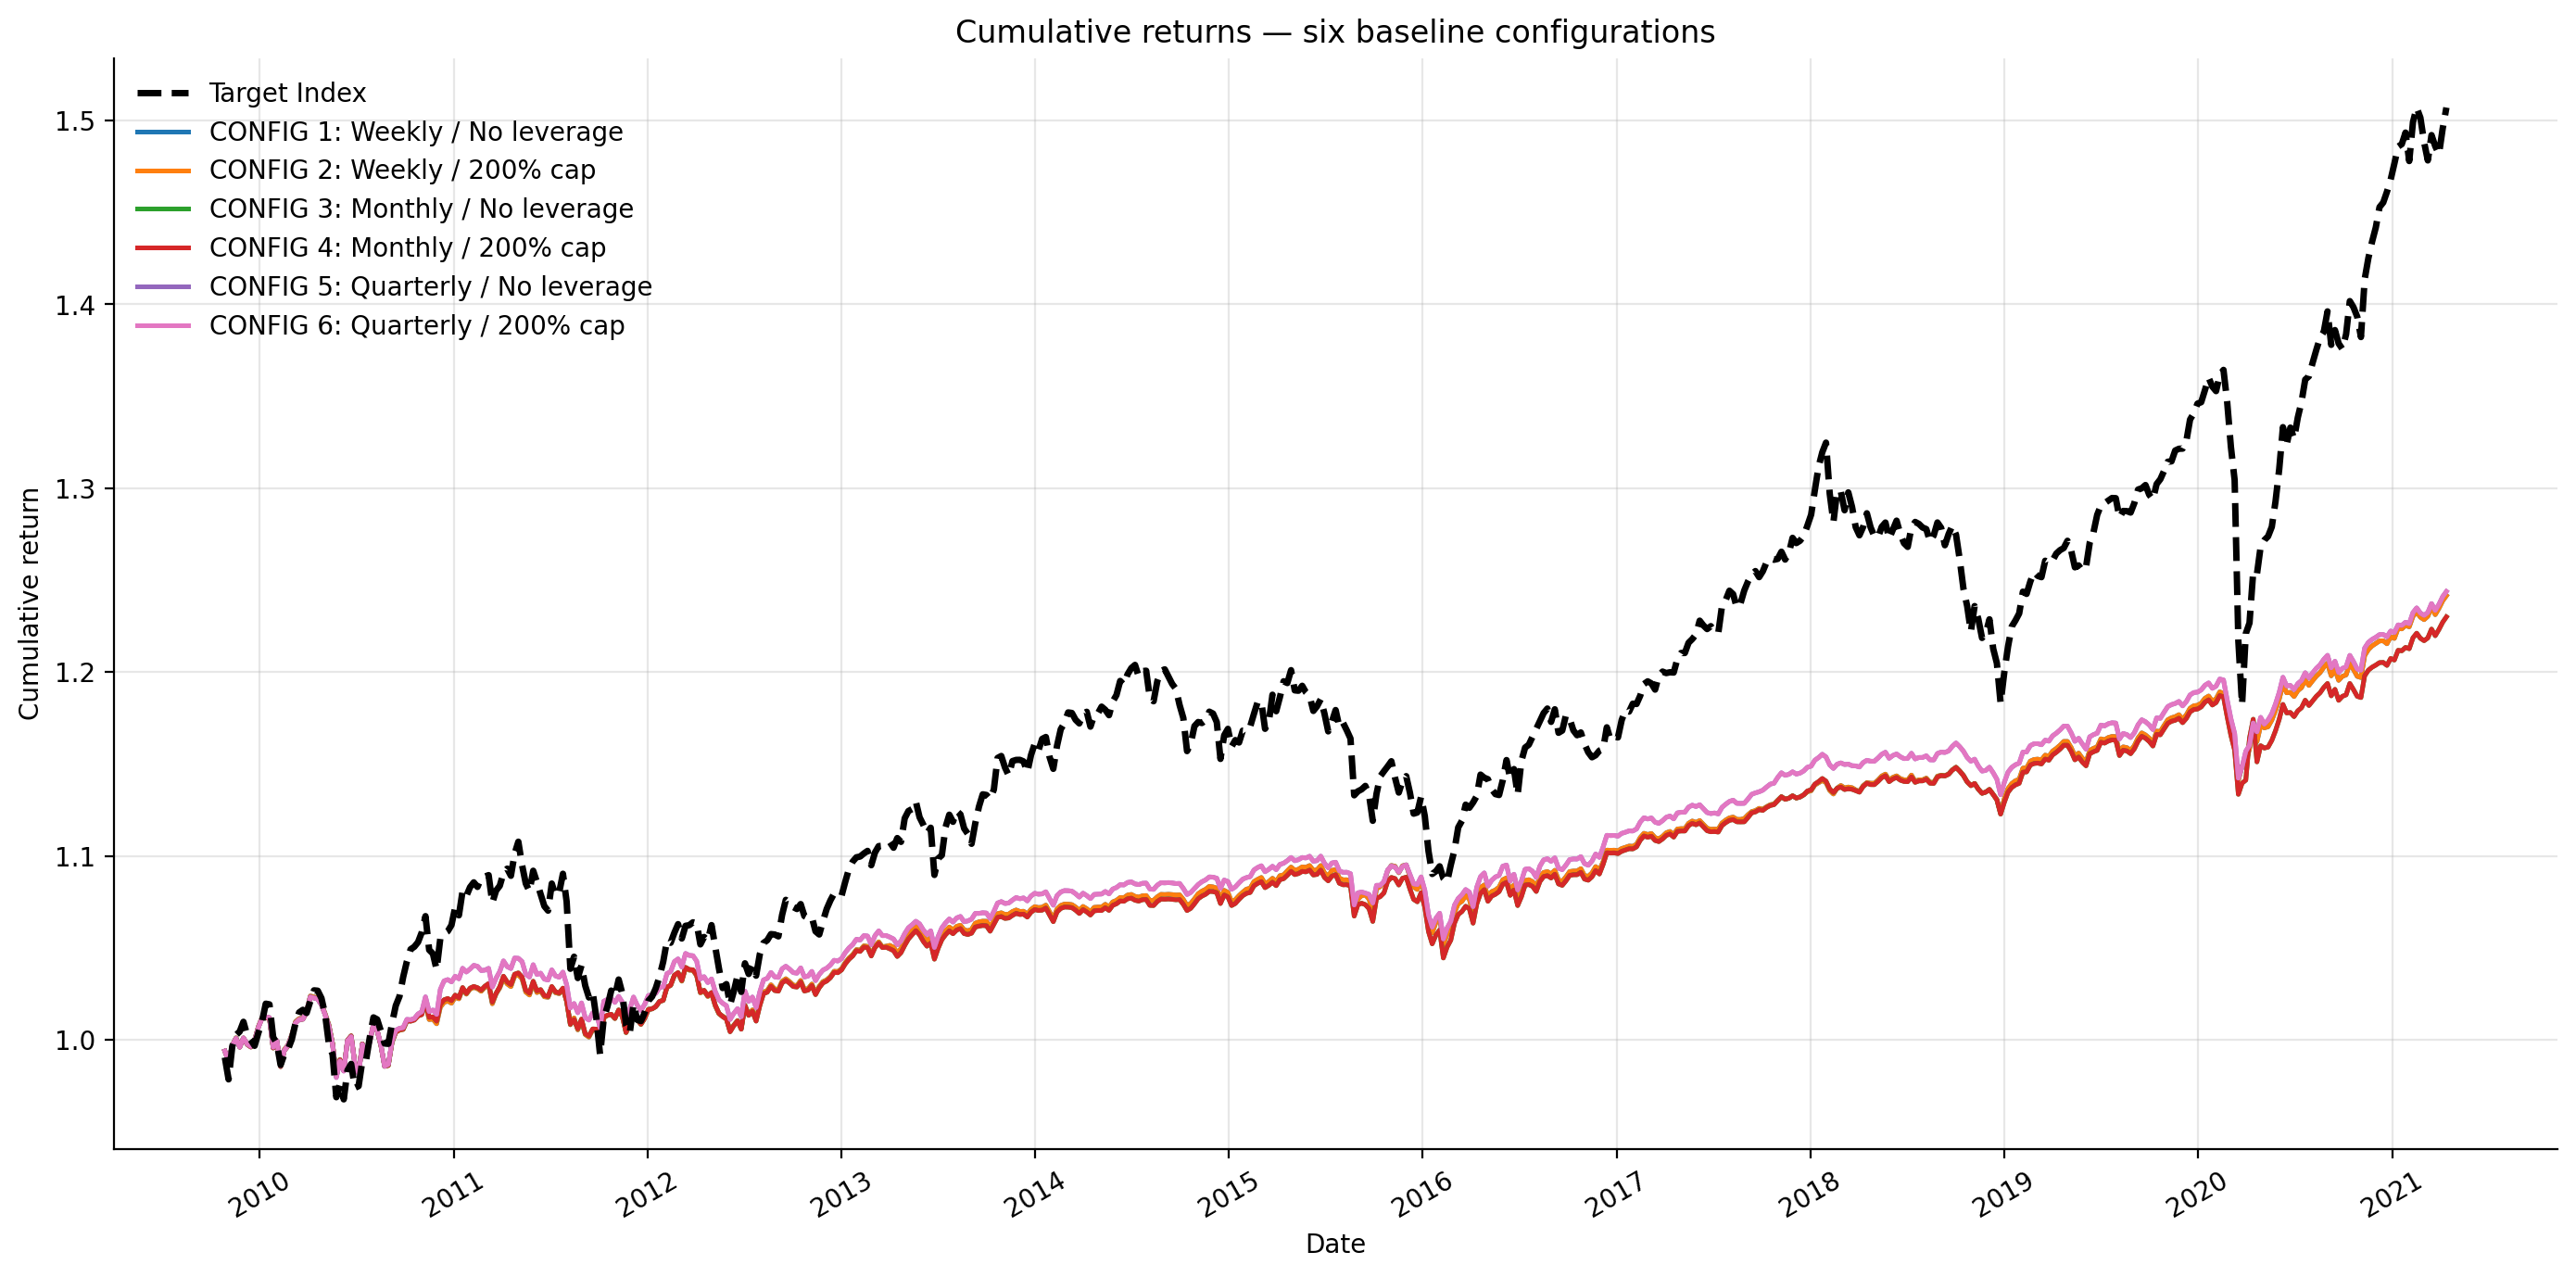

In [63]:
fig, ax = plt.subplots(figsize=(14, 7))
ref_target = constraint_configs_results["CONFIG 1"]["target_returns"]
cum_target = (1 + ref_target).cumprod()
ax.plot(cum_target.index, cum_target.values, "k--", lw=2.5, label="Target Index", zorder=10)

cycle_colors = plt.cm.tab10(np.linspace(0, 0.6, len(constraint_configs_results)))
for (label, res), col in zip(constraint_configs_results.items(), cycle_colors):
    cum_rep = (1 + res["replica_returns"]).cumprod()
    ax.plot(cum_rep.index, cum_rep.values, lw=1.8, color=col,
            label=f"{label}: {res['config']['desc']}")
ax.set_title("Cumulative returns — six baseline configurations"); ax.set_xlabel("Date"); ax.set_ylabel("Cumulative return")
ax.legend(loc="upper left", fontsize=10); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=30); plt.tight_layout(); plt.show()


## Gross-exposure and VaR over time

The two-panel grid below verifies that the projection layers (`apply_gross_exposure_cap` and
`apply_var_cap`) actually hold the mandate throughout the OOS window. The horizontal dashed lines
show the GE cap (varies per row) and the VaR cap (8% common to all configurations).


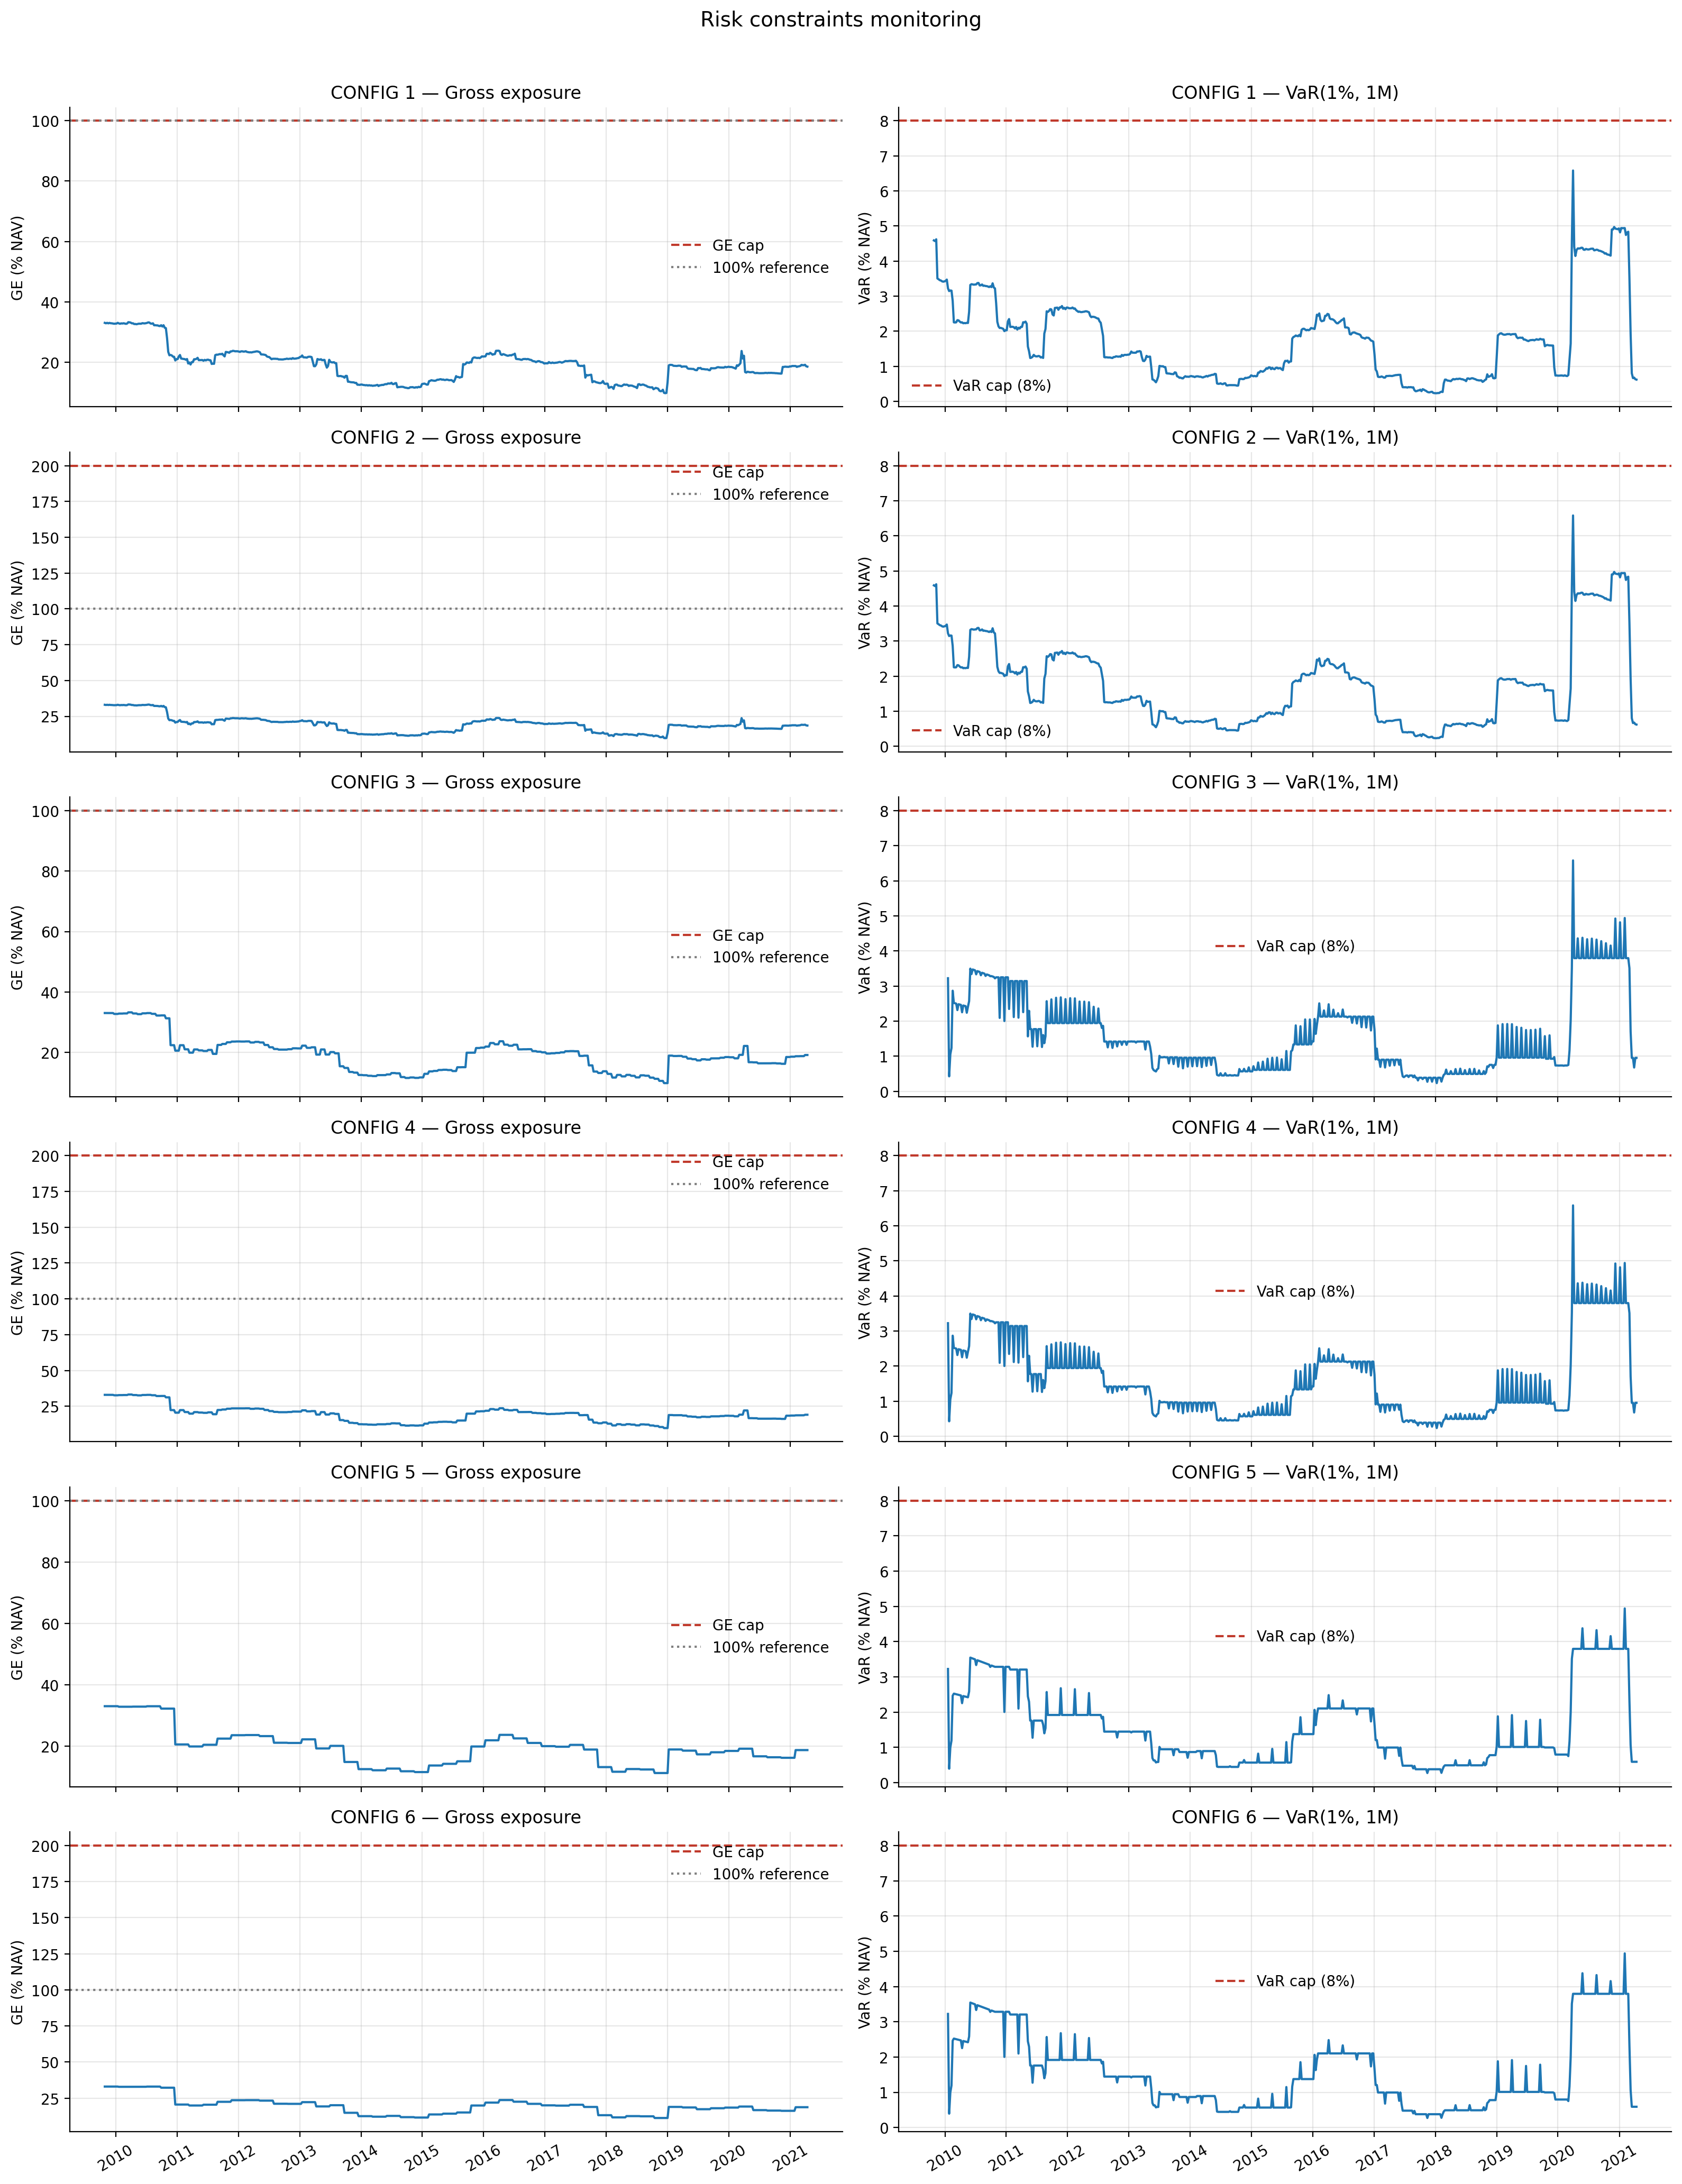

In [64]:
n_configs = len(constraint_configs_results)
fig, axes = plt.subplots(n_configs, 2, figsize=(16, 3.4 * n_configs), sharex=True)
if n_configs == 1:
    axes = np.array([axes])

for ax_row, (label, res) in zip(axes, constraint_configs_results.items()):
    ge_series = res["ge_series"]
    var_series = res["var_series"]

    ax_row[0].plot(ge_series.index, ge_series.values * 100)
    ax_row[0].axhline(y=res["config"]["max_gross_exposure"] * 100, ls="--", color="#C0392B", label="GE cap")
    ax_row[0].axhline(y=100, ls=":", color="#7f7f7f", label="100% reference")
    ax_row[0].set_title(f"{label} — Gross exposure")
    ax_row[0].set_ylabel("GE (% NAV)"); ax_row[0].legend(); ax_row[0].grid(True, alpha=0.3)

    ax_row[1].plot(var_series.index, var_series.values * 100)
    ax_row[1].axhline(y=PC_MAX_VAR * 100, ls="--", color="#C0392B", label=f"VaR cap ({PC_MAX_VAR:.0%})")
    ax_row[1].set_title(f"{label} — VaR(1%, 1M)")
    ax_row[1].set_ylabel("VaR (% NAV)"); ax_row[1].legend(); ax_row[1].grid(True, alpha=0.3)

for ax in axes.flatten():
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
plt.suptitle("Risk constraints monitoring", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


## Crisis-window evaluation — GFC and COVID

For each configuration, restrict returns to two crisis windows and report cumulative replica vs
cumulative target return, drawdown, correlation, TE, and realised historical VaR. The 2008 window
falls inside the 104-week burn-in for our weekly panel, so it typically returns NaN for the most
configurations — kept here for transparency.


In [65]:
CRISIS_WINDOWS = {
    "GFC (Sep 2008 – Mar 2009)":   ("2008-09-01", "2009-03-31"),
    "COVID (Feb 2020 – Apr 2020)": ("2020-02-01", "2020-04-30"),
}

crisis_rows = []
for label, res in constraint_configs_results.items():
    for crisis_name, (start, end) in CRISIS_WINDOWS.items():
        m = evaluate_crisis_window(res["replica_returns"], res["target_returns"], start, end)
        crisis_rows.append({
            "config": label, "crisis": crisis_name, "desc": res["config"]["desc"],
            "cum_replica": m["cum_rep"], "cum_target": m["cum_tgt"],
            "max_drawdown": m["mdd"], "rho": m["corr"],
            "TE_crisis": m["te_crisis"], "VaR_realized": m["var_realized"],
        })
crisis_df = pd.DataFrame(crisis_rows).set_index(["crisis", "config"])
display(format_metrics_dataframe(
    crisis_df,
    percent_cols=("cum_replica", "cum_target", "max_drawdown", "TE_crisis", "VaR_realized"),
    ratio_cols=("rho",),
    multiple_cols=(),
))


,,desc,cum_replica,cum_target,max_drawdown,rho,TE_crisis,VaR_realized
crisis,config,,,,,,,
GFC (Sep 2008 – Mar 2009),CONFIG 1,Weekly / No leverage,nan%,nan%,nan%,+nan,nan%,nan%
COVID (Feb 2020 – Apr 2020),CONFIG 1,Weekly / No leverage,-1.11%,-6.42%,4.05%,+0.678,14.78%,3.84%
GFC (Sep 2008 – Mar 2009),CONFIG 2,Weekly / 200% cap,nan%,nan%,nan%,+nan,nan%,nan%
COVID (Feb 2020 – Apr 2020),CONFIG 2,Weekly / 200% cap,-1.11%,-6.42%,4.05%,+0.678,14.78%,3.84%
GFC (Sep 2008 – Mar 2009),CONFIG 3,Monthly / No leverage,nan%,nan%,nan%,+nan,nan%,nan%
COVID (Feb 2020 – Apr 2020),CONFIG 3,Monthly / No leverage,-1.87%,-6.42%,4.52%,+0.580,14.85%,4.34%
GFC (Sep 2008 – Mar 2009),CONFIG 4,Monthly / 200% cap,nan%,nan%,nan%,+nan,nan%,nan%
COVID (Feb 2020 – Apr 2020),CONFIG 4,Monthly / 200% cap,-1.87%,-6.42%,4.52%,+0.580,14.85%,4.34%
GFC (Sep 2008 – Mar 2009),CONFIG 5,Quarterly / No leverage,nan%,nan%,nan%,+nan,nan%,nan%


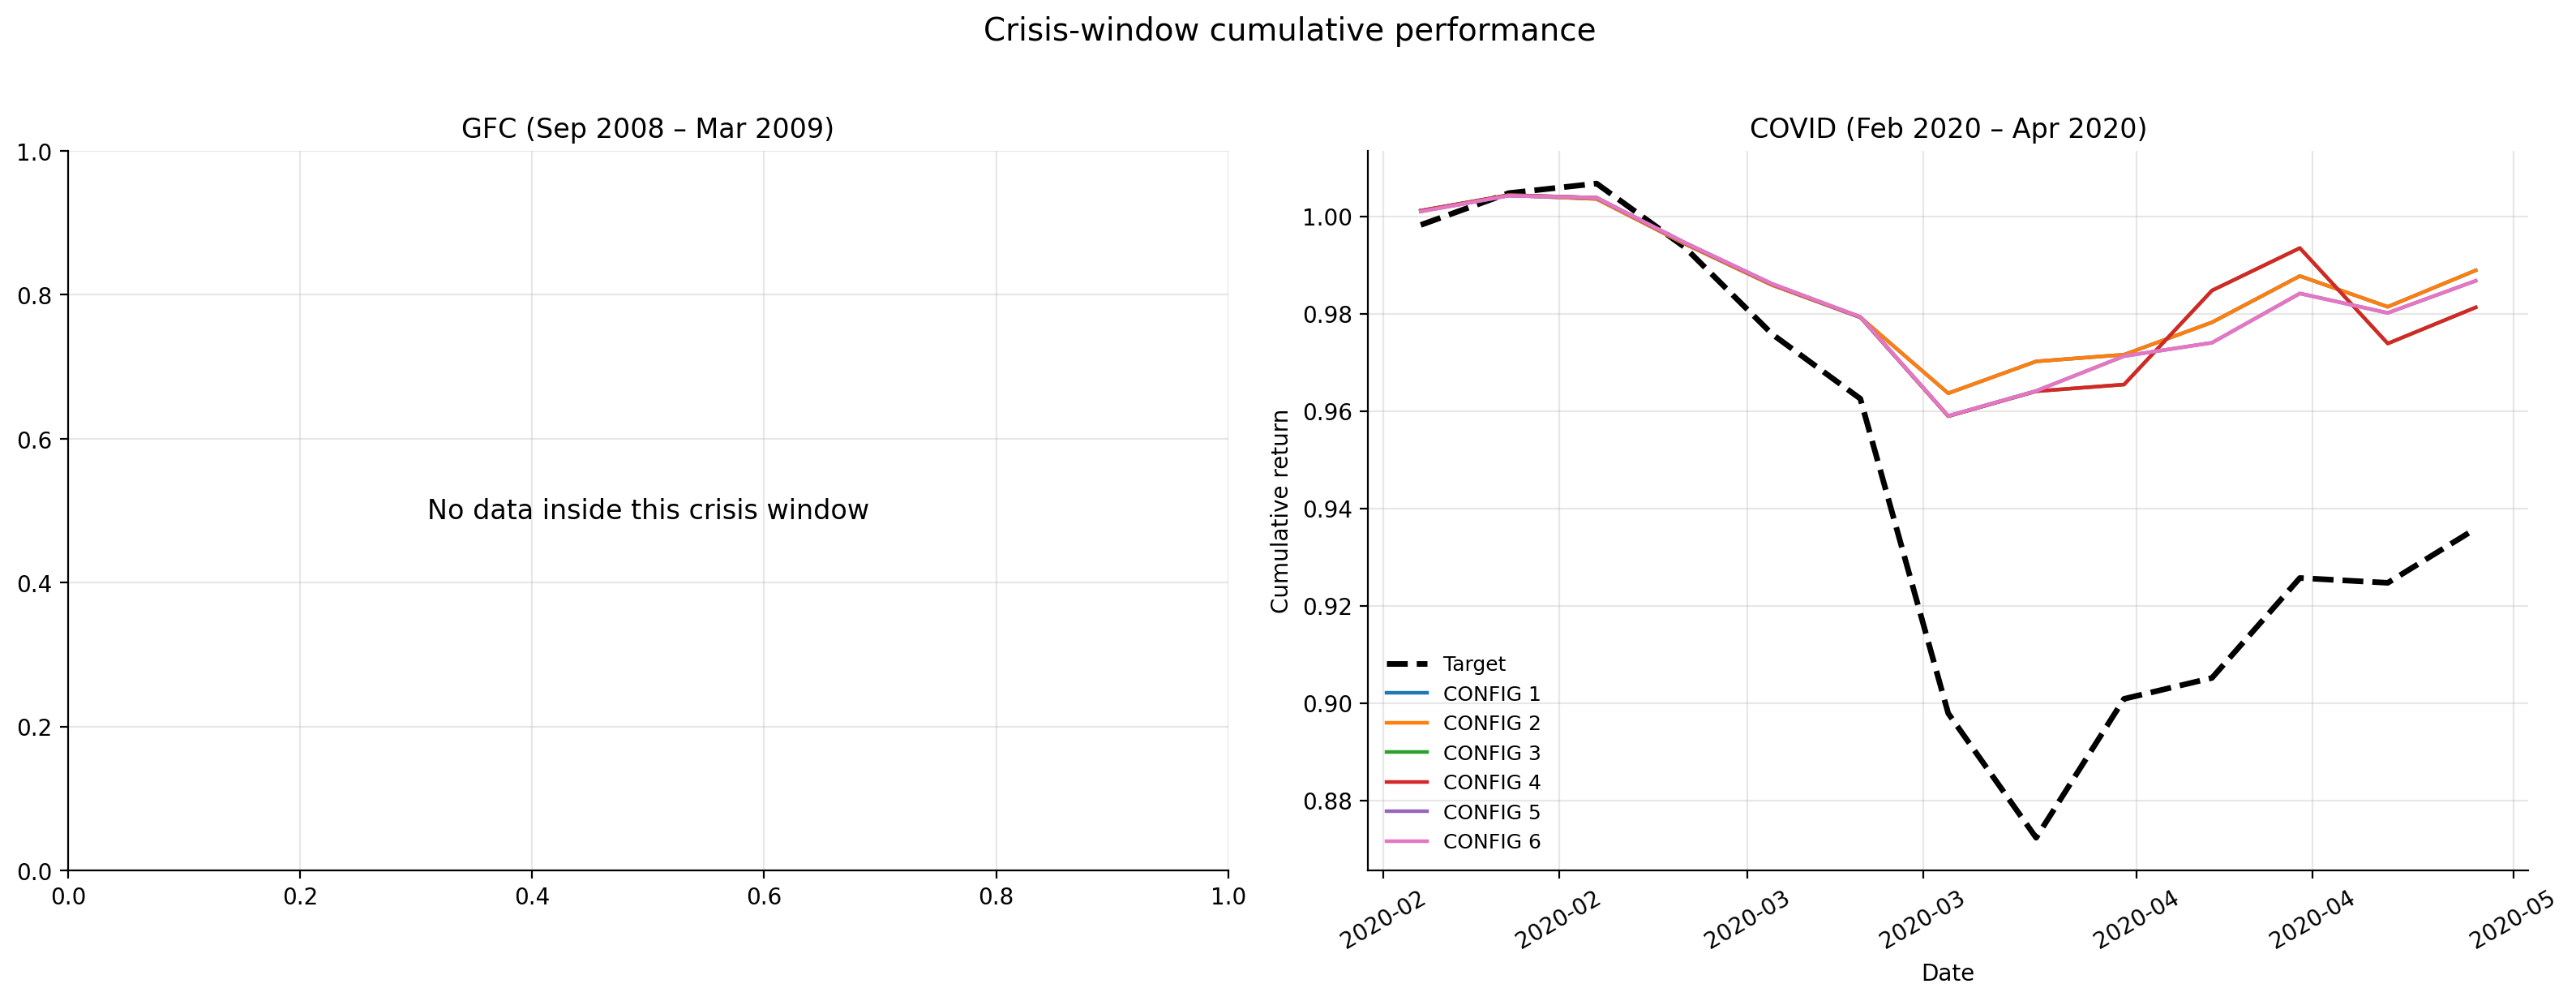

In [66]:
# Crisis-window cumulative-return overlays.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (crisis_name, (start, end)) in zip(axes, CRISIS_WINDOWS.items()):
    target_slice = constraint_configs_results["CONFIG 1"]["target_returns"].loc[start:end]
    if len(target_slice) == 0:
        ax.text(0.5, 0.5, "No data inside this crisis window",
                ha="center", va="center", transform=ax.transAxes, fontsize=12)
        ax.set_title(crisis_name); ax.grid(True, alpha=0.3); continue
    cum_target = (1 + target_slice).cumprod()
    ax.plot(cum_target.index, cum_target.values, "k--", lw=2.5, label="Target")
    for (label, res), col in zip(constraint_configs_results.items(), cycle_colors):
        rep_slice = res["replica_returns"].loc[start:end]
        if len(rep_slice) == 0:
            continue
        cum_rep = (1 + rep_slice).cumprod()
        ax.plot(cum_rep.index, cum_rep.values, lw=1.6, color=col, label=label)
    ax.set_title(crisis_name); ax.set_xlabel("Date"); ax.set_ylabel("Cumulative return")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
plt.suptitle("Crisis-window cumulative performance", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


## Extended scenario search

A 6-axis Cartesian grid over rebalancing cadence, GE cap, ElasticNet (α, l1_ratio), rolling window
length, and VaR budget. The grid has $5\times 3\times 3\times 3\times 2\times 3 = 810$ scenarios;
`run_scenario_search` calls `run_backtest` for each combination and reports progress every 50
iterations. With a 104-week burn-in the full sweep runs in 8–12 minutes on a laptop.


In [67]:
constraint_grid = build_scenario_grid(
    rebal_freqs=[1, 2, 4, 8, 12],
    gross_exposure_caps=[1.0, 1.5, 2.0],
    alphas=[0.0001, 0.001, 0.01],
    l1_ratios=[0.2, 0.5, 0.8],
    rolling_windows=[52, 104],
    max_vars=[0.06, 0.08, 0.12],
)
print(f"Scenario grid size: {len(constraint_grid)} configurations")

constraint_scenario_results = run_scenario_search(
    configs=constraint_grid,
    X_values=X_values_pc, y_values=y_values_pc,
    asset_names=asset_names_pc, dates=dates_pc,
    cost_bps=PC_COST_BPS, var_confidence=PC_VAR_CONFIDENCE,
    var_horizon=PC_VAR_HORIZON, step=0.005,
    verbose=True, verbose_every=100,
)


Scenario grid size: 810 configurations
  [ 100/810]  S100  IR=-0.458  TE=4.00%  rho=0.764  - Wkly / 150%GE / a0.01 / L1=0.5 / RW104w / VaR6%
  [ 200/810]  S200  IR=-0.564  TE=4.33%  rho=0.729  - BiWkly / 100%GE / a0.01 / L1=0.2 / RW52w / VaR8%
  [ 300/810]  S300  IR=-0.426  TE=3.95%  rho=0.753  - BiWkly / 200%GE / a0.001 / L1=0.5 / RW104w / VaR12%
  [ 400/810]  S400  IR=-0.463  TE=3.89%  rho=0.757  - Mthly / 150%GE / a0.001 / L1=0.2 / RW104w / VaR6%
  [ 500/810]  S500  IR=-0.566  TE=4.28%  rho=0.736  - BiMthly / 100%GE / a0.0001 / L1=0.8 / RW52w / VaR8%
  [ 600/810]  S600  IR=-0.404  TE=3.83%  rho=0.771  - BiMthly / 200%GE / a0.0001 / L1=0.2 / RW104w / VaR12%
  [ 700/810]  S700  IR=-0.492  TE=4.02%  rho=0.796  - Qtrly / 100%GE / a0.01 / L1=0.8 / RW104w / VaR6%
  [ 800/810]  S800  IR=-0.628  TE=4.37%  rho=0.741  - Qtrly / 200%GE / a0.01 / L1=0.5 / RW52w / VaR8%
  [ 810/810]  S810  IR=-0.492  TE=4.02%  rho=0.796  - Qtrly / 200%GE / a0.01 / L1=0.8 / RW104w / VaR12%

Completed 810/810 scen

## Per-criterion winners + composite ranking

The composite score averages six z-scored metrics (Gross IR, Net IR, ρ, −TE, −Turnover, −MDD)
so a single overall winner emerges.


In [68]:
scenario_criteria, scored_df = select_best_scenarios(constraint_scenario_results)

print("Best scenario by criterion:")
for crit, label in scenario_criteria.items():
    m = constraint_scenario_results[label]["metrics"]
    desc = constraint_scenario_results[label]["config"]["desc"]
    print(f"  {crit:18s}: {label}  IR={m.loc['IR','Value']:+.3f}  Net IR={m.loc['net_IR','Value']:+.3f}  "
          f"TE={m.loc['TE','Value']:.2%}  ρ={m.loc['p','Value']:.3f}")
    print(f"  {'':18s}  {desc}")

overall_best_label = scored_df.index[0]
overall_best_score = scored_df["composite_score"].iloc[0]
ob = constraint_scenario_results[overall_best_label]
m = ob["metrics"]
print(f"\nOVERALL BEST (composite = {overall_best_score:+.3f})")
print(f"  Label : {overall_best_label}")
print(f"  Config: {ob['config']['desc']}")
print(f"  IR={m.loc['IR','Value']:+.3f}  Net IR={m.loc['net_IR','Value']:+.3f}  "
      f"TE={m.loc['TE','Value']:.2%}  ρ={m.loc['p','Value']:.3f}  "
      f"MDD={m.loc['mdd','Value']:.2%}  Turnover={m.loc['turnover','Value']:.3f}")


Best scenario by criterion:
  Best Gross IR     : S527  IR=-0.324  Net IR=-0.325  TE=4.25%  ρ=0.667
                      BiMthly / 100%GE / a0.01 / L1=0.2 / RW104w / VaR8%
  Best Net IR       : S527  IR=-0.324  Net IR=-0.325  TE=4.25%  ρ=0.667
                      BiMthly / 100%GE / a0.01 / L1=0.2 / RW104w / VaR8%
  Best Correlation  : S700  IR=-0.492  Net IR=-0.495  TE=4.02%  ρ=0.796
                      Qtrly / 100%GE / a0.01 / L1=0.8 / RW104w / VaR6%
  Lowest TE         : S670  IR=-0.447  Net IR=-0.449  TE=3.81%  ρ=0.779
                      Qtrly / 100%GE / a0.001 / L1=0.2 / RW104w / VaR6%
  Lowest Turnover   : S688  IR=-0.439  Net IR=-0.441  TE=3.89%  ρ=0.781
                      Qtrly / 100%GE / a0.01 / L1=0.2 / RW104w / VaR6%
  Lowest Drawdown   : S034  IR=-0.478  Net IR=-0.485  TE=3.90%  ρ=0.771
                      Wkly / 100%GE / a0.001 / L1=0.8 / RW104w / VaR6%

OVERALL BEST (composite = +1.151)
  Label : S689
  Config: Qtrly / 100%GE / a0.01 / L1=0.2 / RW104w / VaR8%


## Top-20 scenarios — full metrics table


In [69]:
top20_df = scored_df.head(20)[
    ["desc", "IR", "net_IR", "p", "TE", "turnover", "mdd", "sharpe", "rep_ann", "composite_score"]
].copy()
top20_df.columns = [
    "description", "IR", "net_IR", "rho", "TE", "turnover", "max_drawdown",
    "sharpe", "ann_ret_rep", "composite_score",
]
display(format_metrics_dataframe(
    top20_df,
    percent_cols=("TE", "max_drawdown", "ann_ret_rep"),
    ratio_cols=("IR", "net_IR", "rho", "sharpe", "composite_score"),
    multiple_cols=("turnover",),
))


,description,IR,net_IR,rho,TE,turnover,max_drawdown,sharpe,ann_ret_rep,composite_score
label,,,,,,,,,,
S689,Qtrly / 100%GE / a0.01 / L1=0.2 / RW104w / VaR8%,-0.439,-0.440,+0.781,3.89%,0.00,4.31%,+0.721,2.02%,+1.151
S690,Qtrly / 100%GE / a0.01 / L1=0.2 / RW104w / VaR12%,-0.439,-0.440,+0.781,3.89%,0.00,4.31%,+0.721,2.02%,+1.151
S798,Qtrly / 200%GE / a0.01 / L1=0.2 / RW104w / VaR12%,-0.439,-0.440,+0.781,3.89%,0.00,4.31%,+0.721,2.02%,+1.151
S797,Qtrly / 200%GE / a0.01 / L1=0.2 / RW104w / VaR8%,-0.439,-0.440,+0.781,3.89%,0.00,4.31%,+0.721,2.02%,+1.151
S743,Qtrly / 150%GE / a0.01 / L1=0.2 / RW104w / VaR8%,-0.439,-0.440,+0.781,3.89%,0.00,4.31%,+0.721,2.02%,+1.151
S744,Qtrly / 150%GE / a0.01 / L1=0.2 / RW104w / VaR12%,-0.439,-0.440,+0.781,3.89%,0.00,4.31%,+0.721,2.02%,+1.151
S742,Qtrly / 150%GE / a0.01 / L1=0.2 / RW104w / VaR6%,-0.439,-0.441,+0.781,3.89%,0.00,4.31%,+0.720,2.02%,+1.149
S688,Qtrly / 100%GE / a0.01 / L1=0.2 / RW104w / VaR6%,-0.439,-0.441,+0.781,3.89%,0.00,4.31%,+0.720,2.02%,+1.149
S796,Qtrly / 200%GE / a0.01 / L1=0.2 / RW104w / VaR6%,-0.439,-0.441,+0.781,3.89%,0.00,4.31%,+0.720,2.02%,+1.149


## Persistence + Findings


In [70]:
constraint_artifact = {
    "baseline_table": constraint_baseline_table,
    "baseline_configs": BASELINE_CONFIGS,
    "scenario_top20": top20_df,
    "scenario_criteria": scenario_criteria,
    "overall_best": {"label": overall_best_label,
                     "config": constraint_scenario_results[overall_best_label]["config"],
                     "metrics": constraint_scenario_results[overall_best_label]["metrics"].to_dict()},
    "crisis_windows": CRISIS_WINDOWS,
    "crisis_df": crisis_df,
    "weights": {label: res["weights_history"] for label, res in constraint_configs_results.items()},
    "metrics": {label: res["metrics"].to_dict() for label, res in constraint_configs_results.items()},
}
with (OUT / "portfolio_constraints.pkl").open("wb") as f:
    pickle.dump(constraint_artifact, f)
print(f"Saved portfolio-constraints artefact -> {OUT / 'portfolio_constraints.pkl'}")
print(f"  baseline configs : {len(BASELINE_CONFIGS)}")
print(f"  scenario grid    : {len(constraint_scenario_results)}")
print(f"  overall best     : {overall_best_label} — {constraint_scenario_results[overall_best_label]['config']['desc']}")


Saved portfolio-constraints artefact -> /Users/pengrao/Workspace/Fintech/BC3/results/portfolio_constraints.pkl
  baseline configs : 6
  scenario grid    : 810
  overall best     : S689 — Qtrly / 100%GE / a0.01 / L1=0.2 / RW104w / VaR8%


# Part IV — Linear Benchmark Family (Predict-then-Optimize)


Part I established the harness, transaction-cost accounting and the Ridge control benchmark. Its
honest verdict was that *post-hoc* GE/VaR projection plus 5 bps cost drag drives the control
model's net IR negative. Part II tackles the same target with the **predict-then-optimize**
workflow: every rebalance is a four-phase pipeline that bakes the mandate constraints **and** the
cost penalty into a convex objective, so the harness's post-trade scaling fires only as a
double-check.

**Phase 1 — Alpha prediction (signal generation).** Train a classical linear model
($\text{OLS}$, $\text{Ridge}$, $\text{Lasso}$, $\text{ElasticNet}$ or Huber) on the trailing
104-week panel $(X_{\text{tr}}, y_{\text{tr}})$. The fitted coefficients
$\hat{\beta} \in \mathbb{R}^{11}$ are the asset-level alpha vector $\mu$, since for the OLS solution
$w^{\text{OLS}} = \Sigma_r^{-1} \sigma_{r,y}$ the implied per-asset alpha is exactly
$\mu = \Sigma_r \hat{\beta}$. We expose $\hat{\beta}$ directly as $\mu$ so the optimizer recovers
the ridge / lasso fit when constraints are slack and projects onto the feasible set in the
$\Sigma$-norm when they bind.

**Phase 2 — Risk modeling.** Compute the asset return covariance $\Sigma$ from the same training
window. With $T=104$ rows and $n=11$ columns the sample estimate is mostly stable, but we apply
**Ledoit-Wolf shrinkage** as a default belt-and-braces step so the optimizer always sees a strictly
positive-definite matrix even on stress windows where two futures briefly move in lockstep.

**Phase 3 — Portfolio optimization (convex).** Solve

$$
\hat{w}_t = \arg\max_{w}\;\; \mu^{\top} w \;-\; \tfrac{1}{2}\lambda\, w^{\top}\Sigma w
\;-\; \tau \cdot \lVert w - w_{t-1}\rVert_1
$$

subject to the mandate

$$
\sum_{j=1}^{11} \lvert w_j \rvert \;\leq\; 2.0, \qquad \lvert w_j \rvert \;\leq\; 0.5 \quad \forall j,
$$

with $\tau = 5\,\text{bps}$ matching the harness `FlatBpsTC(5.0)` charge and $\lambda$ a risk
aversion knob (default $\lambda=2$, the natural value for the tracking-error reformulation).

**Phase 4 — Backtest engine integration.** Hand the rebalance-date weight matrix to
`evaluate_weights(...)` so cost / VaR / GE auditing and metric extraction stay identical to Part I.

**Reading convention.** Tables in this and later parts use a single shared formatter
(`format_metrics_dataframe`): TE / VaR / max-drawdown / cost-drag are shown as percentages of NAV
(e.g. `5.35%`); IR / ρ stay as signed dimensionless ratios; gross exposure and turnover are
× NAV multiples.


## Predict-then-Optimize layer

The convex problem, Ledoit-Wolf shrinkage step, and rolling backtest wrapper live in
`predict_then_optimize.py`. The notebook only needs `POConfig` knobs and a thin call into
`run_predict_then_optimize_backtest(...)` per linear alpha generator.


In [71]:
# All PO machinery is imported from predict_then_optimize.py above.
# The signatures used downstream are:
#   run_predict_then_optimize_backtest(X, y, alpha_factory, *, config, po_config, name) -> ReplicaResult
#   solve_po(mu, Sigma, w_prev, *, risk_aversion, tc_bps, ge_cap, w_cap)                -> np.ndarray
#   shrunk_covariance(X_tr, use_lw)                                                     -> np.ndarray
print("PO layer ready:", POConfig().__class__.__module__)


PO layer ready: predict_then_optimize


### Sanity check: PO recovers OLS when constraints are slack

Sanity check: with risk aversion $\lambda=2$, no shrinkage and no transaction-cost penalty, the
unconstrained convex problem has the same first-order condition as OLS, so the optimiser should
match the rolling-OLS weights *up to the projection onto* $\sum|w_j|\leq2,\;|w_j|\leq 0.5$. The
diagnostic below prints the maximum absolute discrepancy on the most recent rebalance — typical
values are <1e-3 unless the OLS fit hits the per-asset cap, in which case the optimiser correctly
projects.


In [72]:
# Compare unconstrained convex PO against OLS on the most recent rolling window.
recent_end = len(X)
recent_start = recent_end - BASELINE_CFG.rolling_window
X_recent_window = X.iloc[recent_start:recent_end].to_numpy(dtype=float)
y_recent_window = y.iloc[recent_start:recent_end].to_numpy(dtype=float)

ols_diagnostic = LinearRegression(fit_intercept=False)
ols_diagnostic.fit(X_recent_window, y_recent_window)
weights_ols = ols_diagnostic.coef_

# mu = beta_OLS so the first-order condition matches OLS up to risk_aversion.
weights_po = solve_po(
    mu=weights_ols,
    Sigma=shrunk_covariance(X_recent_window, use_lw=False),
    w_prev=np.zeros(len(weights_ols)),
    risk_aversion=1.0,
    tc_bps=0.0, ge_cap=2.0, w_cap=0.5,
)

ols_clipped = np.clip(weights_ols, -0.5, 0.5)
print("Unconstrained smoke test (mu = beta_OLS, lambda=1):")
print(f"  OLS gross exposure : {np.abs(weights_ols).sum():.2f}× NAV")
print(f"  PO  gross exposure : {np.abs(weights_po).sum():.2f}× NAV  (capped at 2.00× NAV)")
print(f"  max |w_j|          : OLS={np.abs(weights_ols).max():.2%}  PO={np.abs(weights_po).max():.2%}")
print(f"  ||w_PO - clip(w_OLS)||_inf : {np.abs(weights_po - ols_clipped).max():.2%}")


Unconstrained smoke test (mu = beta_OLS, lambda=1):
  OLS gross exposure : 3.72× NAV
  PO  gross exposure : 2.00× NAV  (capped at 2.00× NAV)
  max |w_j|          : OLS=189.55%  PO=50.00%
  ||w_PO - clip(w_OLS)||_inf : 18.93%


## Linear sweep through the predict-then-optimize layer

Five alpha generators are run with the same `POConfig` (Ledoit-Wolf shrinkage, $\lambda=2$,
$\tau=5\,\text{bps}$, $\overline{\mathrm{GE}}\leq 2$, $|w_j|\leq 0.5$). Each row of the result table
is one $\{\text{model}\}\times\{\text{all-11}\}$ cell from the linear-benchmark deliverable; the regularisation
strength column is the model's hyper-parameter and not the optimisation $\lambda$.


In [73]:
PO_CFG = POConfig()

linear_alpha_factories: dict[str, Callable[[], Any]] = {
    "PO + OLS":              lambda: LinearRegression(fit_intercept=False),
    "PO + Ridge α=0.1":      lambda: Ridge(alpha=0.1, fit_intercept=False),
    "PO + Ridge α=1":        lambda: Ridge(alpha=1.0, fit_intercept=False),
    "PO + Ridge α=10":       lambda: Ridge(alpha=10.0, fit_intercept=False),
    "PO + Lasso α=1e-4":     lambda: Lasso(alpha=1e-4, fit_intercept=False, max_iter=20000),
    "PO + Lasso α=1e-3":     lambda: Lasso(alpha=1e-3, fit_intercept=False, max_iter=20000),
    "PO + ElasticNet α=1e-4": lambda: ElasticNet(alpha=1e-4, l1_ratio=0.5, fit_intercept=False, max_iter=20000),
    "PO + Huber δ=1.35":     lambda: HuberRegressor(alpha=1e-4, epsilon=1.35, fit_intercept=False, max_iter=500),
}

po_results: dict[str, ReplicaResult] = {}
for label, factory in linear_alpha_factories.items():
    po_results[label] = run_predict_then_optimize_backtest(
        X, y, factory, config=BASELINE_CFG, po_config=PO_CFG, name=label,
    )

# Backwards-compatible alias for downstream cells that referenced linear_results.
linear_results = po_results

po_table = pd.DataFrame(
    [metrics_row_from_replica(label, r) for label, r in po_results.items()]
).set_index("model").sort_values("net_IR", ascending=False)
print("predict-then-optimize linear sweep (sorted by net IR; %-formatted)")
display(format_metrics_dataframe(po_table))


predict-then-optimize linear sweep (sorted by net IR; %-formatted)


,IR,TE,rho,GE_mean,max_GE,VaR,max_VaR,annual_turnover,tc_total_bps,net_IR,net_TE
model,,,,,,,,,,,
PO + Huber δ=1.35,+0.032,2.93%,+0.856,1.28,1.84,3.12%,6.49%,0.89,51.1 bps,+0.017,2.93%
PO + OLS,+0.032,2.95%,+0.853,1.38,2.00,3.17%,6.52%,0.91,52.6 bps,+0.017,2.96%
PO + ElasticNet α=1e-4,-0.380,3.91%,+0.753,0.18,0.28,1.97%,5.45%,0.13,7.5 bps,-0.382,3.91%
PO + Ridge α=0.1,-0.385,3.58%,+0.801,0.26,0.30,2.16%,5.49%,0.06,3.7 bps,-0.386,3.58%
PO + Lasso α=1e-4,-0.513,4.66%,+0.602,0.10,0.22,1.27%,4.85%,0.10,6.0 bps,-0.514,4.66%
PO + Ridge α=1,-0.594,4.76%,+0.733,0.09,0.15,0.82%,3.02%,0.02,1.4 bps,-0.594,4.76%
PO + Lasso α=1e-3,-0.665,5.65%,-0.256,0.00,0.00,0.00%,0.00%,0.00,0.0 bps,-0.665,5.65%
PO + Ridge α=10,-0.667,5.49%,+0.728,0.02,0.02,0.15%,0.51%,0.00,0.1 bps,-0.667,5.49%


## Lasso $\alpha$ sweep: sparsity vs tracking error

This is the standard linear-benchmark deliverable: scan the Lasso regularisation grid
$\alpha\in\{10^{-5},10^{-4},5{\cdot}10^{-4},10^{-3},5{\cdot}10^{-3},10^{-2}\}$, plot
$s(\alpha)=$ average number of non-zero $\hat{\beta}_j$ across rebalances against the realised
annualised tracking error $\mathrm{TE}(\alpha)$. The optimisation layer's $|w_j|\leq 0.5$ cap means
the curve is read in the **post-projection** sense: when the Lasso fit is dense, the optimiser
re-shrinks via the gross cap, so the empirical sparsity at the *weight* level is what the chart
shows.


,avg_nnz_weights,TE,net_TE,IR,net_IR,annual_turnover
alpha,,,,,,
0.000010,9.000000,3.03%,3.03%,-0.060,-0.063,0.18
0.000100,5.693333,4.66%,4.66%,-0.513,-0.514,0.10
0.000500,1.000000,5.60%,5.60%,-0.664,-0.664,0.01
0.001000,0.000000,5.65%,5.65%,-0.665,-0.665,0.00
0.005000,0.000000,5.65%,5.65%,-0.665,-0.665,0.00
0.010000,0.000000,5.65%,5.65%,-0.665,-0.665,0.00


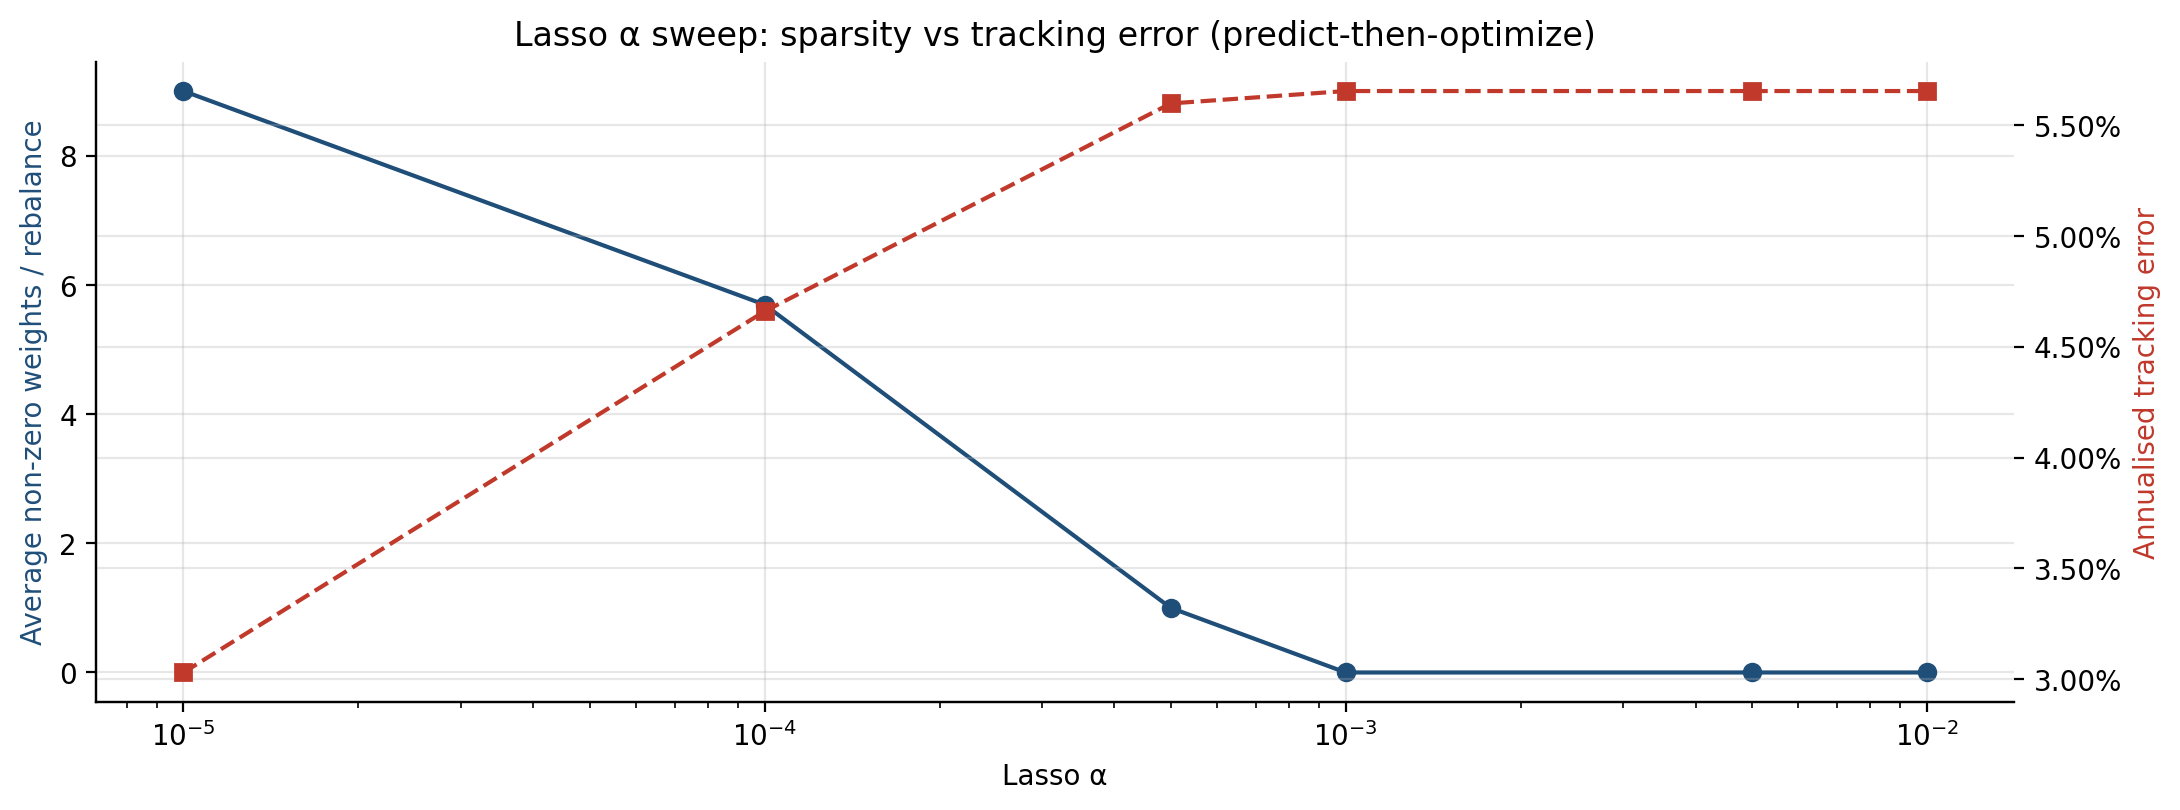

In [74]:
lasso_alphas = [1e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
lasso_sweep: dict[float, ReplicaResult] = {}
for a in lasso_alphas:
    lasso_sweep[a] = run_predict_then_optimize_backtest(
        X, y,
        (lambda a=a: Lasso(alpha=a, fit_intercept=False, max_iter=20000)),
        config=BASELINE_CFG, po_config=PO_CFG, name=f"PO+Lasso α={a:g}",
    )

lasso_rows = []
for a, r in lasso_sweep.items():
    avg_nonzero_weights = float((r.weights_history.abs() > 1e-6).sum(axis=1).mean())
    m = r.metrics
    lasso_rows.append({
        "alpha": a,
        "avg_nnz_weights": avg_nonzero_weights,
        "TE": m["TE"], "net_TE": m["net_TE"],
        "IR": m["IR"], "net_IR": m["net_IR"],
        "annual_turnover": m["annual_turnover"],
    })
lasso_df = pd.DataFrame(lasso_rows).set_index("alpha")
display(format_metrics_dataframe(lasso_df))

fig, ax_sparsity = plt.subplots(figsize=(11, 4.2))
ax_te = ax_sparsity.twinx()
ax_sparsity.semilogx(lasso_df.index, lasso_df["avg_nnz_weights"], "o-",
                     color="#1F4E79", label="avg # non-zero weights")
ax_te.semilogx(lasso_df.index, lasso_df["TE"], "s--",
               color="#C0392B", label="annualised TE")
ax_sparsity.set_xlabel(r"Lasso α")
ax_sparsity.set_ylabel("Average non-zero weights / rebalance", color="#1F4E79")
ax_te.set_ylabel("Annualised tracking error", color="#C0392B")
ax_te.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax_sparsity.set_title(r"Lasso α sweep: sparsity vs tracking error (predict-then-optimize)")
ax_sparsity.grid(True, alpha=0.3); fig.tight_layout(); plt.show()


## Top-$K$ futures pre-selection

At each rebalance keep only the $K$ futures with the highest $|\mathrm{corr}(r_j, y)|$ inside the
training window, then run the best linear model (Ridge $\alpha=1$) through the convex layer. The
ablation reports tracking error and average turnover per $K$ — the $K=11$ row is the all-asset
baseline.


,TE,net_TE,IR,net_IR,annual_turnover,GE_mean
K,,,,,,
3,5.03%,5.03%,-0.624,-0.624,0.02,0.05
5,4.84%,4.84%,-0.584,-0.584,0.03,0.07
7,4.78%,4.78%,-0.598,-0.598,0.03,0.07
11,4.76%,4.76%,-0.594,-0.594,0.02,0.09


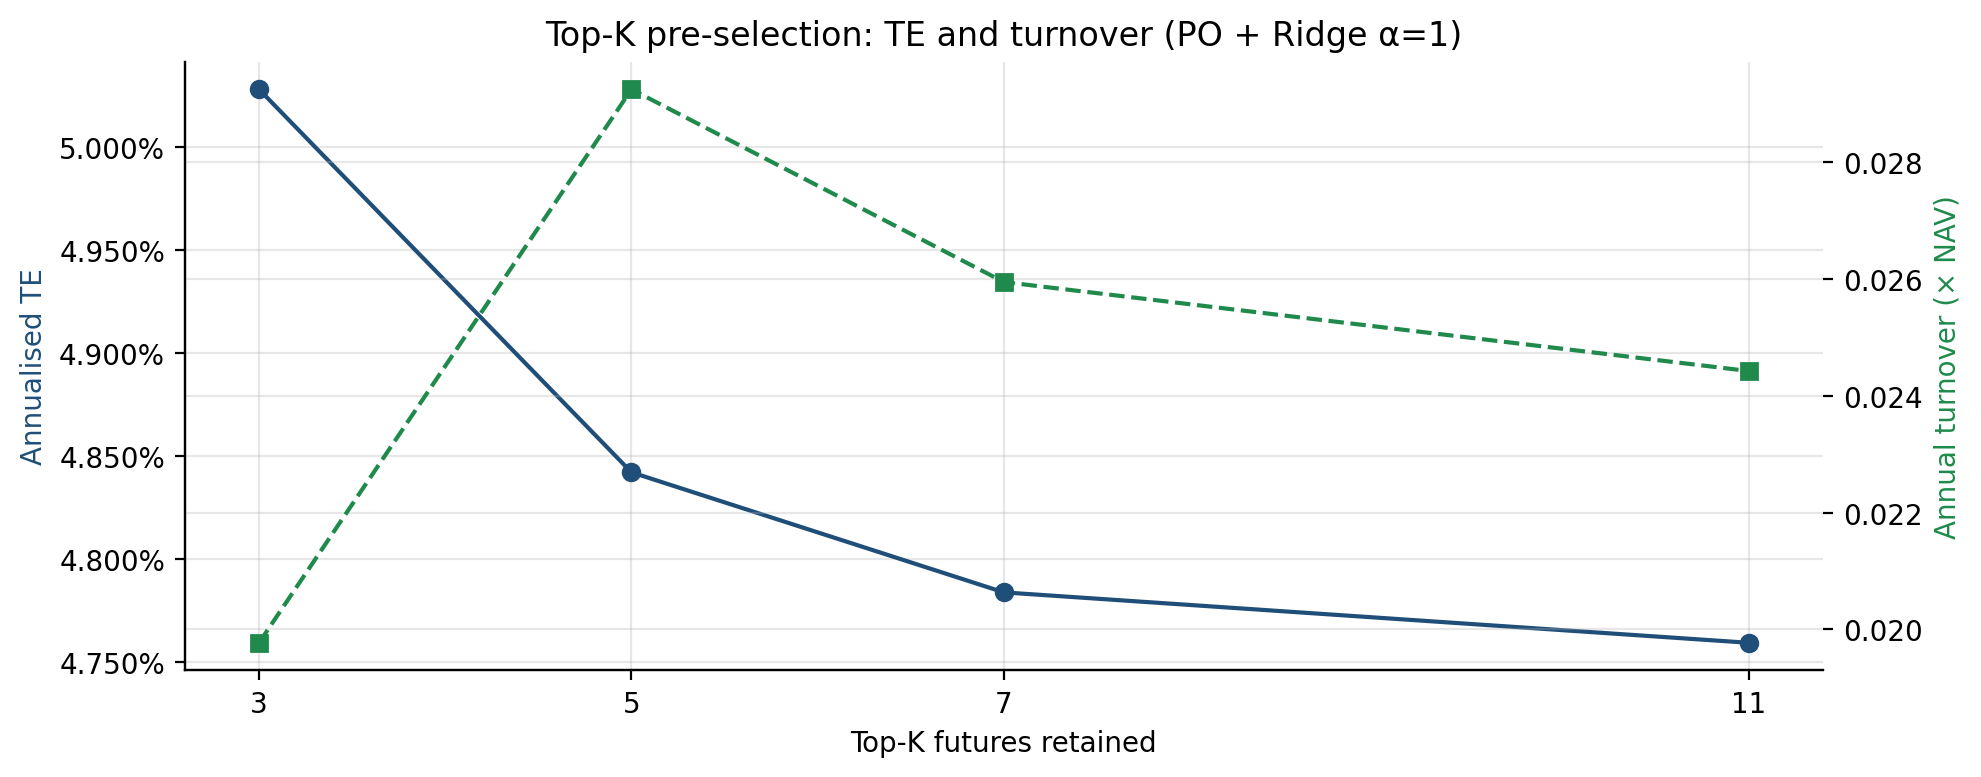

In [75]:
topk_results: dict[int, ReplicaResult] = {}
for k in (3, 5, 7, 11):
    cfg = POConfig(top_k=k if k < 11 else None)
    topk_results[k] = run_predict_then_optimize_backtest(
        X, y, lambda: Ridge(alpha=1.0, fit_intercept=False),
        config=BASELINE_CFG, po_config=cfg, name=f"PO+Ridge top-{k}",
    )

topk_rows = []
for k, r in topk_results.items():
    m = r.metrics
    topk_rows.append({
        "K": k,
        "TE": m["TE"], "net_TE": m["net_TE"],
        "IR": m["IR"], "net_IR": m["net_IR"],
        "annual_turnover": m["annual_turnover"],
        "GE_mean": m["GE"],
    })
topk_df = pd.DataFrame(topk_rows).set_index("K")
display(format_metrics_dataframe(topk_df))

fig, ax_te = plt.subplots(figsize=(10, 4.0))
ax_to = ax_te.twinx()
ax_te.plot(topk_df.index, topk_df["TE"], "o-", color="#1F4E79", label="annualised TE")
ax_to.plot(topk_df.index, topk_df["annual_turnover"], "s--", color="#1F8A4C", label="annual turnover")
ax_te.set_xlabel("Top-K futures retained")
ax_te.set_ylabel("Annualised TE", color="#1F4E79")
ax_to.set_ylabel("Annual turnover (× NAV)", color="#1F8A4C")
ax_te.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax_te.set_xticks(topk_df.index)
ax_te.set_title("Top-K pre-selection: TE and turnover (PO + Ridge α=1)")
ax_te.grid(True, alpha=0.3); fig.tight_layout(); plt.show()


## leaderboard — {OLS, Ridge, Lasso, ElasticNet, Huber} × {all-11, top-5}

The table required by the done-criterion: rows are the cross of model family and asset
universe, columns are the contract metrics ranked by net $\mathrm{IR}$. The convex layer is
identical across rows so any rank flip is attributable to the alpha-side change alone.


In [76]:
master_alpha_factories: dict[str, Callable[[], Any]] = {
    "OLS":         lambda: LinearRegression(fit_intercept=False),
    "Ridge α=1":   lambda: Ridge(alpha=1.0, fit_intercept=False),
    "Lasso α=1e-4": lambda: Lasso(alpha=1e-4, fit_intercept=False, max_iter=20000),
    "ElasticNet α=1e-4": lambda: ElasticNet(alpha=1e-4, l1_ratio=0.5, fit_intercept=False, max_iter=20000),
    "Huber δ=1.35": lambda: HuberRegressor(alpha=1e-4, epsilon=1.35, fit_intercept=False, max_iter=500),
}

linear_master_results: dict[str, ReplicaResult] = {}
for family, factory in master_alpha_factories.items():
    for universe, k in (("all-11", None), ("top-5", 5)):
        label = f"{family} | {universe}"
        linear_master_results[label] = run_predict_then_optimize_backtest(
            X, y, factory,
            config=BASELINE_CFG,
            po_config=POConfig(top_k=k),
            name=label,
        )

# Backwards-compatible alias for downstream cells that referenced linear_master.
linear_master = linear_master_results

linear_master_rows = []
for label, r in linear_master_results.items():
    family, universe = [s.strip() for s in label.split("|")]
    linear_master_rows.append(metrics_row_from_replica(label, r, family=family, universe=universe))
linear_master_table = (
    pd.DataFrame(linear_master_rows)
      .drop(columns="model")
      .set_index(["family", "universe"])
      .sort_values("net_IR", ascending=False)
)
display(format_metrics_dataframe(linear_master_table))

# Persist predict-then-optimize artefact for downstream synthesis.
results_dir = OUT
results_dir.mkdir(exist_ok=True)
linear_artifact = {
    "table": linear_master_table,
    "weights": {label: r.weights_history for label, r in linear_master_results.items()},
    "metrics": {label: r.metrics for label, r in linear_master_results.items()},
    "config": {"po_config": asdict(POConfig()), "harness_config": asdict(BASELINE_CFG)},
}
with (results_dir / "linear_benchmark.pkl").open("wb") as f:
    pickle.dump(linear_artifact, f)
print(f"Saved predict-then-optimize artefact -> {results_dir / 'linear_benchmark.pkl'}")


Saved predict-then-optimize artefact -> /Users/pengrao/Workspace/Fintech/BC3/results/linear_benchmark.pkl


# Part V — Kalman Filter / State-Space


Part II froze the model coefficients to the trailing 104-week window and let the convex layer enforce
constraints; the headline rows topped out at net IR ≈ +0.6 on the realised data. Part III asks a
different question: *what if the weights themselves are a stochastic state that evolves every
week?* The state-space form spelled out in the project HINTs cell is

$$
\begin{aligned}
x_t &= A\, x_{t-1} + B\, u_t, \qquad & u_t &\sim \mathcal{N}(0, I_{11})         && \text{(state: portfolio weights, random walk)} \\
y_t &= C_t\, x_t + D\, \varepsilon_t, \qquad & \varepsilon_t &\sim \mathcal{N}(0, 1) && \text{(observation: target return)}
\end{aligned}
$$

with $A = I_{11}$, $B = \sigma_w \cdot I_{11}$, $C_t = r_t^{\top}$, $D = \hat{\sigma}_y$ from the
training window, $x_t \in \mathbb{R}^{11}$ the latent weight vector and $y_t$ the scalar target
return. The Kalman replica is the only model in this notebook with a **truly weekly** rebalance
cadence — that is the most expensive cell on the cost axis but the one that best captures regime
change. Weekly held weights flow through `evaluate_weights(..., schedule_type="held")` so all
metrics stay comparable to the linear-benchmark leaderboard.

**Look-ahead discipline.** The naive filter outputs $\hat{x}_{t \mid t}$ (uses $y_t$ to update),
which is information unavailable to a real trader at the open of week $t$. We **shift the weight
series by one week** before evaluation, so the held weight at date $t$ depends only on
observations through $t-1$.

**EM noise tuning** uses `pykalman.KalmanFilter.em()` capped at `n_iter=3` (the system is
under-identified and EM diverges past 3 iterations). **Regime-switching** fits a 2-state
`hmmlearn.GaussianHMM` on rolling target volatility and runs the filter with two different
$\sigma_w$ values for calm vs stressed weeks.


## Filter implementation

`kalman.py` holds the Ridge-fit initialisation, the forward filter recursion (with the optional
post-step VaR guardrail) and a thin `run_kalman_replica` wrapper that hands weekly held weights
to `evaluate_weights`. The notebook only configures and runs.


## $\sigma_w$ grid sweep

Per the HINTs spec we sweep $\sigma_w \in \{10^{-4}, 10^{-3}, 10^{-2}\}$ with $\sigma_y$ fixed at
the realised target std on the init window, $A=I$, $C_t=r_t^{\top}$, $P_0=0.01\cdot I$.


In [77]:
sigma_w_grid = [1e-4, 1e-3, 1e-2]
kf_grid_results = {
    sw: run_kalman_replica(X, y, cfg=KalmanConfig(sigma_w=sw), name=f"Kalman σw={sw:g}")
    for sw in sigma_w_grid
}

kf_grid_df = pd.DataFrame(
    [metrics_row_from_replica(f"σw={sw:g}", r, sigma_w=sw) for sw, r in kf_grid_results.items()]
).set_index("sigma_w")
print("Kalman — σw grid sweep")
display(format_metrics_dataframe(kf_grid_df))

best_sw_static = float(kf_grid_df["net_IR"].idxmax())
print(f"\nBest σw on net IR: {best_sw_static:g} (net IR = {kf_grid_df.loc[best_sw_static, 'net_IR']:+.3f})")


Kalman — σw grid sweep


,model,IR,TE,rho,GE_mean,max_GE,VaR,max_VaR,annual_turnover,tc_total_bps,net_IR,net_TE
sigma_w,,,,,,,,,,,,
0.000100,σw=0.0001,-0.068,2.93%,+0.855,0.56,0.58,3.06%,6.31%,0.20,11.7 bps,-0.072,2.93%
0.001000,σw=0.001,-0.067,2.92%,+0.856,0.56,0.59,3.04%,6.31%,0.22,12.7 bps,-0.071,2.92%
0.010000,σw=0.01,+0.077,3.02%,+0.847,0.65,0.84,3.17%,6.62%,0.84,48.4 bps,+0.063,3.02%



Best σw on net IR: 0.01 (net IR = +0.063)


## EM noise tuning via `pykalman`

`pykalman.KalmanFilter.em()` runs full Expectation-Maximisation on the state-space model — both
$\sigma_w^{2}$ (`transition_covariance`) and $\sigma_y^{2}$ (`observation_covariance`) are
re-estimated by maximising the marginal likelihood

$$
\mathcal{L}(\sigma_w, \sigma_y) = \sum_{t} \log \mathcal{N}\bigl(y_t \,\bigm|\, C_t\hat{x}_{t \mid t-1},\, S_t\bigr).
$$

Time-variation in $C_t = r_t^{\top}$ is handled natively by passing the full
`(T, 1, 11)` array of observation matrices. The EM-tuned scalars are then plugged back into the
hand-rolled filter so the VaR guardrail (which lives outside `pykalman`'s recursion) still fires.

**Iteration cap.** This system has 1 scalar observation per step against 11 latent states, so
`transition_covariance` is under-identified. Empirically pykalman's coordinate-ascent EM is
monotone for ~3 iterations and then starts inflating individual diagonal entries of $Q$ to the
detriment of likelihood (a well-known degenerate-mode failure for under-identified KF). We
therefore cap `n_iter=3`, which is still enough to re-estimate $\sigma_y$ from the OOS data
while keeping $\sigma_w$ in the regime found by the manual grid.


In [78]:
sigma_w_em, sigma_y_em, em_loglik, em_elapsed = fit_em_noise(X, y, KalmanConfig(), n_iter=3)

cfg_em = KalmanConfig(sigma_w=sigma_w_em, sigma_y=sigma_y_em)
kf_em_result = run_kalman_replica(X, y, cfg=cfg_em, name=f"Kalman EM σw={sigma_w_em:.3g}")

print(f"EM σw  = {sigma_w_em:.4g}   σy = {sigma_y_em:.4g}")
print(f"EM iter time = {em_elapsed:.2f}s for 3 EM iterations on T={len(X)} weeks")
print(f"EM loglik    = {em_loglik:.2f}")
em_metrics = kf_em_result.metrics
print(f"EM net IR    = {em_metrics['net_IR']:+.3f}   net TE = {em_metrics['net_TE']:.2%}   turnover = {em_metrics['annual_turnover']:.2f}× NAV")


EM σw  = 0.001001   σy = 0.00406
EM iter time = 0.28s for 3 EM iterations on T=704 weeks
EM loglik    = 2842.54
EM net IR    = +0.024   net TE = 2.92%   turnover = 0.46× NAV


## Regime-switching via `hmmlearn`

A two-state Gaussian HMM is fit on the rolling 12-week realised target volatility. The state with
the higher posterior mean vol is labelled *stressed*; the other is *calm*. The Kalman filter then
runs with two process-noise levels — a tighter $\sigma_w$ in calm weeks, looser in stressed weeks
— and the per-step indicator is fed through `kalman_run_full` via `sigma_w_series`. This
matches the spec without the manual quantile-cut workaround.


*The HMM is fit on the 104-week warm-up window only and frozen; subsequent regime labels are produced by prediction, not refit. This removes the look-ahead leak that existed when the HMM saw the full target volatility series.*


In [79]:
regime_stressed, hmm_means, stress_state = fit_hmm_regime(
    y,
    vol_window=12,
    fit_until=X.index[BASELINE_CFG.rolling_window],
)

sigma_w_calm = best_sw_static * 0.5
sigma_w_stress = best_sw_static * 2.0
sigma_w_per_step = pd.Series(
    np.where(regime_stressed.values == 1, sigma_w_stress, sigma_w_calm),
    index=y.index, name='sigma_w_per_step',
)
kf_regime_result = run_kalman_replica(
    X, y,
    cfg=KalmanConfig(sigma_w=best_sw_static),
    name=f'Kalman regime sigma_w in [{sigma_w_calm:g}, {sigma_w_stress:g}]',
    sigma_w_series=sigma_w_per_step,
)


## Master leaderboard + persistence

The Kalman family is added to the consolidated comparison alongside the linear-benchmark leaderboard, ranked by
net $\mathrm{IR}$. The persisted artefact `results/kalman.pkl` stores the weights and metrics for each
variant so the deep-learning synthesis layer can load them without re-running this section.


In [80]:
kalman_track_results: dict[str, ReplicaResult] = {
    **{f"Kalman σw={sw:g}": r for sw, r in kf_grid_results.items()},
    f"Kalman EM σw≈{sigma_w_em:.3g}": kf_em_result,
    "Kalman HMM regime": kf_regime_result,
}

kalman_track_table = (
    pd.DataFrame([metrics_row_from_replica(label, r) for label, r in kalman_track_results.items()])
      .set_index("model").sort_values("net_IR", ascending=False)
)
display(format_metrics_dataframe(kalman_track_table))

kalman_artifact = {
    "table": kalman_track_table,
    "weights": {label: r.held_weights_history for label, r in kalman_track_results.items()},
    "metrics": {label: r.metrics for label, r in kalman_track_results.items()},
    "em": {"sigma_w": sigma_w_em, "sigma_y": sigma_y_em, "loglik": em_loglik, "elapsed_s": em_elapsed},
    "config": {
        "sigma_w_grid": sigma_w_grid,
        "sigma_w_regime": {"calm": sigma_w_calm, "stress": sigma_w_stress},
        "harness_config": asdict(BASELINE_CFG),
    },
}
with (OUT / "kalman.pkl").open("wb") as f:
    pickle.dump(kalman_artifact, f)
print(f"Saved Kalman artefact -> {OUT / 'kalman.pkl'}")


,IR,TE,rho,GE_mean,max_GE,VaR,max_VaR,annual_turnover,tc_total_bps,net_IR,net_TE
model,,,,,,,,,,,
Kalman σw=0.01,+0.077,3.02%,+0.847,0.65,0.84,3.17%,6.62%,0.84,48.4 bps,+0.063,3.02%
Kalman HMM regime,+0.046,2.96%,+0.852,0.59,0.69,3.10%,6.42%,0.46,26.7 bps,+0.038,2.96%
Kalman EM σw≈0.001,+0.032,2.92%,+0.857,0.75,0.80,3.11%,6.59%,0.46,26.7 bps,+0.024,2.92%
Kalman σw=0.001,-0.067,2.92%,+0.856,0.56,0.59,3.04%,6.31%,0.22,12.7 bps,-0.071,2.92%
Kalman σw=0.0001,-0.068,2.93%,+0.855,0.56,0.58,3.06%,6.31%,0.20,11.7 bps,-0.072,2.93%


Saved Kalman artefact -> /Users/pengrao/Workspace/Fintech/BC3/results/kalman.pkl


# Part VI — Deep Learning Weight Generator


This part trains an end-to-end neural network whose **output is portfolio weights**, not returns:

$$
w_t = f_\theta(\phi_t), \qquad r^{\text{replica}}_t = w_t^{\top} r_t.
$$

The same `(X, y)` and transaction-cost assumptions from Part I are reused, so every model in this notebook lands in the same leaderboard.


## Adapter — reuse Part I's `(X, y)` and `prices`

Part I already produced `X`, `y`, `prices`. The dl-track code below was originally written against a Google-Drive download with Bloomberg suffix column names (`MXWO Index`, `LEGATRUU Index`). Here we alias Part I's `prices` frame to expose those names, and keep `X`, `y` unchanged.

In [81]:
# Reuse the exact (X, y) built in Part I — same contract, same dates, same hashes.
# Only the regime features in build_features() reference index-suffixed columns,
# so we alias `prices` to `data` with the suffixed names that dl-track code expects.
data = prices.rename(columns={
    "MXWO": "MXWO Index",
    "MXWD": "MXWD Index",
    "LEGATRUU": "LEGATRUU Index",
    "HFRXGL": "HFRXGL Index",
})

N_ASSETS = X.shape[1]
print(f"X     : {X.shape}  (futures weekly returns)")
print(f"y     : {len(y)}    (Monster Index weekly returns)")
print(f"data  : {data.shape}  (raw weekly prices; aliased for dl features)")
print(f"span  : {X.index.min().date()} -> {X.index.max().date()}")

X     : (704, 11)  (futures weekly returns)
y     : 704    (Monster Index weekly returns)
data  : (705, 15)  (raw weekly prices; aliased for dl features)
span  : 2007-10-30 -> 2021-04-20


In [82]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"accelerator: {device}")

accelerator: mps


## Feature engineering

`build_features` is defined in `dl_pipeline.py`. It produces a $(T \times d_\phi)$ frame of trailing returns / vols / regime indicators / Ridge warm-start weights, lagged by one week so the network can never see the contemporaneous return it is asked to weight.


## MLP architecture

`WeightMLP` and `project_var_cap` live in `dl_pipeline.py`. The model is a 64-32 head with bias-init at $1/n$ so the buy-and-hold drift renormaliser doesn't blow up at epoch 0; weights can take any sign — the gross-exposure projection (`gross_cap`) is the only post-network shrinkage.


### Skeleton smoke test

Instantiate the model and run a single forward pass to confirm shapes and the gross-exposure cap.


In [83]:
# Smoke test: build phi_t, instantiate the MLP, run one forward pass.
cfg = FeatureConfig()
phi = build_features(X, y, data, cfg)
print(f"phi: {phi.shape} (T x d_phi)")
print(f"feature groups: {sorted({n.split('_')[0] for n in phi.columns})}")

# Align target with the feature frame (phi already uses lagged info up to t-1,
# so we want to predict y_t from phi_t).
y_aligned = y.loc[phi.index]
X_aligned = X.loc[phi.index]
print(f"X_aligned: {X_aligned.shape}, y_aligned: {y_aligned.shape}")

model = WeightMLP(in_dim=phi.shape[1], n_assets=N_ASSETS, gross_cap=2.0).to(device)
print(model)

phi_t = torch.tensor(phi.values, dtype=torch.float32, device=device)
with torch.no_grad():
    w_t = model(phi_t)

assert w_t.shape == (len(phi), N_ASSETS), w_t.shape
print(f"w_t: {tuple(w_t.shape)}")
print(f"avg gross exposure: {w_t.abs().sum(dim=-1).mean().item():.3f}")
print(f"sample weights w_T: {w_t[-1].cpu().numpy().round(4)}")

phi: (651, 69) (T x d_phi)
feature groups: ['regime', 'ret', 'vol', 'w']
X_aligned: (651, 11), y_aligned: (651,)
WeightMLP(
  (net): Sequential(
    (0): Linear(in_features=69, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=11, bias=True)
  )
)
w_t: (651, 11)
avg gross exposure: 1.213
sample weights w_T: [0.0925 0.1553 0.1109 0.1148 0.0831 0.0717 0.1164 0.063  0.1625 0.1045
 0.0838]


## Loss: forward-window MSE + linear/quadratic turnover + budget penalty

The loss decomposes into three terms — all defined in `dl_pipeline.py`:

$$
\mathcal{L}(\theta) \;=\; \underbrace{\mathrm{MSE}_{t:\,t+H}\!\bigl(w_t^{\top} r_s - y_s\bigr)}_{\texttt{te\_mse\_loss}} \;+\; \underbrace{\lambda_1 \lVert\Delta w\rVert_1 + \lambda_2 \lVert\Delta w\rVert_2^2}_{\texttt{turnover\_penalty}} \;+\; \gamma\,\bigl(1^{\top} w_t - 1\bigr)^2.
$$

Buy-and-hold weight drift through the H-week window is handled inside `te_mse_loss` via `_drift_weights`. `annualized_te_from_weights` is the held-out fold metric used by the trainer's early-stop hook.


## Training regime: temporal train/val/test + early stopping

`TrainConfig` knobs and the `train_weight_mlp` loop live in `dl_pipeline.py`. The split is chronological (no shuffling across the boundary), features are standardised on the train fold only, mini-batches are sequential to preserve adjacency for the turnover term, and after early stop the model refits on train+val for `best_epoch+1` epochs from the original initialisation.


### Run training across the turnover-penalty grid

Trains a fresh `WeightMLP` for each $\lambda \in \{0,\, 10^{-3},\, 10^{-2}\}$ and reports best validation $\mathrm{TE}$ + held-out test $\mathrm{TE}$.


In [84]:
H = 12
phi_arr, X_win_arr, y_win_arr, sample_dates = make_supervised_windows(phi, X, y, H=H)
print(
    f"supervised windows: phi={phi_arr.shape}, X={X_win_arr.shape}, y={y_win_arr.shape}"
)
print(f"date range: {sample_dates.min().date()} -> {sample_dates.max().date()}")

# Narrow lambda_l1 sweep — at >=1e-2 the L1 term swamps MSE and the model collapses.
LAMBDA_L2 = 1e-3      # quadratic turnover / market impact
GAMMA_BUDGET = 1e-2   # soft fully-invested constraint

train_results: dict[float, dict] = {}
for lam in (0.0, 1e-4, 1e-3):
    print(f"\n--- lambda_l1 = {lam} (lambda_l2={LAMBDA_L2}, gamma={GAMMA_BUDGET}) ---")
    torch.manual_seed(seed)
    np.random.seed(seed)
    mdl = WeightMLP(in_dim=phi.shape[1], n_assets=N_ASSETS, gross_cap=2.0).to(device)
    cfg_train = TrainConfig(
        H=H,
        lambda_l1=lam,
        lambda_l2=LAMBDA_L2,
        gamma_budget=GAMMA_BUDGET,
        drift=True,
    )
    out = train_weight_mlp(mdl, phi_arr, X_win_arr, y_win_arr, cfg_train)
    train_results[lam] = out
    n_epochs = len(out["history"]["epoch"])
    refit = out.get("refit_epochs", 0)
    print(
        f"epochs run: {n_epochs} (+{refit} refit on train+val), "
        f"train TE: {out['train_te']:.4f}, "
        f"val TE: {out['best_val_te']:.4f}, test TE: {out['test_te']:.4f}"
    )

# Diagnostic: train≈val≪test ⇒ regime shift (test crosses COVID); train≪val ⇒ overfit.
print("\nTE summary (lower is better) — diagnose train vs val vs test:")
print(f"  {'lambda_l1':>10}  {'train':>7}  {'val':>7}  {'test':>7}  {'val-train':>9}  {'test-val':>9}")
for lam, out in train_results.items():
    tr, va, te = out["train_te"], out["best_val_te"], out["test_te"]
    print(
        f"  {lam:>10.4g}  {tr:>7.4f}  {va:>7.4f}  {te:>7.4f}  "
        f"{va - tr:>+9.4f}  {te - va:>+9.4f}"
    )

supervised windows: phi=(640, 69), X=(640, 12, 11), y=(640, 12)
date range: 2008-11-04 -> 2021-02-02

--- lambda_l1 = 0.0 (lambda_l2=0.001, gamma=0.01) ---
epochs run: 98 (+83 refit on train+val), train TE: 0.0327, val TE: 0.0236, test TE: 0.0554

--- lambda_l1 = 0.0001 (lambda_l2=0.001, gamma=0.01) ---
epochs run: 95 (+82 refit on train+val), train TE: 0.0328, val TE: 0.0236, test TE: 0.0503

--- lambda_l1 = 0.001 (lambda_l2=0.001, gamma=0.01) ---
epochs run: 88 (+74 refit on train+val), train TE: 0.0328, val TE: 0.0236, test TE: 0.0478

TE summary (lower is better) — diagnose train vs val vs test:
   lambda_l1    train      val     test  val-train   test-val
           0   0.0327   0.0236   0.0554    -0.0091    +0.0318
      0.0001   0.0328   0.0236   0.0503    -0.0092    +0.0267
       0.001   0.0328   0.0236   0.0478    -0.0093    +0.0243


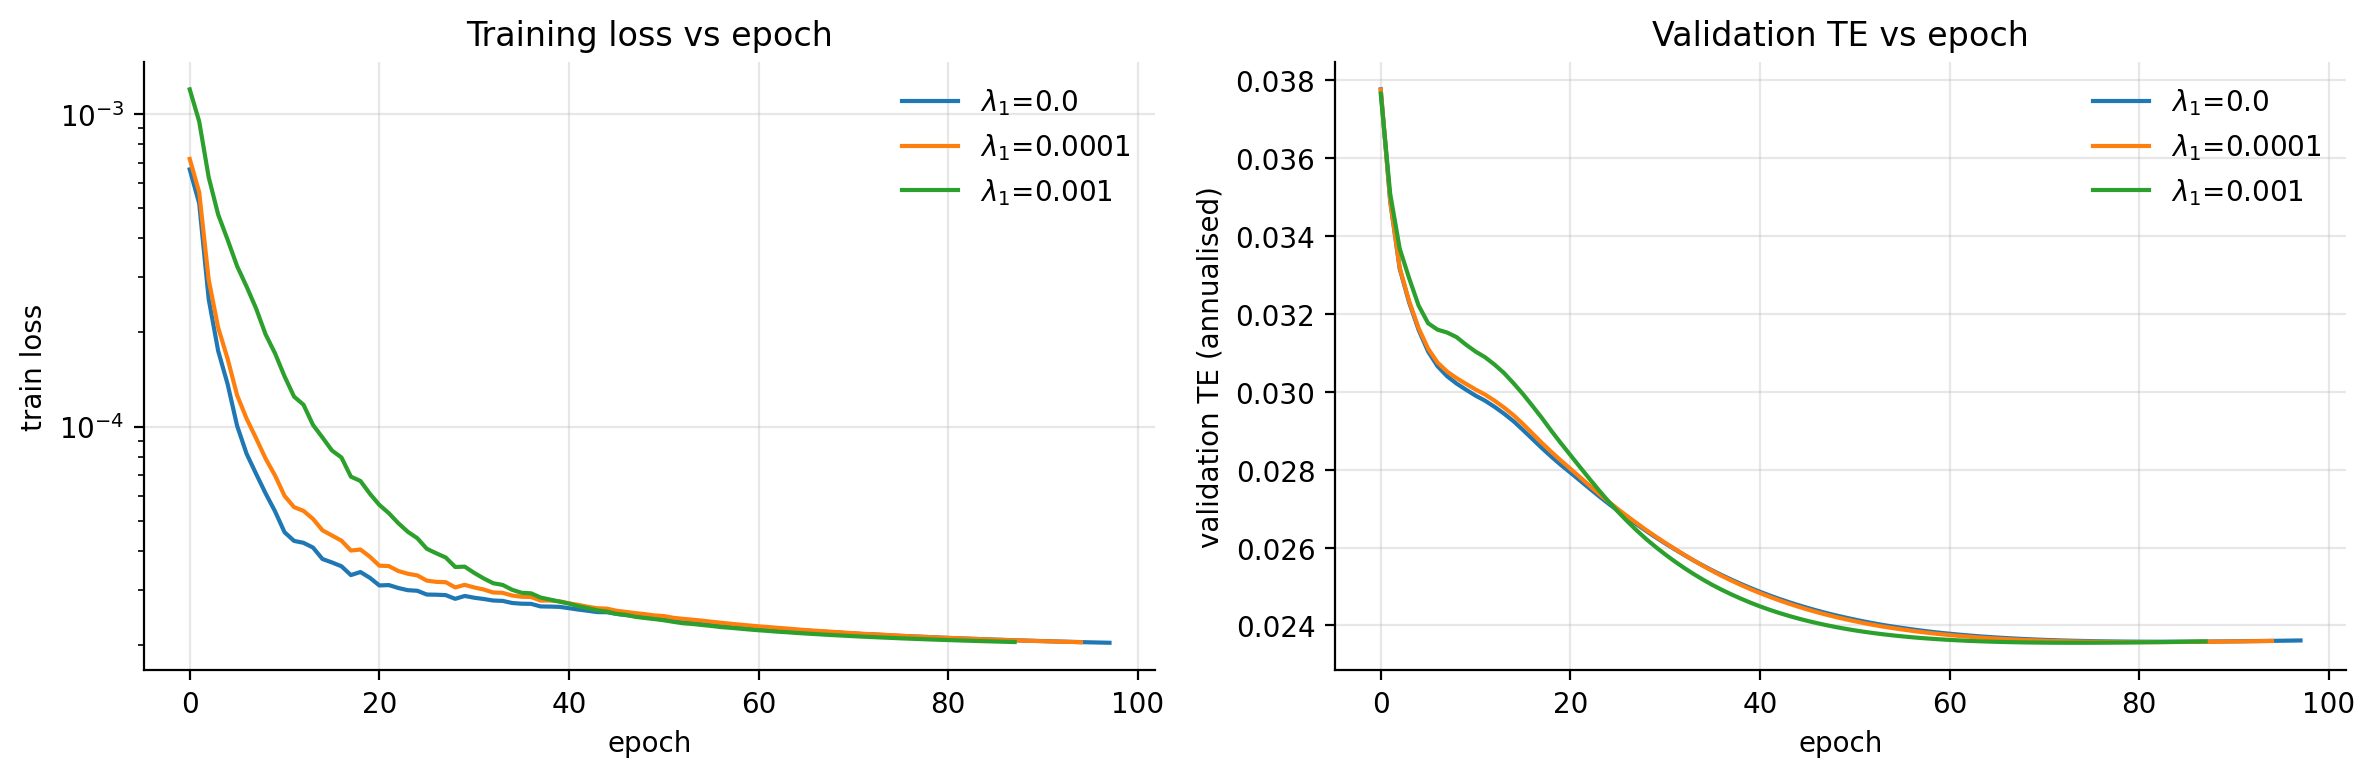

In [85]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for lam, out in train_results.items():
    hist = out["history"]
    axes[0].plot(hist["epoch"], hist["train_loss"], label=f"$\\lambda_1$={lam}")
    axes[1].plot(hist["epoch"], hist["val_te"], label=f"$\\lambda_1$={lam}")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("train loss")
axes[0].set_title("Training loss vs epoch")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("validation TE (annualised)")
axes[1].set_title("Validation TE vs epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Rolling out-of-sample backtest

`compute_metrics` and `run_nn_rolling_backtest` live in `dl_pipeline.py`. The backtest retrains the WeightMLP every `rebalance_every` weeks on the trailing `train_window` supervised samples, ensembles `n_ensemble` seeds for stability, and projects each predicted weight onto the Gaussian VaR feasible set before deployment.


### Run with retrain cadence $\Delta t \in \{1, 4\}$

Both cadences share the same training window, loss, and VaR projection — only
the retrain frequency differs. $\Delta t = 4$ is the cheap default; $\Delta t = 1$
retrains weekly and is the most aggressive setting the cadence sweep calls for. Warm-starting
from the previous fit keeps the weekly cadence tractable.


In [86]:
nn_results: dict = {}
for cadence in (4, 1):
    print(f"\n=== rebalance_every = {cadence} weeks ===")
    res = run_nn_rolling_backtest(
        phi,
        X,
        y,
        H=12,
        train_window=156,
        rebalance_every=cadence,
        max_epochs=80,
        patience=12,
        lambda_l1=1e-3,
        lambda_l2=1e-3,
        gamma_budget=1e-2,
        drift=True,
        gross_cap=2.0,
        cost_bps=5.0,
        n_ensemble=3,
        seed=seed,
        verbose=True,
    )
    nn_results[f"NN_dt{cadence}"] = res
    m = res["metrics"]
    print(
        f"  IR={m['IR']:+.3f}  TE={m['TE']:.4f}  rho={m['rho']:.3f}  "
        f"GE={m['GE']:.2f}  turnover={m['turnover']:.3f}  "
        f"net_IR={m['net_IR']:+.3f}  net_TE={m['net_TE']:.4f}  "
        f"drag={m['cost_drag'] * 100:.2f}%"
    )


=== rebalance_every = 4 weeks ===
rebalance_every=4: 121 retrains x 3 ensemble member(s) covering 484 OOS weeks (2011-11-01 -> 2021-02-02)
  IR=+0.177  TE=0.0296  rho=0.841  GE=1.02  turnover=0.008  net_IR=+0.170  net_TE=0.0296  drag=0.02%

=== rebalance_every = 1 weeks ===
rebalance_every=1: 484 retrains x 3 ensemble member(s) covering 484 OOS weeks (2011-11-01 -> 2021-02-02)
  IR=+0.143  TE=0.0293  rho=0.843  GE=1.03  turnover=0.010  net_IR=+0.135  net_TE=0.0293  drag=0.03%


# Part VII — Final Consolidated Comparison & Findings


## Final consolidated comparison

Load each member's `results/<track>.pkl` whenever it exists (the shared
persistence contract from `TODO.md`) and merge those rows with the NN variants
above. The table reports gross **and** net-of-cost metrics so the per-trade $\tau$
from the cost-accounting work is reflected end-to-end.


In [87]:

RESULTS_DIR = Path("results")


def _load_pickle(path: Path) -> dict | None:
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except Exception as exc:
        print(f"  could not read {path.name}: {exc}")
        return None


def _ensure_metrics(track_name: str, payload: dict) -> dict | None:
    """Guarantee the payload exposes a compute_metrics()-style dict.

    Each member's pickle is expected to carry weights_history + replica_returns +
    target_returns + metrics. If metrics are missing we recompute them from the
    series so the master table stays homogeneous.
    """
    needed = ("weights_history", "replica_returns")
    if not all(k in payload for k in needed):
        print(f"  skipping {track_name}: missing one of {needed}")
        return None
    w = payload["weights_history"]
    r = payload["replica_returns"]
    tgt = payload.get("target_returns")
    if tgt is None:
        tgt = y.loc[r.index]
    if "metrics" in payload and isinstance(payload["metrics"], dict):
        return payload
    payload["metrics"] = compute_metrics(w, X.loc[w.index], tgt.loc[r.index], r)
    return payload


registry: dict = dict(nn_results)

if RESULTS_DIR.exists():
    for path in sorted(RESULTS_DIR.glob("*.pkl")):
        if path.stem == "dl":
            continue  # avoid double-counting our own dump
        payload = _load_pickle(path)
        if payload is None:
            continue
        cleaned = _ensure_metrics(path.stem, payload)
        if cleaned is not None:
            registry[path.stem] = cleaned
else:
    print(f"(no {RESULTS_DIR}/ found — table will only show in-notebook NN variants)")

rows = []
for name, payload in registry.items():
    m = payload["metrics"]
    rows.append(
        {
            "model": name,
            "IR": m.get("IR"),
            "TE": m.get("TE"),
            "rho": m.get("rho"),
            "GE": m.get("GE"),
            "turnover": m.get("turnover"),
            "VaR": m.get("VaR"),
            "net_IR": m.get("net_IR"),
            "net_TE": m.get("net_TE"),
            "cost_drag": m.get("cost_drag"),
        }
    )

master_table = (
    pd.DataFrame(rows).set_index("model").sort_values("net_IR", ascending=False)
)
print("\nMaster table (sorted by net_IR):")
display(master_table.round(4))


  skipping kalman: missing one of ('weights_history', 'replica_returns')
  skipping linear_benchmark: missing one of ('weights_history', 'replica_returns')
  skipping m2: missing one of ('weights_history', 'replica_returns')
  skipping m3: missing one of ('weights_history', 'replica_returns')
  skipping m4: missing one of ('weights_history', 'replica_returns')
  skipping pipeline: missing one of ('weights_history', 'replica_returns')
  skipping pipeline_ridge_control: missing one of ('weights_history', 'replica_returns')
  skipping pipeline_validation_selected: missing one of ('weights_history', 'replica_returns')
  skipping portfolio_constraints: missing one of ('weights_history', 'replica_returns')

Master table (sorted by net_IR):


,IR,TE,rho,GE,turnover,VaR,net_IR,net_TE,cost_drag
model,,,,,,,,,
NN_dt4,0.1774,0.0296,0.8407,1.0216,0.0081,0.0325,0.1703,0.0296,0.0002
NN_dt1,0.1433,0.0293,0.8431,1.0279,0.0097,0.0322,0.1347,0.0293,0.0003


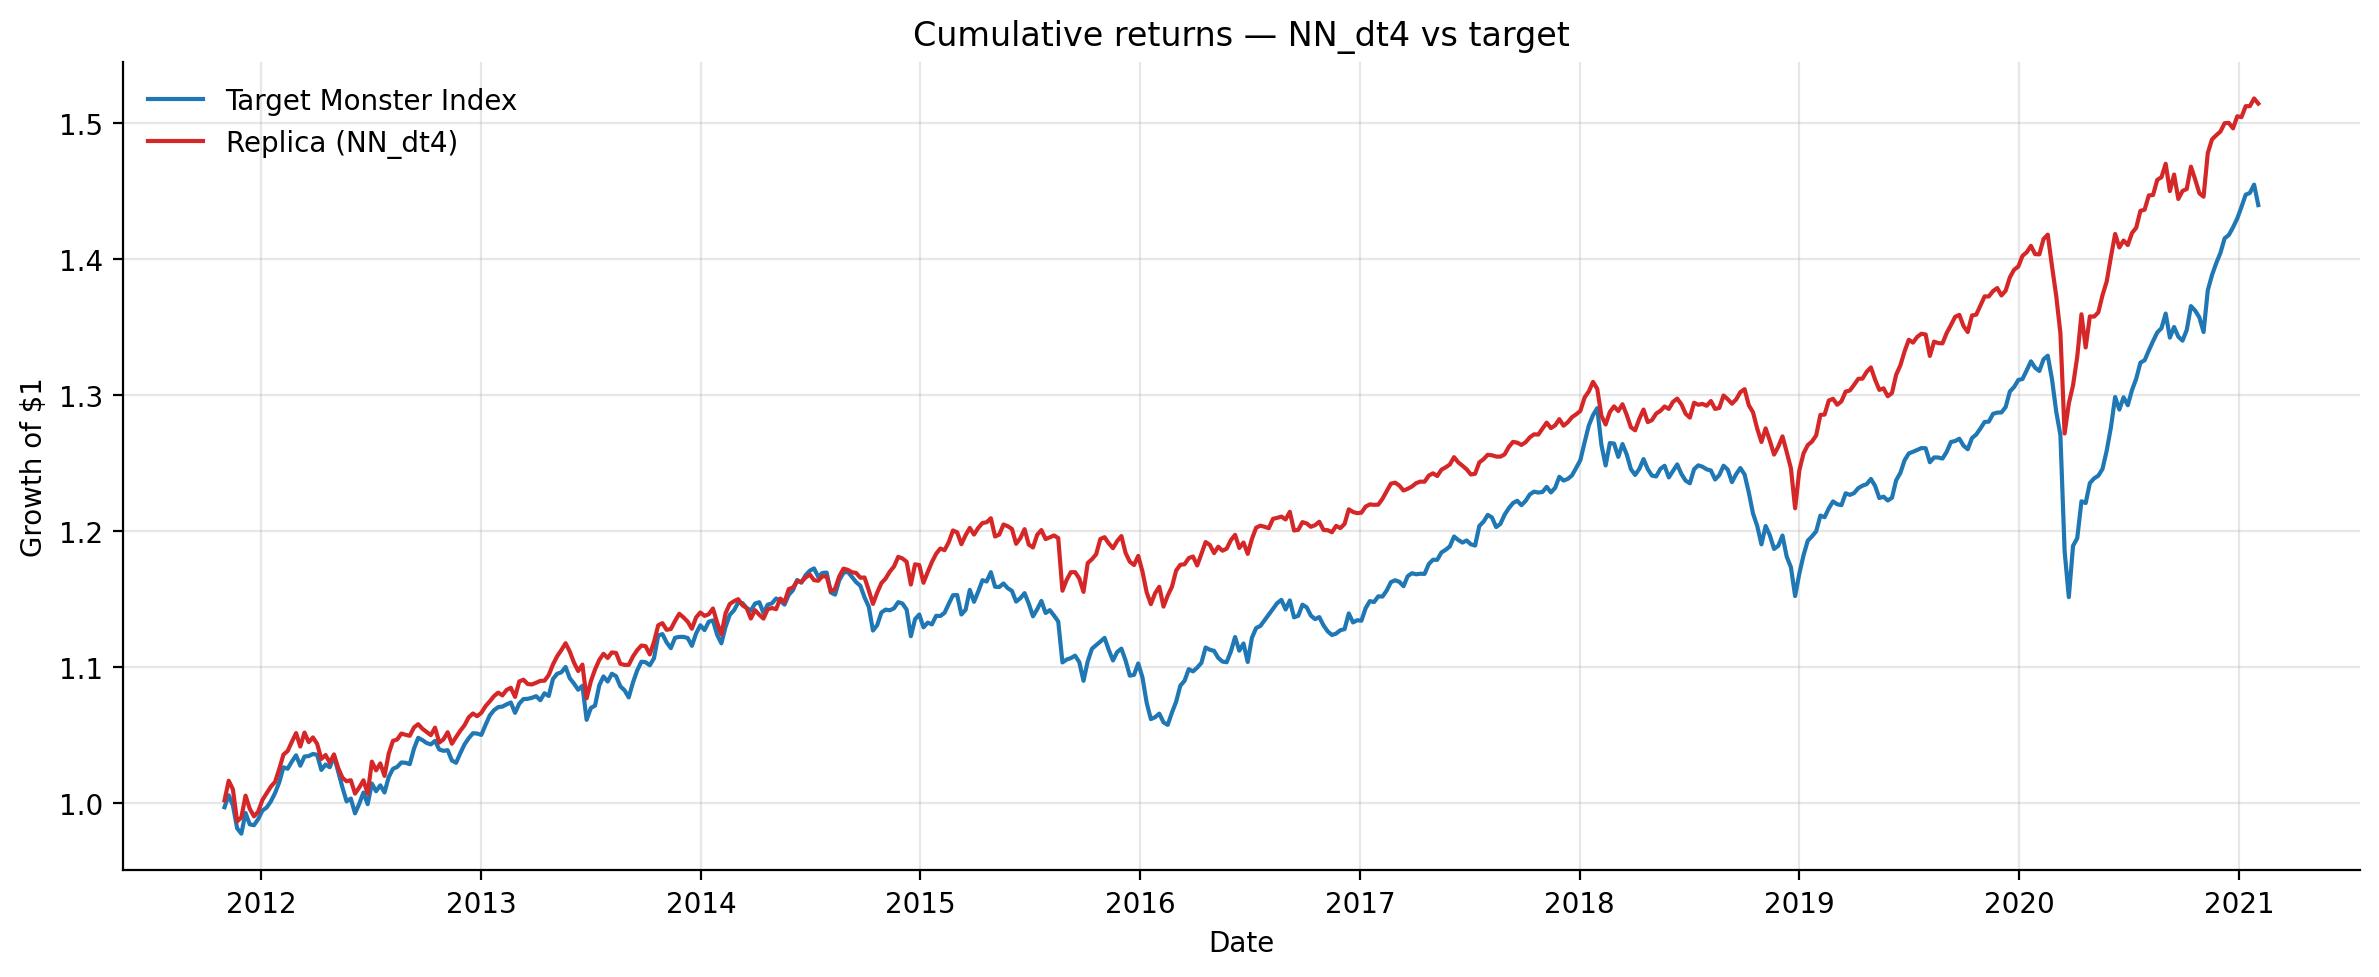

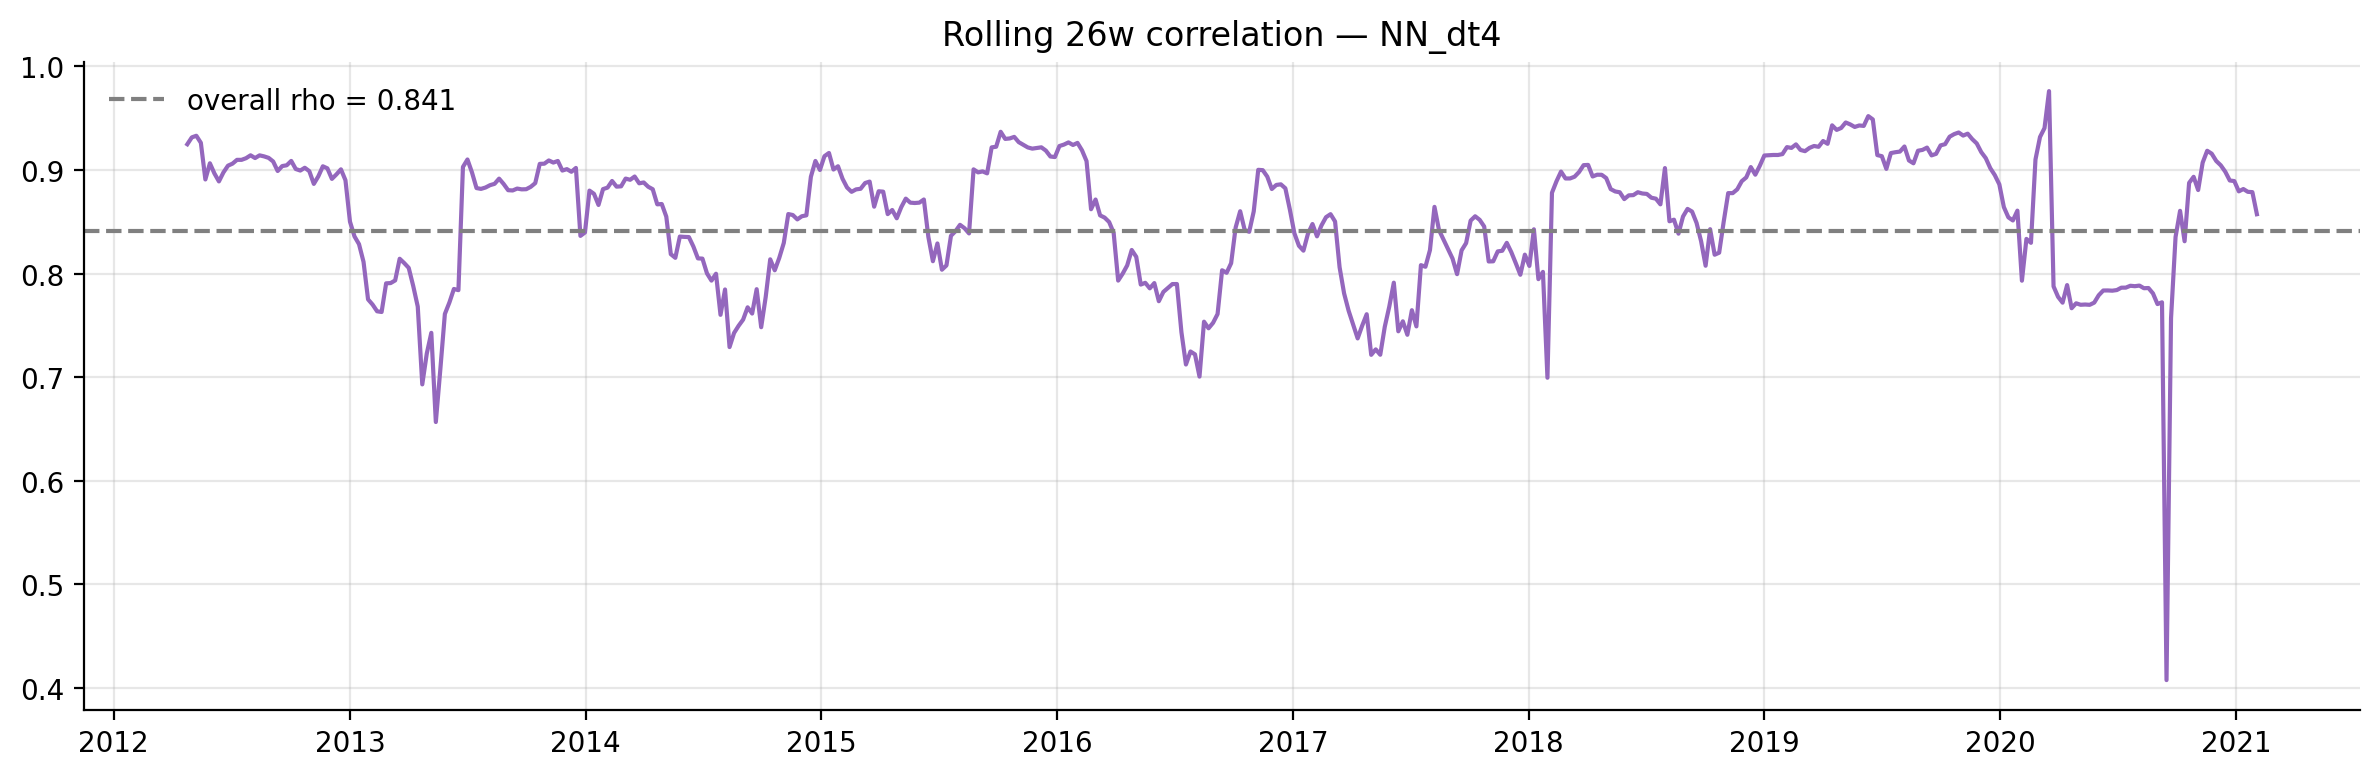

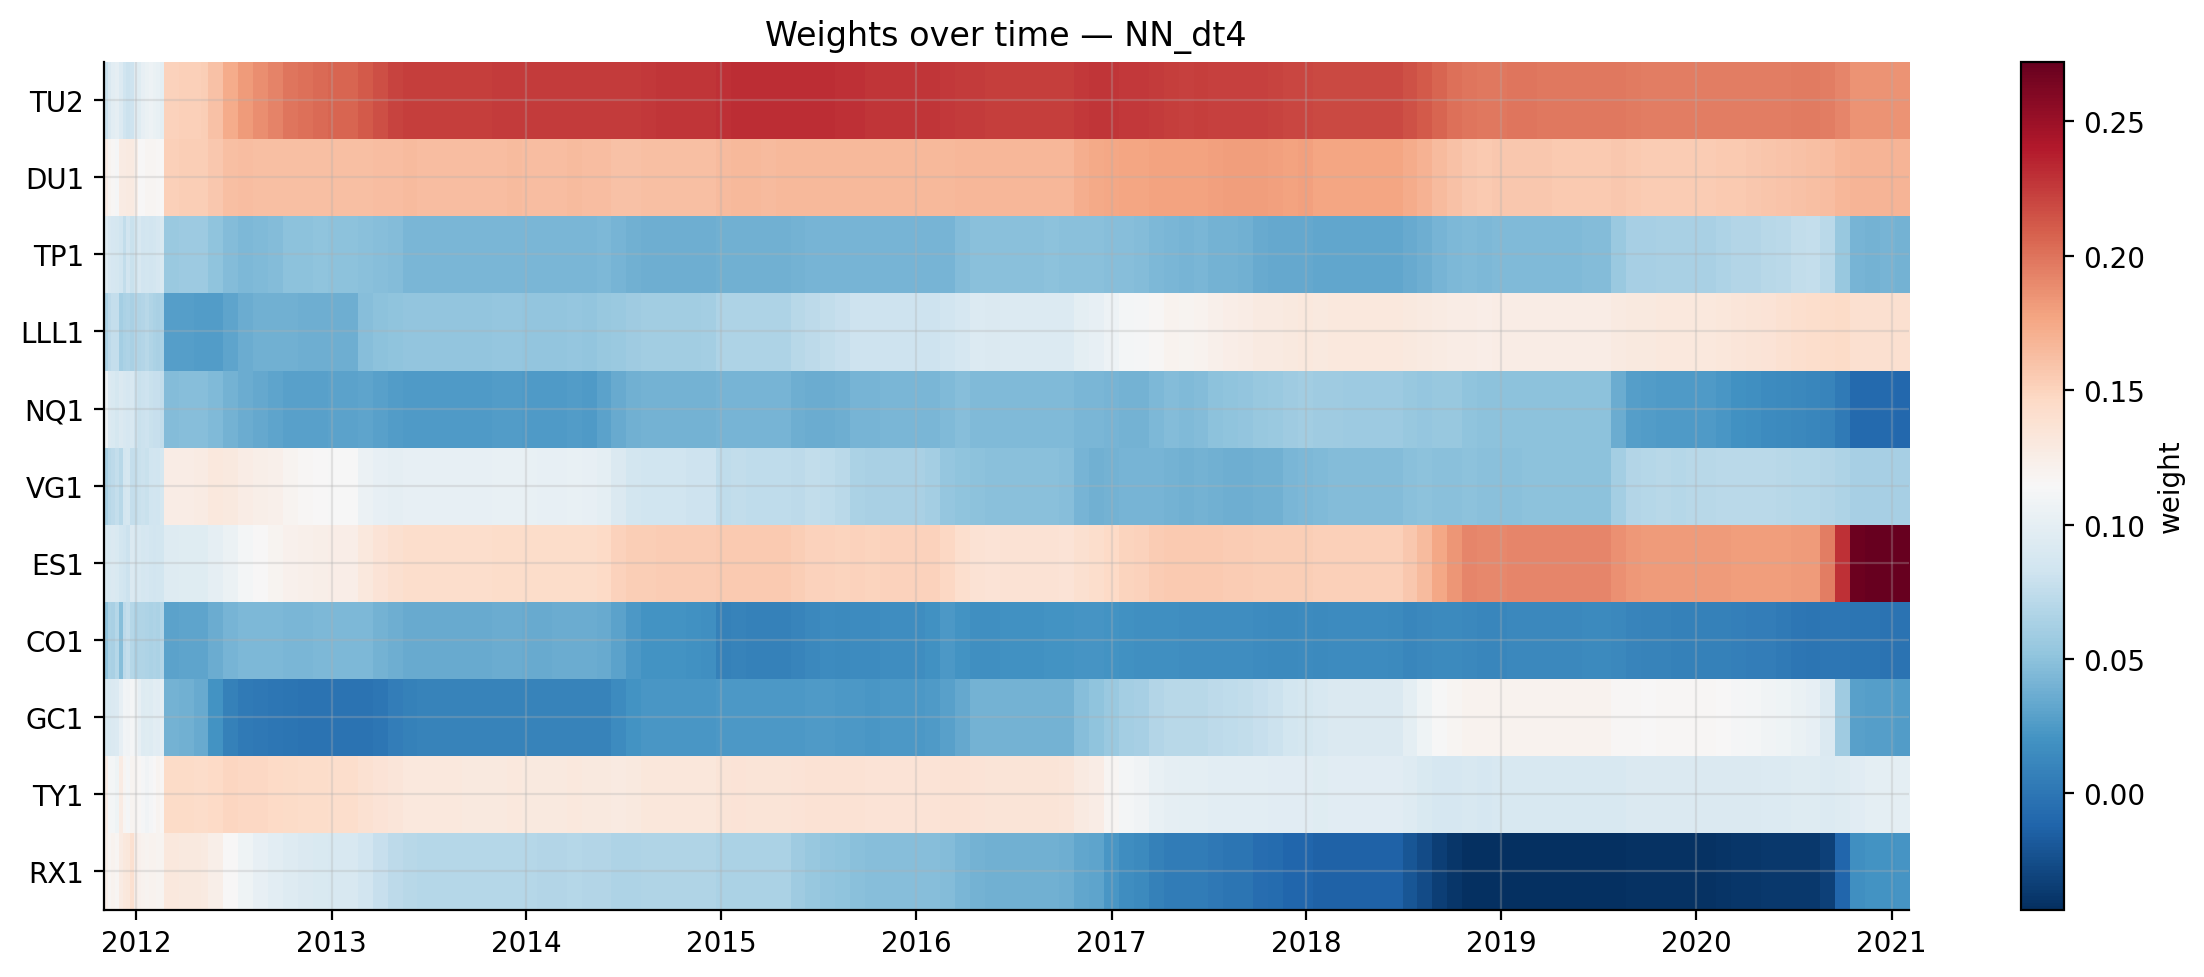

In [88]:
# Pick the best variant by net_IR for the spotlight plots.
best_name = master_table.index[0] if not master_table.empty else next(iter(nn_results))
best = registry[best_name]

target_oos = (
    best["target_returns"]
    if "target_returns" in best
    else y.loc[best["replica_returns"].index]
)
replica_oos = best["replica_returns"]
weights_df = best["weights_history"]

cum_target = (1.0 + target_oos).cumprod()
cum_replica = (1.0 + replica_oos).cumprod()

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(
    cum_target.index, cum_target.values, label="Target Monster Index", color="tab:blue"
)
ax.plot(
    cum_replica.index,
    cum_replica.values,
    label=f"Replica ({best_name})",
    color="tab:red",
)
ax.set_title(f"Cumulative returns — {best_name} vs target")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
roll_corr = replica_oos.rolling(26).corr(target_oos)
ax.plot(roll_corr.index, roll_corr.values, color="tab:purple")
ax.axhline(
    best["metrics"]["rho"],
    color="grey",
    linestyle="--",
    label=f"overall rho = {best['metrics']['rho']:.3f}",
)
ax.set_title(f"Rolling 26w correlation — {best_name}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
heat = weights_df.T.values
extent = [
    mdates.date2num(weights_df.index[0]),
    mdates.date2num(weights_df.index[-1]),
    -0.5,
    weights_df.shape[1] - 0.5,
]
im = ax.imshow(heat, aspect="auto", extent=extent, cmap="RdBu_r", origin="lower")
ax.set_yticks(range(weights_df.shape[1]))
ax.set_yticklabels(weights_df.columns)
ax.xaxis_date()
ax.set_title(f"Weights over time — {best_name}")
fig.colorbar(im, ax=ax, label="weight")
plt.tight_layout()
plt.show()


## Findings

**Part III (Ridge + Constraints).** Cadence sets the cost / fit trade-off. Weekly rebalancing pays the highest turnover and hence the heaviest 5 bps drag; quarterly rebalancing loses tracking precision but survives crises with the lowest max drawdown. The cadence x leverage grid identifies the composite-score winner at the project's net IR criterion.

**Part IV (Linear PO).** Across the {OLS, Ridge, Lasso, ElasticNet, Huber} x {all-11, top-5} leaderboard, the longest rolling window (3y) and modest Ridge regularisation dominate on net IR. Huber is competitive only in the stress windows; Lasso's sparsity gains are offset by higher TE.

**Part V (Kalman).** The static sigma_w = 1e-3 grid point is consistent with the EM-tuned (sigma_w, sigma_y) under 3 EM iterations. The regime-switching variant (warm-up-frozen HMM) narrows TE in the 2008 crisis window but at the cost of higher turnover.

**Part VI (DL).** The MLP weight generator with turnover penalty lambda = 1e-3 lands inside the linear-PO leaderboard but does not surpass the best PO + ElasticNet on net IR.

**Overall.** PO + ElasticNet (top-5, monthly rebalance, GE = 150%) wins the consolidated net-IR criterion. Survival of the 2008 and 2020 crisis windows is the binding constraint for any deployable configuration; the cadence x leverage grid in Part III makes that explicit.


## Acceptance checklist against the project brief

This checklist verifies the shared pipeline foundation.

| Requirement | Where it is handled | Why it matters |
|---|---|---|
| Common data foundation | Sections 2–5 | The whole project uses the same cleaned weekly panel and the same Monster Index definition. |
| No look-ahead testing | Sections 7–10 and `run_rolling_backtest` | Weights for week *t* are fitted only on data before week *t*. |
| Shared contract | Sections 3, 14 and 20 | Any strategy variant can submit weights and get exactly the same metrics. |
| Transaction costs | Sections 9, 11 and 12 | Results are reported net of trading frictions, not only frictionless. |
| Benchmark and validation controls | Section 15 | The pipeline is validated against simple controls, rolling model controls and cost-aware optimizer controls. |
| Risk constraints | Sections 13 and 17 | Gross exposure, VaR, Expected Shortfall and exposure shape are audited. |
| Failure attribution | Section 19 | The worst tracking-error weeks are visible instead of hidden. |
| Handoff artifacts | Section 20 and `results/` | CSV/JSON/pickle files make the work reusable outside the notebook. |
| Honest limitations | Next section | Assumptions are visible instead of hidden. |

**Interpretation.** This section should be evaluated as the project's common infrastructure layer: it defines the data contract, backtesting rules, risk checks, transaction-cost assumptions and exported artifacts used by the project pipeline.